# 06 — Artist Performance Forecasting

## Public Music Intelligence Platform (PMIP)

This notebook develops and evaluates the **Artist Performance Forecasting** component of the Public Music Intelligence Platform (PMIP).

The purpose of this stage is to investigate whether the engineered music-performance features created during the previous stages can be used to predict an appropriate measure of artist performance.

The notebook will define the forecasting target, prepare the model-specific dataset, prevent data leakage, train multiple candidate machine-learning models, evaluate their predictive performance, interpret the most important features, and select the most suitable model for the PMIP platform.

The modelling process will use the machine-learning-ready dataset produced in `05_feature_engineering.ipynb`.




## Objectives

The objectives of this notebook are to:

1. Load and validate the PMIP machine-learning-ready feature dataset.
2. Define a clear and measurable target for artist performance forecasting.
3. Select relevant predictor features for the forecasting task.
4. Identify and remove features that could cause target leakage.
5. Prepare missing, categorical and numerical data for modelling.
6. Split the dataset appropriately into training and testing data.
7. Establish a simple baseline model for comparison.
8. Train and compare suitable machine-learning regression models.
9. Evaluate forecasting performance using appropriate regression metrics.
10. Analyse model errors and generalisation performance.
11. Investigate the features that contribute most strongly to predictions.
12. Select the most suitable forecasting model for PMIP.
13. Save the selected model and supporting preprocessing components for later integration with the PMIP application.
14. Document the model's limitations and recommendations for future improvement.


## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
   - [1.1 Import Libraries](#11-import-libraries)
   - [1.2 Load Machine-Learning-Ready Dataset](#12-load-machine-learning-ready-dataset)
   - [1.3 Initial Dataset Validation](#13-initial-dataset-validation)

2. [Forecasting Problem Definition](#2-forecasting-problem-definition)
   - [2.1 Define Artist Performance](#21-define-artist-performance)
   - [2.2 Identify Candidate Prediction Targets](#22-identify-candidate-prediction-targets)
   - [2.3 Select Final Forecasting Target](#23-select-final-forecasting-target)
   - [2.4 Target Distribution Analysis](#24-target-distribution-analysis)

3. [Model-Specific Feature Selection](#3-model-specific-feature-selection)
   - [3.1 Load Candidate Forecasting Features](#31-load-candidate-forecasting-features)
   - [3.2 Identifier and Metadata Exclusion](#32-identifier-and-metadata-exclusion)
   - [3.3 Target Leakage Review](#33-target-leakage-review)
   - [3.4 Final Predictor Feature Set](#34-final-predictor-feature-set)

4. [Model Data Preparation](#4-model-data-preparation)
   - [4.1 Predictor and Target Separation](#41-predictor-and-target-separation)
   - [4.2 Missing Value Strategy](#42-missing-value-strategy)
   - [4.3 Categorical Feature Encoding](#43-categorical-feature-encoding)
   - [4.4 Numerical Feature Scaling](#44-numerical-feature-scaling)
   - [4.5 Final Modelling Dataset Validation](#45-final-modelling-dataset-validation)

5. [Training and Testing Strategy](#5-training-and-testing-strategy)
   - [5.1 Train-Test Split](#51-train-test-split)
   - [5.2 Training Data Validation](#52-training-data-validation)
   - [5.3 Evaluation Metrics](#53-evaluation-metrics)

6. [Baseline Model](#6-baseline-model)
   - [6.1 Baseline Definition](#61-baseline-definition)
   - [6.2 Baseline Training](#62-baseline-training)
   - [6.3 Baseline Evaluation](#63-baseline-evaluation)

7. [Candidate Model Development](#7-candidate-model-development)
   - [7.1 Linear Regression](#71-linear-regression)
   - [7.2 Ridge Regression](#72-ridge-regression)
   - [7.3 Random Forest Regressor](#73-random-forest-regressor)
   - [7.4 Gradient Boosting Regressor](#74-gradient-boosting-regressor)

8. [Model Evaluation and Comparison](#8-model-evaluation-and-comparison)
   - [8.1 Model Performance Metrics](#81-model-performance-metrics)
   - [8.2 Model Comparison](#82-model-comparison)
   - [8.3 Generalisation Analysis](#83-generalisation-analysis)
   - [8.4 Best Model Selection](#84-best-model-selection)

9. [Model Error Analysis](#9-model-error-analysis)
   - [9.1 Prediction Error Distribution](#91-prediction-error-distribution)
   - [9.2 Actual vs Predicted Performance](#92-actual-vs-predicted-performance)
   - [9.3 High-Error Prediction Analysis](#93-high-error-prediction-analysis)

10. [Model Interpretation](#10-model-interpretation)
    - [10.1 Feature Importance](#101-feature-importance)
    - [10.2 Most Influential Performance Indicators](#102-most-influential-performance-indicators)
    - [10.3 PMIP Interpretation of Model Results](#103-pmip-interpretation-of-model-results)

11. [Final Model Validation](#11-final-model-validation)
    - [11.1 Selected Model Performance](#111-selected-model-performance)
    - [11.2 Baseline Improvement](#112-baseline-improvement)
    - [11.3 Prediction Sanity Checks](#113-prediction-sanity-checks)
    - [11.4 Final Validation](#114-final-validation)

12. [Save Forecasting Model](#12-save-forecasting-model)
    - [12.1 Save Selected Model](#121-save-selected-model)
    - [12.2 Save Preprocessing Components](#122-save-preprocessing-components)
    - [12.3 Reload and Verify](#123-reload-and-verify)

13. [Artist Performance Forecasting Summary](#13-artist-performance-forecasting-summary)
    - [13.1 Key Findings](#131-key-findings)
    - [13.2 Model Limitations](#132-model-limitations)
    - [13.3 Recommendations for PMIP Integration](#133-recommendations-for-pmip-integration)



## 1. Setup and Data Loading

This section prepares the Python environment and loads the machine-learning-ready PMIP dataset created during the feature-engineering stage.

The dataset will be checked before modelling to confirm that the expected records, features and data structures are available for the Artist Performance Forecasting task.

### 1.1 Import Libraries

The required Python libraries are imported for data manipulation, visualisation, preprocessing, machine-learning model development and evaluation.

In [3]:
# ============================================================
# 1.1 Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


#### Interpretation

The required Python libraries were imported successfully, confirming that the PMIP virtual environment is correctly configured for the Artist Performance Forecasting notebook.

The imported libraries provide the main tools required for data manipulation, preprocessing, machine-learning model development and model evaluation. In particular, scikit-learn will be used later in the notebook for dataset splitting, preprocessing pipelines, regression modelling and performance evaluation.

This confirms that the notebook environment is ready for the next stage of the workflow.

Therefore, Section 1.1 has been completed successfully and the machine-learning-ready PMIP dataset can now be loaded and validated.

### 1.2 Load Machine-Learning-Ready Dataset

The machine-learning-ready dataset created during the feature-engineering stage is loaded from the `data/model_ready` directory.

The dataset will be used as the main source of predictors and potential target variables for the Artist Performance Forecasting model.

In [4]:
# ============================================================
# 1.2 Load Machine-Learning-Ready Dataset
# ============================================================

data_path = Path("../data/model_ready/pmip_ml_ready_features.csv")

df = pd.read_csv(data_path)

print("Machine-learning-ready dataset loaded successfully.")
print("=" * 58)

print(f"Dataset path: {data_path}")
print(f"Records loaded: {df.shape[0]:,}")
print(f"Features loaded: {df.shape[1]:,}")

print("\nDataset preview")
print("=" * 58)

display(df.head())

Machine-learning-ready dataset loaded successfully.
Dataset path: ../data/model_ready/pmip_ml_ready_features.csv
Records loaded: 4,593
Features loaded: 93

Dataset preview


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,chart_observations_log,total_historical_streams_log,average_historical_streams_log,historical_streaming_intensity_log,chart_longevity_days_log,chart_longevity_years_log,geographic_performance_intensity_log,Listeners_log,PkListeners_log,has_listener_data
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024-04-26,QM24S2402528,1,725.4,3.904709e+08,30716.0,196631588.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,2024-05-04,USUG12400910,2,545.9,3.237039e+08,28113.0,174597137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.673963,17.805338,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024-03-19,QZJ842400387,3,538.4,6.013093e+08,54331.0,211607669.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,2023-01-12,USSM12209777,4,444.9,2.031281e+09,269802.0,136569078.0,...,6.77308,21.229025,14.45709,14.45709,4.356709,0.191293,16.92496,18.082093,18.248004,1
4,Houdini,Houdini,Eminem,2024-05-31,USUG12403398,5,423.3,1.070349e+08,7223.0,151469874.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.974745,18.043678,1


#### Interpretation

The PMIP machine-learning-ready dataset was loaded successfully from the `data/model_ready` directory.

The dataset contains 4,593 records and 93 features, which matches the dataset structure produced and validated during the feature-engineering stage.

The preview confirms that the dataset contains the original track, artist and platform-performance variables together with the engineered features created for machine-learning development. These include transformed streaming variables and historical performance indicators.

Some historical features contain missing values for tracks without matched historical chart information. This is expected from the earlier data integration and feature-engineering stages and will be handled later using a model-specific missing-value strategy.

Therefore, the correct machine-learning-ready dataset has been loaded successfully and can now undergo initial validation before the forecasting problem is defined.

### 1.3 Initial Dataset Validation

Before beginning the artist performance forecasting analysis, the machine-learning-ready dataset must be validated to confirm that its structure and contents are suitable for model development.

This validation checks the dataset dimensions, duplicate records, missing values, data types and the availability of important feature groups. The purpose is to identify any structural or data-quality issues before defining the forecasting target and selecting model-specific predictors.

In [5]:
# 1.3 Initial Dataset Validation
# ============================================================

print("Initial machine-learning dataset validation")
print("=" * 60)

# Dataset structure
print(f"Total records: {len(df):,}")
print(f"Total features: {df.shape[1]:,}")

# Duplicate validation
duplicate_rows = df.duplicated().sum()

print("\nDuplicate validation")
print("=" * 60)
print(f"Exact duplicate rows: {duplicate_rows:,}")

# Missing-value validation
total_missing = df.isna().sum().sum()
features_with_missing = (df.isna().sum() > 0).sum()
features_without_missing = (df.isna().sum() == 0).sum()

print("\nMissing-value validation")
print("=" * 60)
print(f"Total missing values: {total_missing:,}")
print(f"Features containing missing values: {features_with_missing:,}")
print(f"Features without missing values: {features_without_missing:,}")

# Data type validation
dtype_summary = df.dtypes.value_counts()

print("\nData type summary")
print("=" * 60)
print(dtype_summary)

# Check important feature groups needed for forecasting
important_features = [
    "Spotify Streams",
    "Spotify Popularity",
    "Listeners",
    "PkListeners",
    "Daily Trend",
    "release_year",
    "release_month",
    "release_age_days",
    "release_age_years",
    "historical_streaming_intensity",
    "chart_longevity_days",
    "chart_longevity_years",
    "market_coverage_score",
    "listener_strength_score",
    "listener_peak_ratio",
    "listener_daily_growth_rate",
    "audience_below_peak",
    "audience_trend_direction"
]

feature_check = pd.DataFrame({
    "Feature": important_features,
    "Present": [feature in df.columns for feature in important_features]
})

print("\nForecasting feature availability")
print("=" * 60)
display(feature_check)

missing_important_features = feature_check.loc[
    ~feature_check["Present"], "Feature"
].tolist()

print("\nInitial validation result")
print("=" * 60)

if duplicate_rows == 0 and len(missing_important_features) == 0:
    print("Validation result: PASS")
    print(
        "The dataset structure and key forecasting features are "
        "available for model development."
    )
else:
    print("Validation result: REVIEW REQUIRED")

    if duplicate_rows > 0:
        print(f"- {duplicate_rows:,} duplicate rows require review.")

    if missing_important_features:
        print("- Missing expected forecasting features:")
        for feature in missing_important_features:
            print(f"  - {feature}")

Initial machine-learning dataset validation
Total records: 4,593
Total features: 93

Duplicate validation
Exact duplicate rows: 0

Missing-value validation
Total missing values: 105,653
Features containing missing values: 75
Features without missing values: 18

Data type summary
float64    73
str        10
int64      10
Name: count, dtype: int64

Forecasting feature availability


,Feature,Present
0,Spotify Streams,True
1,Spotify Popularity,True
2,Listeners,True
3,PkListeners,True
4,Daily Trend,True
5,release_year,True
6,release_month,True
7,release_age_days,False
8,release_age_years,False
9,historical_streaming_intensity,True



Initial validation result
Validation result: REVIEW REQUIRED
- Missing expected forecasting features:
  - release_age_days
  - release_age_years


#### Interpretation

The initial validation confirms that the machine-learning-ready PMIP dataset contains 4,593 records and 93 features, with no exact duplicate rows. This indicates that the dataset structure has been preserved successfully from the feature-engineering stage.

A total of 105,653 missing values are present across 75 features. These missing values are expected because the integrated PMIP dataset combines several data sources with different levels of coverage, particularly historical chart, artist listener and platform-specific information. These values will therefore be handled within the model-specific preprocessing stage rather than being automatically replaced at this stage.

The validation also confirmed the availability of the main forecasting-related variables, including Spotify performance metrics, listener information, historical performance indicators, geographic features and audience features.

Two expected variables, `release_age_days` and `release_age_years`, were not present in the final saved dataset. However, the original `Release Date` together with the engineered `release_year` and `release_month` variables remain available. Therefore, release age can be reconstructed later if it is determined to be useful for the forecasting model.

Overall, the dataset is structurally suitable for continuing to the forecasting problem-definition stage. The missing release-age variables do not prevent model development.

## 2. Forecasting Problem Definition

The purpose of this section is to define the prediction problem for the PMIP Artist Performance Forecasting model.

Before training a machine-learning model, it is necessary to establish what is meant by artist performance, identify measurable variables that could represent performance, and select an appropriate prediction target from the available PMIP data.

This ensures that the forecasting model has a clearly defined objective and that subsequent feature selection, preprocessing, training and evaluation are aligned with that objective.

### 2.1 Define Artist Performance

Within the Public Music Intelligence Platform (PMIP), artist performance refers to measurable evidence of how strongly an artist or their music is performing across streaming, audience, playlist, chart and digital-platform activity.

The available dataset represents performance through several dimensions rather than a single measure. These include Spotify streaming activity, Spotify popularity, playlist exposure, artist listener levels, audience trends, historical chart performance, geographic market coverage and engagement across other music platforms.

For the Artist Performance Forecasting model, the prediction target should represent a meaningful quantitative measure of performance that can be estimated from other available indicators.

Therefore, this stage examines the available performance-related variables before a final forecasting target is selected.

In [6]:
# 2.1 Define Artist Performance
# ============================================================

performance_variables = [
    "Spotify Streams",
    "Spotify Popularity",
    "Track Score",
    "All Time Rank",
    "Spotify Playlist Count",
    "Spotify Playlist Reach",
    "YouTube Views",
    "YouTube Likes",
    "TikTok Posts",
    "TikTok Views",
    "TikTok Likes",
    "AirPlay Spins",
    "Shazam Counts",
    "Listeners",
    "PkListeners",
    "Daily Trend",
    "best_chart_position",
    "average_chart_position",
    "chart_observations",
    "countries_charted",
    "total_historical_streams",
    "average_historical_streams"
]

available_performance_variables = [
    feature
    for feature in performance_variables
    if feature in df.columns
]

missing_performance_variables = [
    feature
    for feature in performance_variables
    if feature not in df.columns
]

performance_summary = []

for feature in available_performance_variables:
    available = df[feature].notna().sum()
    missing = df[feature].isna().sum()

    performance_summary.append({
        "Performance Variable": feature,
        "Data Type": str(df[feature].dtype),
        "Available Records": available,
        "Missing Records": missing,
        "Coverage": f"{(available / len(df)) * 100:.2f}%"
    })

performance_summary = pd.DataFrame(performance_summary)

print("PMIP artist performance variable review")
print("=" * 65)

print(f"Candidate performance variables reviewed: {len(performance_variables)}")
print(f"Variables available: {len(available_performance_variables)}")
print(f"Variables unavailable: {len(missing_performance_variables)}")

print("\nAvailable performance variables")
print("=" * 65)
display(performance_summary)

if missing_performance_variables:
    print("\nUnavailable performance variables")
    print("=" * 65)

    for feature in missing_performance_variables:
        print(f"- {feature}")

print("\nPerformance definition result")
print("=" * 65)

if len(available_performance_variables) > 0:
    print("Result: PERFORMANCE VARIABLES IDENTIFIED")
    print(
        "The PMIP dataset contains measurable indicators of artist "
        "performance that can be evaluated as potential forecasting targets."
    )
else:
    print("Result: REVIEW REQUIRED")

PMIP artist performance variable review
Candidate performance variables reviewed: 22
Variables available: 22
Variables unavailable: 0

Available performance variables


,Performance Variable,Data Type,Available Records,Missing Records,Coverage
0,Spotify Streams,float64,4485,108,97.65%
1,Spotify Popularity,float64,3794,799,82.60%
2,Track Score,float64,4593,0,100.00%
3,All Time Rank,int64,4593,0,100.00%
4,Spotify Playlist Count,float64,4528,65,98.58%
5,Spotify Playlist Reach,float64,4526,67,98.54%
6,YouTube Views,float64,4290,303,93.40%
7,YouTube Likes,float64,4283,310,93.25%
8,TikTok Posts,float64,3425,1168,74.57%
9,TikTok Views,float64,3617,976,78.75%



Performance definition result
Result: PERFORMANCE VARIABLES IDENTIFIED
The PMIP dataset contains measurable indicators of artist performance that can be evaluated as potential forecasting targets.


#### Interpretation

The artist performance review identified all 22 candidate performance variables within the PMIP machine-learning-ready dataset, confirming that the dataset contains multiple measurable dimensions of music performance.

The available variables represent several aspects of performance, including Spotify streaming and popularity, playlist exposure, YouTube and TikTok engagement, airplay activity, Shazam activity, artist listener behaviour, historical chart performance and geographic market reach.

Data coverage varies considerably between these variables. `Track Score` and `All Time Rank` provide complete coverage across all 4,593 records, while Spotify Streams, Spotify Playlist Count and Spotify Playlist Reach each provide more than 97% coverage. YouTube-related variables also provide more than 93% coverage.

Artist listener variables provide 73.79% coverage, while historical chart variables provide 48.66% coverage. Therefore, although these variables contain valuable information about artist performance, their lower coverage must be considered when selecting predictors and designing the model preprocessing strategy.

Most importantly, the analysis confirms that artist performance cannot be represented by only one type of activity. The PMIP dataset captures performance across streaming, audience, platform engagement, historical chart activity and geographic reach.

Therefore, the dataset contains sufficient measurable performance information to proceed with evaluating candidate prediction targets for the Artist Performance Forecasting model.

### 2.2 Identify Candidate Prediction Targets

#### Purpose

The purpose of this section is to identify and evaluate suitable prediction targets for the PMIP Artist Performance Forecasting model.

A prediction target is the variable that the machine-learning model will attempt to predict using the available artist, track, audience, historical and platform-performance features.

Candidate targets are evaluated according to:

- their relevance to artist performance;
- their availability and data coverage;
- the amount of variation present in the variable;
- their suitability for a regression forecasting task;
- and whether the variable provides a meaningful output for the Public Music Intelligence Platform.

This analysis does not yet select the final forecasting target. The objective is to compare the strongest candidates before making the final decision in Section 2.3.

In [7]:
# ============================================================
# 2.2 Identify Candidate Prediction Targets
# ============================================================

# Candidate variables that could represent forecastable
# artist/track performance within PMIP
candidate_targets = [
    "Spotify Streams",
    "Spotify Popularity",
    "Track Score",
    "Listeners",
    "Daily Trend",
    "total_historical_streams",
    "average_historical_streams"
]

target_review = []

for target in candidate_targets:
    if target not in df.columns:
        target_review.append({
            "Candidate Target": target,
            "Present": False,
            "Data Type": "N/A",
            "Available Records": 0,
            "Missing Records": len(df),
            "Coverage": "0.00%",
            "Unique Values": 0
        })
        continue

    available = df[target].notna().sum()
    missing = df[target].isna().sum()
    coverage = (available / len(df)) * 100
    unique_values = df[target].nunique(dropna=True)

    target_review.append({
        "Candidate Target": target,
        "Present": True,
        "Data Type": str(df[target].dtype),
        "Available Records": available,
        "Missing Records": missing,
        "Coverage": f"{coverage:.2f}%",
        "Unique Values": unique_values
    })

target_review_df = pd.DataFrame(target_review)

print("PMIP candidate forecasting target review")
print("=" * 60)
print(f"Candidate targets reviewed: {len(candidate_targets)}")
print(
    f"Candidate targets available: "
    f"{target_review_df['Present'].sum()}"
)

print("\nCandidate target comparison")
print("=" * 60)

display(target_review_df)

# ------------------------------------------------------------
# Numerical distribution review
# ------------------------------------------------------------

available_targets = [
    target
    for target in candidate_targets
    if target in df.columns
]

print("\nCandidate target distribution summary")
print("=" * 60)

display(
    df[available_targets]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
)

# ------------------------------------------------------------
# Initial target suitability review
# ------------------------------------------------------------

print("\nInitial forecasting suitability")
print("=" * 60)

for target in available_targets:
    coverage = df[target].notna().mean() * 100
    unique_values = df[target].nunique(dropna=True)

    if coverage >= 90 and unique_values > 100:
        suitability = "STRONG CANDIDATE"
    elif coverage >= 70 and unique_values > 50:
        suitability = "POSSIBLE CANDIDATE"
    else:
        suitability = "LIMITED CANDIDATE"

    print(
        f"{target:<30} "
        f"Coverage: {coverage:>6.2f}% | "
        f"Unique: {unique_values:>5} | "
        f"{suitability}"
    )

PMIP candidate forecasting target review
Candidate targets reviewed: 7
Candidate targets available: 7

Candidate target comparison


,Candidate Target,Present,Data Type,Available Records,Missing Records,Coverage,Unique Values
0,Spotify Streams,True,float64,4485,108,97.65%,4425
1,Spotify Popularity,True,float64,3794,799,82.60%,94
2,Track Score,True,float64,4593,0,100.00%,861
3,Listeners,True,float64,3389,1204,73.79%,1003
4,Daily Trend,True,float64,3389,1204,73.79%,997
5,total_historical_streams,True,float64,2235,2358,48.66%,2178
6,average_historical_streams,True,float64,2235,2358,48.66%,2178



Candidate target distribution summary


,count,mean,std,min,25%,50%,75%,max
Spotify Streams,4485.0,4.474069e+08,5.385504e+08,1071.0,7.035455e+07,2.398507e+08,6.291025e+08,4.281469e+09
Spotify Popularity,3794.0,6.349868e+01,1.618995e+01,1.0,6.100000e+01,6.700000e+01,7.300000e+01,9.600000e+01
Track Score,4593.0,4.184024e+01,3.856277e+01,19.4,2.330000e+01,2.990000e+01,4.440000e+01,7.254000e+02
Listeners,3389.0,3.116825e+07,2.431217e+07,4281434.0,1.117841e+07,2.397606e+07,4.655930e+07,1.075923e+08
Daily Trend,3389.0,3.045847e+03,1.270652e+05,-368853.0,-4.275800e+04,-4.254000e+03,2.928300e+04,7.430720e+05
total_historical_streams,2235.0,4.199844e+08,6.453579e+08,1904.0,3.288710e+07,1.717060e+08,5.342248e+08,6.226856e+09
average_historical_streams,2235.0,5.852889e+05,5.789206e+05,1560.0,2.375242e+05,4.408687e+05,7.180152e+05,6.320842e+06



Initial forecasting suitability
Spotify Streams                Coverage:  97.65% | Unique:  4425 | STRONG CANDIDATE
Spotify Popularity             Coverage:  82.60% | Unique:    94 | POSSIBLE CANDIDATE
Track Score                    Coverage: 100.00% | Unique:   861 | STRONG CANDIDATE
Listeners                      Coverage:  73.79% | Unique:  1003 | POSSIBLE CANDIDATE
Daily Trend                    Coverage:  73.79% | Unique:   997 | POSSIBLE CANDIDATE
total_historical_streams       Coverage:  48.66% | Unique:  2178 | LIMITED CANDIDATE
average_historical_streams     Coverage:  48.66% | Unique:  2178 | LIMITED CANDIDATE


#### Interpretation

The candidate-target analysis identified seven variables that could potentially represent artist or track performance within PMIP.

Spotify Streams emerged as one of the strongest forecasting candidates, with 4,485 available observations (97.65% coverage) and 4,425 unique values. This provides both high dataset coverage and substantial variation for a regression model. More importantly, streaming volume represents a directly interpretable measure of music consumption and commercial performance.

Track Score also showed strong statistical suitability, with complete dataset coverage and 861 unique values. However, Track Score is an existing composite performance measure rather than a direct observed consumption metric, meaning its suitability as the forecasting target requires careful consideration.

Spotify Popularity, Listeners and Daily Trend remain possible targets but have lower data coverage. The historical streaming variables provide valuable predictors of past performance but are available for only 48.66% of records, making them less suitable as the primary forecasting target.

Overall, Spotify Streams and Track Score are the strongest candidates identified at this stage. The final target will be selected in Section 2.3 based on its statistical suitability, interpretability and relevance to the PMIP forecasting objective.

### 2.3 Select Final Forecasting Target

#### Purpose

This section selects the final prediction target for the PMIP Artist Performance Forecasting model.

Based on the candidate-target analysis, Spotify Streams and Track Score were identified as the strongest potential targets. The final selection considers not only dataset coverage, but also interpretability, modelling suitability and relevance to the objectives of the Public Music Intelligence Platform.

The selected target should represent a meaningful measure of music performance that can later be presented clearly to PMIP users.


In [8]:
# ============================================================
# 2.3 Select Final Forecasting Target
# ============================================================

final_target = "Spotify Streams"

# Validate that the selected target exists
target_exists = final_target in df.columns

if not target_exists:
    raise ValueError(
        f"Selected forecasting target '{final_target}' "
        "was not found in the dataset."
    )

# Target statistics
target_available = df[final_target].notna().sum()
target_missing = df[final_target].isna().sum()
target_coverage = (target_available / len(df)) * 100
target_unique = df[final_target].nunique(dropna=True)

print("PMIP final forecasting target selection")
print("=" * 60)

print(f"Selected target: {final_target}")
print(f"Target data type: {df[final_target].dtype}")
print(f"Available records: {target_available:,}")
print(f"Missing records: {target_missing:,}")
print(f"Coverage: {target_coverage:.2f}%")
print(f"Unique target values: {target_unique:,}")

print("\nTarget value summary")
print("=" * 60)

display(
    df[final_target]
    .describe()
    .to_frame(name=final_target)
)

# Compare selected target against Track Score
comparison_targets = ["Spotify Streams", "Track Score"]

comparison = []

for target in comparison_targets:
    available = df[target].notna().sum()

    comparison.append({
        "Target": target,
        "Available Records": available,
        "Missing Records": df[target].isna().sum(),
        "Coverage": f"{(available / len(df)) * 100:.2f}%",
        "Unique Values": df[target].nunique(dropna=True)
    })

comparison_df = pd.DataFrame(comparison)

print("\nFinal candidate comparison")
print("=" * 60)

display(comparison_df)

print("\nSelection result")
print("=" * 60)

print("FINAL TARGET SELECTED")
print(f"PMIP forecasting target: {final_target}")

PMIP final forecasting target selection
Selected target: Spotify Streams
Target data type: float64
Available records: 4,485
Missing records: 108
Coverage: 97.65%
Unique target values: 4,425

Target value summary


,Spotify Streams
count,4.485000e+03
mean,4.474069e+08
std,5.385504e+08
min,1.071000e+03
25%,7.035455e+07
50%,2.398507e+08
75%,6.291025e+08
max,4.281469e+09



Final candidate comparison


,Target,Available Records,Missing Records,Coverage,Unique Values
0,Spotify Streams,4485,108,97.65%,4425
1,Track Score,4593,0,100.00%,861



Selection result
FINAL TARGET SELECTED
PMIP forecasting target: Spotify Streams


#### Interpretation

Spotify Streams was selected as the final prediction target for the PMIP Artist Performance Forecasting model.

Although Track Score provides complete dataset coverage, Spotify Streams represents a more direct and interpretable measure of real-world music consumption. Predicting streaming performance therefore produces an output that can be understood more naturally by artists, managers and other users of the Public Music Intelligence Platform.

Spotify Streams also provides strong statistical coverage, with 4,485 of the 4,593 records containing a value (97.65%). Only 108 records currently lack a target value. These records will be handled during model-specific data preparation because observations without a known target cannot be used for supervised model training.

The forecasting problem is therefore defined as a regression task in which PMIP will use selected performance, audience, release, geographic and historical indicators to estimate Spotify streaming performance.

The distribution and characteristics of the selected target will be examined further in Section 2.4 before predictor selection and model development.

### 2.4 Target Distribution Analysis

#### Purpose

This section examines the statistical distribution of the selected forecasting target, Spotify Streams.

Streaming data can contain substantial differences between lower-performing tracks and extremely successful tracks with billions of streams. A strongly skewed target distribution may affect how regression models learn from the data, particularly when a relatively small number of very large observations dominate the target range.

The analysis therefore examines:

- the distribution of Spotify Streams;
- the degree of skewness;
- the difference between the mean and median;
- potential extreme observations;
- and the effect of applying a logarithmic transformation.

The purpose is to determine whether the raw streaming target or a transformed representation should be considered during model development.

PMIP Spotify Streams target distribution analysis
Valid target records: 4,485
Missing target records: 108

Raw Spotify Streams distribution
Minimum: 1,071
Mean: 447,406,867
Median: 239,850,720
Maximum: 4,281,468,720
Standard deviation: 538,550,401
Skewness: 2.024

Log-transformed Spotify Streams distribution
Mean: 18.823
Median: 19.296
Standard deviation: 2.237
Skewness: -2.174

High-value observation review
25th percentile: 70,354,552
75th percentile: 629,102,459
IQR: 558,747,907
IQR upper bound: 1,467,224,320
Records above upper bound: 289
Percentage above upper bound: 6.44%


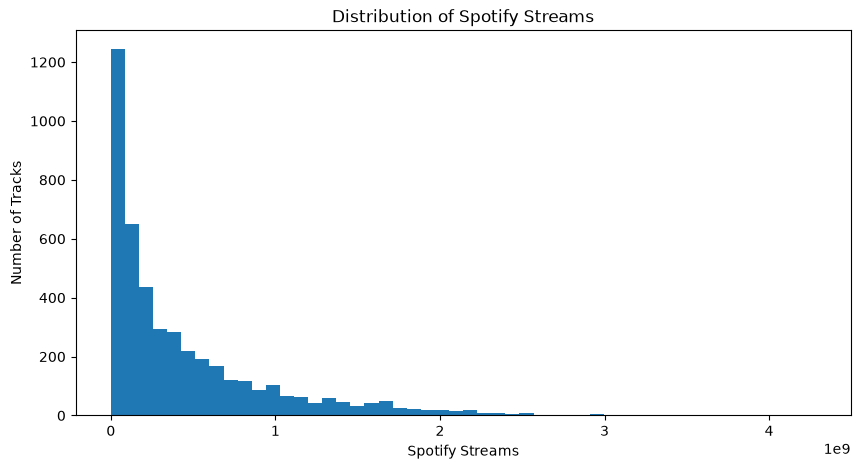

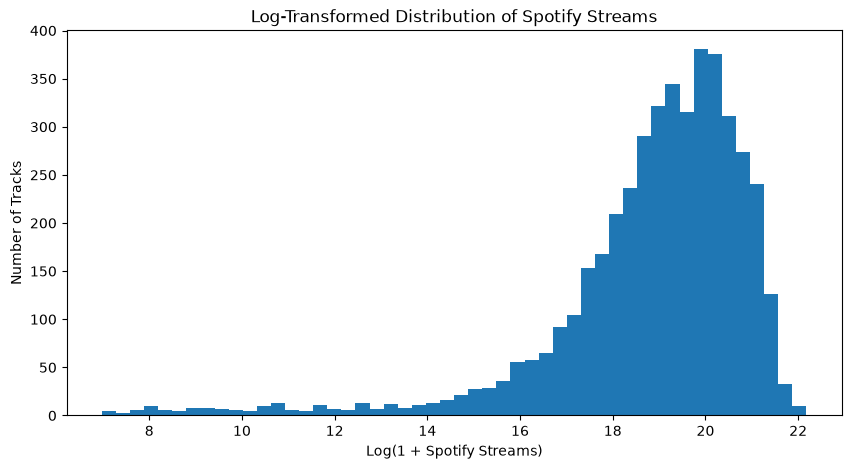


Target distribution assessment
Raw target skewness: 2.024
Log-transformed skewness: -2.174
Result: The logarithmic transformation does not reduce target skewness.


In [9]:
# ============================================================
# 2.4 Target Distribution Analysis
# ============================================================

target = df[final_target].dropna()

# Log transformation
target_log = np.log1p(target)

# ------------------------------------------------------------
# Basic distribution statistics
# ------------------------------------------------------------

raw_skewness = target.skew()
log_skewness = target_log.skew()

mean_streams = target.mean()
median_streams = target.median()

print("PMIP Spotify Streams target distribution analysis")
print("=" * 65)

print(f"Valid target records: {len(target):,}")
print(f"Missing target records: {df[final_target].isna().sum():,}")

print("\nRaw Spotify Streams distribution")
print("=" * 65)

print(f"Minimum: {target.min():,.0f}")
print(f"Mean: {mean_streams:,.0f}")
print(f"Median: {median_streams:,.0f}")
print(f"Maximum: {target.max():,.0f}")
print(f"Standard deviation: {target.std():,.0f}")
print(f"Skewness: {raw_skewness:.3f}")

print("\nLog-transformed Spotify Streams distribution")
print("=" * 65)

print(f"Mean: {target_log.mean():.3f}")
print(f"Median: {target_log.median():.3f}")
print(f"Standard deviation: {target_log.std():.3f}")
print(f"Skewness: {log_skewness:.3f}")

# ------------------------------------------------------------
# IQR extreme-value review
# ------------------------------------------------------------

q1 = target.quantile(0.25)
q3 = target.quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

high_value_records = (target > upper_bound).sum()
high_value_percentage = (high_value_records / len(target)) * 100

print("\nHigh-value observation review")
print("=" * 65)

print(f"25th percentile: {q1:,.0f}")
print(f"75th percentile: {q3:,.0f}")
print(f"IQR: {iqr:,.0f}")
print(f"IQR upper bound: {upper_bound:,.0f}")
print(f"Records above upper bound: {high_value_records:,}")
print(f"Percentage above upper bound: {high_value_percentage:.2f}%")

# ------------------------------------------------------------
# Visual comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(target, bins=50)
plt.xlabel("Spotify Streams")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Spotify Streams")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(target_log, bins=50)
plt.xlabel("Log(1 + Spotify Streams)")
plt.ylabel("Number of Tracks")
plt.title("Log-Transformed Distribution of Spotify Streams")
plt.show()

# ------------------------------------------------------------
# Distribution assessment
# ------------------------------------------------------------

print("\nTarget distribution assessment")
print("=" * 65)

print(f"Raw target skewness: {raw_skewness:.3f}")
print(f"Log-transformed skewness: {log_skewness:.3f}")

if abs(log_skewness) < abs(raw_skewness):
    print(
        "Result: The logarithmic transformation reduces "
        "the skewness of the forecasting target."
    )
else:
    print(
        "Result: The logarithmic transformation does not "
        "reduce target skewness."
    )

### Interpretation

The Spotify Streams target contains 4,485 valid observations, providing 97.65% coverage of the PMIP dataset. The distribution is strongly right-skewed, with a skewness value of 2.024. This indicates that most tracks have relatively lower streaming totals, while a smaller number of highly successful tracks have accumulated exceptionally large numbers of streams.

The difference between the mean of approximately 447.4 million streams and the median of approximately 239.9 million streams further demonstrates the influence of high-performing tracks on the distribution. Using the IQR method, 289 tracks (6.44% of valid observations) were identified above the upper bound. These observations should not automatically be removed because exceptionally high streaming figures can represent genuine commercially successful tracks rather than incorrect data.

A logarithmic transformation was also examined as a possible method of reducing the target imbalance. However, the transformed distribution produced a skewness of -2.174, meaning that the transformation shifted the distribution from strong right skewness to strong left skewness rather than improving its overall symmetry. Therefore, the raw Spotify Streams target will be retained at this stage, while alternative target transformations or modelling strategies can be evaluated during model development if necessary.

Overall, Spotify Streams remains a suitable forecasting target because of its high data coverage, continuous numerical structure and direct representation of track performance. The observed skewness will be considered when training and evaluating the forecasting models.

## 3. Model-Specific Feature Selection

This section identifies and prepares the predictor variables that may be used to forecast Spotify Streams. The machine-learning-ready PMIP dataset contains features from multiple sources and feature-engineering stages, but not every available column should automatically be used for forecasting.

The selection process therefore begins by identifying candidate forecasting features before removing identifiers, metadata, redundant variables and features that could introduce target leakage.


### 3.1 Load Candidate Forecasting Features

Candidate forecasting features are selected from the available PMIP dataset based on their potential relationship with streaming performance.

The initial candidate set includes platform-performance metrics, release information, historical chart performance, geographic reach and artist audience indicators. At this stage, the purpose is to construct a broad candidate feature set. Further exclusions for identifiers, metadata and target leakage will be performed in the following subsections.

In [10]:
# 3.1 Load Candidate Forecasting Features
# ============================================================

# Final forecasting target selected in Section 2
forecasting_target = "Spotify Streams"

# Candidate features grouped by their source/purpose
candidate_feature_groups = {
    
    "Platform Performance": [
        "Spotify Popularity",
        "Spotify Playlist Count",
        "Spotify Playlist Reach",
        "YouTube Views",
        "YouTube Likes",
        "TikTok Posts",
        "TikTok Views",
        "TikTok Likes",
        "AirPlay Spins",
        "Shazam Counts",
        "Pandora Streams",
        "Pandora Track Stations",
        "Deezer Playlist Count",
        "Deezer Playlist Reach",
        "Amazon Playlist Count",
        "Apple Music Playlist Count",
        "SiriusXM Spins"
    ],
    
    "Release Features": [
        "release_year",
        "release_month"
    ],
    
    "Historical Performance": [
        "best_chart_position",
        "average_chart_position",
        "chart_observations",
        "countries_charted",
        "total_historical_streams",
        "average_historical_streams",
        "historical_streaming_intensity",
        "chart_longevity_days",
        "chart_longevity_years",
        "best_chart_strength",
        "average_chart_strength",
        "chart_activity_factor",
        "peak_chart_performance",
        "average_chart_performance",
        "has_historical_chart_data",
        "reached_top_10",
        "reached_number_one",
        "broad_geographic_reach",
        "sustained_chart_activity"
    ],
    
    "Geographic Performance": [
        "market_coverage_score",
        "geographic_performance_intensity"
    ],
    
    "Artist Audience": [
        "Listeners",
        "PkListeners",
        "Daily Trend",
        "listener_strength_score",
        "listener_peak_ratio",
        "listener_daily_growth_rate",
        "audience_below_peak",
        "audience_trend_direction"
    ]
}

# Flatten feature groups into one candidate feature list
candidate_forecasting_features = [
    feature
    for features in candidate_feature_groups.values()
    for feature in features
]

# Check which candidate features are actually available
available_candidate_features = [
    feature
    for feature in candidate_forecasting_features
    if feature in df.columns
]

missing_candidate_features = [
    feature
    for feature in candidate_forecasting_features
    if feature not in df.columns
]

print("PMIP candidate forecasting feature set")
print("=" * 62)

print(f"Forecasting target: {forecasting_target}")
print(f"Candidate features requested: {len(candidate_forecasting_features)}")
print(f"Candidate features available: {len(available_candidate_features)}")
print(f"Candidate features unavailable: {len(missing_candidate_features)}")

# Summarise each feature group
group_summary = []

for group_name, features in candidate_feature_groups.items():
    
    available = [feature for feature in features if feature in df.columns]
    missing = [feature for feature in features if feature not in df.columns]
    
    group_summary.append({
        "Feature Group": group_name,
        "Requested Features": len(features),
        "Available Features": len(available),
        "Missing Features": len(missing)
    })

group_summary_df = pd.DataFrame(group_summary)

print("\nCandidate feature groups")
print("=" * 62)

display(group_summary_df)

# Detailed candidate feature information
feature_summary = []

for feature in available_candidate_features:
    
    available_records = df[feature].notna().sum()
    missing_records = df[feature].isna().sum()
    coverage = (available_records / len(df)) * 100
    
    feature_summary.append({
        "Feature": feature,
        "Data Type": str(df[feature].dtype),
        "Available Records": available_records,
        "Missing Records": missing_records,
        "Coverage": f"{coverage:.2f}%"
    })

candidate_feature_summary_df = pd.DataFrame(feature_summary)

print("\nAvailable candidate forecasting features")
print("=" * 62)

display(candidate_feature_summary_df)

# Missing feature report
print("\nCandidate feature availability result")
print("=" * 62)

if len(missing_candidate_features) == 0:
    print("Result: ALL CANDIDATE FEATURES AVAILABLE")
else:
    print("Result: REVIEW REQUIRED")
    print("Unavailable candidate features:")
    
    for feature in missing_candidate_features:
        print(f"- {feature}")

PMIP candidate forecasting feature set
Forecasting target: Spotify Streams
Candidate features requested: 48
Candidate features available: 48
Candidate features unavailable: 0

Candidate feature groups


,Feature Group,Requested Features,Available Features,Missing Features
0,Platform Performance,17,17,0
1,Release Features,2,2,0
2,Historical Performance,19,19,0
3,Geographic Performance,2,2,0
4,Artist Audience,8,8,0



Available candidate forecasting features


,Feature,Data Type,Available Records,Missing Records,Coverage
0,Spotify Popularity,float64,3794,799,82.60%
1,Spotify Playlist Count,float64,4528,65,98.58%
2,Spotify Playlist Reach,float64,4526,67,98.54%
3,YouTube Views,float64,4290,303,93.40%
4,YouTube Likes,float64,4283,310,93.25%
5,TikTok Posts,float64,3425,1168,74.57%
6,TikTok Views,float64,3617,976,78.75%
7,TikTok Likes,float64,3618,975,78.77%
8,AirPlay Spins,float64,4100,493,89.27%
9,Shazam Counts,float64,4017,576,87.46%



Candidate feature availability result
Result: ALL CANDIDATE FEATURES AVAILABLE


#### Interpretation

All 48 candidate forecasting features were successfully identified in the PMIP machine-learning-ready dataset, meaning that no candidate variables were unavailable at this stage.

The candidate feature set represents several dimensions of music performance, including cross-platform engagement, release characteristics, historical chart performance, geographic reach and artist audience behaviour. This provides a broad starting point for predicting Spotify Streams rather than relying on a single type of performance indicator.

Feature coverage varies across the dataset. Release features and several engineered historical indicators have complete coverage, while historical chart variables have 48.66% coverage and artist audience variables have 73.79% coverage. Some platform-specific variables also contain substantial missingness. These features will not be removed solely because of missing values at this stage, as missing-value treatment will be handled during model data preparation.

The 48 variables identified here represent candidate predictors only. They must still be reviewed for identifiers, metadata, target leakage and redundancy before the final forecasting feature set is defined.

### 3.2 Identifier and Metadata Exclusion


### Purpose
The PMIP dataset contains descriptive and identification variables that are useful for recognising tracks and artists but are not necessarily suitable predictors for the forecasting model.

This subsection reviews identifier and metadata fields and separates them from the candidate forecasting features. Variables such as track names, artist names, album names and ISRC codes identify individual observations rather than representing measurable performance characteristics.

Removing these fields from the forecasting predictor set helps ensure that the model learns relationships from meaningful music performance indicators rather than memorising individual tracks or artists.

In [11]:
# 3.2 Identifier and Metadata Exclusion

print("PMIP identifier and metadata review")
print("=" * 70)

# Identifier and descriptive metadata fields expected in the dataset
identifier_metadata_features = [
    "Track",
    "Album Name",
    "Artist",
    "ISRC",
    "Release Date"
]

# Check which fields are actually present
present_identifier_metadata = [
    feature
    for feature in identifier_metadata_features
    if feature in df.columns
]

missing_identifier_metadata = [
    feature
    for feature in identifier_metadata_features
    if feature not in df.columns
]

print(f"Identifier/metadata fields reviewed: {len(identifier_metadata_features)}")
print(f"Fields present: {len(present_identifier_metadata)}")
print(f"Fields unavailable: {len(missing_identifier_metadata)}")


# ---------------------------------------------------------
# Build review table
# ---------------------------------------------------------

metadata_review = []

for feature in identifier_metadata_features:

    if feature in df.columns:

        metadata_review.append({
            "Feature": feature,
            "Present": True,
            "Data Type": str(df[feature].dtype),
            "Unique Values": df[feature].nunique(dropna=True),
            "Missing Records": df[feature].isna().sum(),
            "Forecasting Role": "Exclude"
        })

    else:

        metadata_review.append({
            "Feature": feature,
            "Present": False,
            "Data Type": "N/A",
            "Unique Values": 0,
            "Missing Records": len(df),
            "Forecasting Role": "Not Available"
        })


metadata_review_df = pd.DataFrame(metadata_review)

print("\nIdentifier and metadata fields")
print("=" * 70)

display(metadata_review_df)


# ---------------------------------------------------------
# Check candidate forecasting feature set
# ---------------------------------------------------------

metadata_in_candidate_features = [
    feature
    for feature in present_identifier_metadata
    if feature in candidate_forecasting_features
]

print("\nCandidate feature contamination check")
print("=" * 70)

print(
    f"Identifier/metadata fields found in candidate feature set: "
    f"{len(metadata_in_candidate_features)}"
)

if metadata_in_candidate_features:

    for feature in metadata_in_candidate_features:
        print(f" - {feature}")

else:
    print("No identifier or descriptive metadata fields are present "
          "in the candidate forecasting feature set.")


# ---------------------------------------------------------
# Create cleaned forecasting candidate list
# ---------------------------------------------------------

forecasting_features_no_metadata = [
    feature
    for feature in candidate_forecasting_features
    if feature not in present_identifier_metadata
]

print("\nFeature set after metadata exclusion")
print("=" * 70)

print(
    f"Candidate features before exclusion: "
    f"{len(candidate_forecasting_features)}"
)

print(
    f"Identifier/metadata features excluded: "
    f"{len(metadata_in_candidate_features)}"
)

print(
    f"Candidate features remaining: "
    f"{len(forecasting_features_no_metadata)}"
)


# ---------------------------------------------------------
# Final result
# ---------------------------------------------------------

print("\nMetadata exclusion result")
print("=" * 70)

if len(metadata_in_candidate_features) == 0:
    print("Result: CANDIDATE FEATURE SET ALREADY CLEAN")
    print(
        "Identifier and descriptive metadata fields are not being "
        "used as candidate forecasting predictors."
    )

else:
    print("Result: IDENTIFIER/METADATA FEATURES REMOVED")
    print(
        "Identifier and descriptive metadata fields were removed "
        "from the candidate forecasting predictor set."
    )

PMIP identifier and metadata review
Identifier/metadata fields reviewed: 5
Fields present: 5
Fields unavailable: 0

Identifier and metadata fields


,Feature,Present,Data Type,Unique Values,Missing Records,Forecasting Role
0,Track,True,str,4365,0,Exclude
1,Album Name,True,str,4000,0,Exclude
2,Artist,True,str,1999,0,Exclude
3,ISRC,True,str,4593,0,Exclude
4,Release Date,True,str,1562,0,Exclude



Candidate feature contamination check
Identifier/metadata fields found in candidate feature set: 0
No identifier or descriptive metadata fields are present in the candidate forecasting feature set.

Feature set after metadata exclusion
Candidate features before exclusion: 48
Identifier/metadata features excluded: 0
Candidate features remaining: 48

Metadata exclusion result
Result: CANDIDATE FEATURE SET ALREADY CLEAN
Identifier and descriptive metadata fields are not being used as candidate forecasting predictors.


#### Interpretation

The identifier and metadata review identified five descriptive fields: Track, Album Name, Artist, ISRC and Release Date. These variables are retained in the wider PMIP dataset because they are useful for identifying and describing tracks, but they are not appropriate predictors for the Spotify Streams forecasting model.

None of these five fields were present within the 48 candidate forecasting features. Therefore, no additional variables needed to be removed during this stage and all 48 candidate predictors remain available.

This confirms that the candidate forecasting feature set is already separated from direct track and artist identifiers. The forecasting model will therefore be developed using measurable performance characteristics rather than descriptive identifiers that could encourage the model to memorise individual observations.

### 3.3 Target Leakage Review

Target leakage occurs when predictor variables contain information that directly or indirectly reveals the value of the prediction target. A model trained with leaked information may achieve unrealistically strong evaluation results while performing poorly when used for genuine predictions.

Since Spotify Streams has been selected as the forecasting target, the candidate predictor set must be reviewed for variables that directly contain Spotify Streams, were derived from Spotify Streams, or may otherwise provide information that would not legitimately be available when making a forecast.

This subsection performs an initial leakage review before the final predictor feature set is defined.

In [12]:
# 3.3 Target Leakage Review

print("PMIP forecasting target leakage review")
print("=" * 70)

forecasting_target = "Spotify Streams"

print(f"Forecasting target: {forecasting_target}")
print(f"Candidate predictors reviewed: {len(forecasting_features_no_metadata)}")


# ---------------------------------------------------------
# 1. Direct target leakage check
# ---------------------------------------------------------

direct_target_leakage = [
    feature
    for feature in forecasting_features_no_metadata
    if feature == forecasting_target
]

print("\nDirect target leakage check")
print("=" * 70)

print(
    f"Target column present in predictor set: "
    f"{len(direct_target_leakage) > 0}"
)


# ---------------------------------------------------------
# 2. Review features with stream-related names
# ---------------------------------------------------------

stream_related_features = [
    feature
    for feature in forecasting_features_no_metadata
    if "stream" in feature.lower()
]

print("\nStream-related candidate predictors")
print("=" * 70)

print(f"Stream-related predictors identified: {len(stream_related_features)}")

for feature in stream_related_features:
    print(f" - {feature}")


# ---------------------------------------------------------
# 3. Classify potential leakage risk
# ---------------------------------------------------------

leakage_review = []

for feature in forecasting_features_no_metadata:

    if feature == forecasting_target:

        risk = "Direct Leakage"
        decision = "Remove"

    elif feature in [
        "total_historical_streams",
        "average_historical_streams",
        "historical_streaming_intensity"
    ]:

        risk = "Historical Performance"
        decision = "Review / Retain if temporally valid"

    elif "spotify" in feature.lower():

        risk = "Same-Platform Predictor"
        decision = "Review"

    else:

        risk = "No Direct Leakage Identified"
        decision = "Retain"

    leakage_review.append({
        "Feature": feature,
        "Leakage Risk": risk,
        "Initial Decision": decision
    })


leakage_review_df = pd.DataFrame(leakage_review)


# Display only variables requiring particular attention

attention_required = leakage_review_df[
    leakage_review_df["Leakage Risk"] != "No Direct Leakage Identified"
].reset_index(drop=True)

print("\nFeatures requiring leakage review")
print("=" * 70)

display(attention_required)


# ---------------------------------------------------------
# 4. Remove direct leakage only
# ---------------------------------------------------------

forecasting_features_no_leakage = [
    feature
    for feature in forecasting_features_no_metadata
    if feature != forecasting_target
]


print("\nFeature set after direct leakage removal")
print("=" * 70)

print(
    f"Features before leakage review: "
    f"{len(forecasting_features_no_metadata)}"
)

print(
    f"Direct leakage features removed: "
    f"{len(direct_target_leakage)}"
)

print(
    f"Candidate predictors remaining: "
    f"{len(forecasting_features_no_leakage)}"
)


# ---------------------------------------------------------
# 5. Final result
# ---------------------------------------------------------

print("\nTarget leakage review result")
print("=" * 70)

if len(direct_target_leakage) == 0:

    print("Result: NO DIRECT TARGET LEAKAGE IDENTIFIED")

else:

    print("Result: DIRECT TARGET LEAKAGE REMOVED")

print(
    "Historical and same-platform performance variables remain "
    "flagged for modelling-context review."
)

PMIP forecasting target leakage review
Forecasting target: Spotify Streams
Candidate predictors reviewed: 48

Direct target leakage check
Target column present in predictor set: False

Stream-related candidate predictors
Stream-related predictors identified: 4
 - Pandora Streams
 - total_historical_streams
 - average_historical_streams
 - historical_streaming_intensity

Features requiring leakage review


,Feature,Leakage Risk,Initial Decision
0,Spotify Popularity,Same-Platform Predictor,Review
1,Spotify Playlist Count,Same-Platform Predictor,Review
2,Spotify Playlist Reach,Same-Platform Predictor,Review
3,total_historical_streams,Historical Performance,Review / Retain if temporally valid
4,average_historical_streams,Historical Performance,Review / Retain if temporally valid
5,historical_streaming_intensity,Historical Performance,Review / Retain if temporally valid



Feature set after direct leakage removal
Features before leakage review: 48
Direct leakage features removed: 0
Candidate predictors remaining: 48

Target leakage review result
Result: NO DIRECT TARGET LEAKAGE IDENTIFIED
Historical and same-platform performance variables remain flagged for modelling-context review.


#### Interpretation

The target leakage review found no direct leakage of the selected forecasting target, Spotify Streams, within the 48 candidate predictor variables. The Spotify Streams column itself is not included in the predictor set, meaning that the model will not be directly given the value it is expected to predict.

Six predictors were identified for additional contextual review. Spotify Popularity, Spotify Playlist Count and Spotify Playlist Reach originate from the same platform as the forecasting target. These variables may provide useful information about Spotify performance, but their relationship with Spotify Streams must be considered carefully because the available dataset represents snapshot performance rather than a strictly time-ordered forecasting dataset.

The historical variables total_historical_streams, average_historical_streams and historical_streaming_intensity were also flagged. These variables represent historical chart performance and may provide legitimate predictive information where the historical observations occurred before the performance being predicted. However, their temporal relationship with the Spotify Streams snapshot cannot be established perfectly for every observation from the available data.

Pandora Streams was identified as stream-related by name but represents performance on a separate music platform and therefore does not constitute direct leakage of Spotify Streams.

No variables were removed during the direct leakage check. The reviewed same-platform and historical variables remain candidate predictors, while their potential influence and limitations will be considered during model evaluation and interpretation.

### 3.4 Final Predictor Feature Set

#### Purpose

The purpose of this subsection is to define the final set of predictor variables that will be passed into the model preparation stage.

The previous feature-selection checks confirmed that:

- identifier and descriptive metadata variables are not included as predictors;
- the forecasting target, Spotify Streams, is not included within the predictor variables;
- no direct target leakage was identified;
- same-platform and historical performance variables require careful interpretation but may still provide useful predictive information.

The final predictor set will therefore retain the valid candidate features identified during the previous stages while formally separating them from the forecasting target.

This creates a clearly defined feature set that can be used in Section 4 for missing-value handling, categorical encoding, numerical scaling and final modelling preparation.

In [14]:
# ============================================================
# 3.4 Final Predictor Feature Set
# ============================================================

forecasting_target = "Spotify Streams"

# Use the predictor set remaining after the metadata
# and direct target leakage reviews.
final_predictor_features = forecasting_features_no_leakage.copy()

# ------------------------------------------------------------
# 1. Final safety checks
# ------------------------------------------------------------

target_in_predictors = forecasting_target in final_predictor_features

metadata_in_predictors = [
    feature
    for feature in present_identifier_metadata
    if feature in final_predictor_features
]

missing_final_features = [
    feature
    for feature in final_predictor_features
    if feature not in df.columns
]

duplicate_final_features = (
    len(final_predictor_features)
    - len(set(final_predictor_features))
)

# ------------------------------------------------------------
# 2. Final predictor feature summary
# ------------------------------------------------------------

final_feature_summary = []

for feature in final_predictor_features:

    available_records = df[feature].notna().sum()
    missing_records = df[feature].isna().sum()
    coverage = (available_records / len(df)) * 100

    final_feature_summary.append({
        "Feature": feature,
        "Data Type": str(df[feature].dtype),
        "Available Records": available_records,
        "Missing Records": missing_records,
        "Coverage": f"{coverage:.2f}%"
    })

final_feature_summary_df = pd.DataFrame(final_feature_summary)

# ------------------------------------------------------------
# 3. Numerical and categorical predictor identification
# ------------------------------------------------------------

final_numerical_features = [
    feature
    for feature in final_predictor_features
    if pd.api.types.is_numeric_dtype(df[feature])
]

final_categorical_features = [
    feature
    for feature in final_predictor_features
    if not pd.api.types.is_numeric_dtype(df[feature])
]

# ------------------------------------------------------------
# 4. Display final predictor information
# ------------------------------------------------------------

print("PMIP final forecasting predictor feature set")
print("=" * 70)

print(f"Forecasting target: {forecasting_target}")
print(f"Final predictor features: {len(final_predictor_features)}")
print(f"Numerical predictors: {len(final_numerical_features)}")
print(f"Categorical predictors: {len(final_categorical_features)}")

print("\nFinal predictor feature summary")
print("=" * 70)

display(final_feature_summary_df)

# ------------------------------------------------------------
# 5. Final predictor validation
# ------------------------------------------------------------

print("\nFinal predictor validation")
print("=" * 70)

print(f"Target present in predictor set: {target_in_predictors}")
print(f"Identifier/metadata fields present: {len(metadata_in_predictors)}")
print(f"Unavailable predictor features: {len(missing_final_features)}")
print(f"Duplicate predictor features: {duplicate_final_features}")

if metadata_in_predictors:
    print("\nMetadata fields requiring removal:")

    for feature in metadata_in_predictors:
        print(f"- {feature}")

if missing_final_features:
    print("\nUnavailable predictor features:")

    for feature in missing_final_features:
        print(f"- {feature}")

# ------------------------------------------------------------
# 6. Categorical predictor review
# ------------------------------------------------------------

if final_categorical_features:

    print("\nCategorical predictors requiring later encoding")
    print("=" * 70)

    for feature in final_categorical_features:
        print(f"- {feature}")

# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\nFinal feature selection result")
print("=" * 70)

if (
    not target_in_predictors
    and len(metadata_in_predictors) == 0
    and len(missing_final_features) == 0
    and duplicate_final_features == 0
):

    print("Result: FINAL PREDICTOR FEATURE SET VALIDATED")
    print(
        f"{len(final_predictor_features)} predictor features are ready "
        "for model data preparation."
    )

else:

    print("Result: REVIEW REQUIRED")

PMIP final forecasting predictor feature set
Forecasting target: Spotify Streams
Final predictor features: 48
Numerical predictors: 47
Categorical predictors: 1

Final predictor feature summary


,Feature,Data Type,Available Records,Missing Records,Coverage
0,Spotify Popularity,float64,3794,799,82.60%
1,Spotify Playlist Count,float64,4528,65,98.58%
2,Spotify Playlist Reach,float64,4526,67,98.54%
3,YouTube Views,float64,4290,303,93.40%
4,YouTube Likes,float64,4283,310,93.25%
5,TikTok Posts,float64,3425,1168,74.57%
6,TikTok Views,float64,3617,976,78.75%
7,TikTok Likes,float64,3618,975,78.77%
8,AirPlay Spins,float64,4100,493,89.27%
9,Shazam Counts,float64,4017,576,87.46%



Final predictor validation
Target present in predictor set: False
Identifier/metadata fields present: 0
Unavailable predictor features: 0
Duplicate predictor features: 0

Categorical predictors requiring later encoding
- audience_trend_direction

Final feature selection result
Result: FINAL PREDICTOR FEATURE SET VALIDATED
48 predictor features are ready for model data preparation.


#### Interpretation

The final feature-selection process produced **48 predictor variables** for the PMIP artist performance forecasting model. Of these predictors, **47 are numerical** and **1 is categorical**, with `audience_trend_direction` being the only categorical variable.

The final validation confirmed that `Spotify Streams`, which is the forecasting target, is not included within the predictor set. No identifier or descriptive metadata fields were present, all selected predictor variables were available in the dataset, and no duplicate predictors were identified.

The predictors represent several dimensions of music performance, including platform engagement, release information, historical chart performance, geographic reach and artist audience behaviour. Some predictors contain substantial missing values, particularly historical chart variables with approximately **48.66% coverage**, meaning that missing-value treatment will be an important part of the modelling preparation stage.

The final predictor feature set is therefore considered valid and ready for preprocessing. The next stage will prepare these predictors and the forecasting target for machine-learning model development.

## 4. Model Data Preparation

This section prepares the selected forecasting predictors and target variable for machine-learning model development.

The validated feature set from Section 3 will be transformed into a modelling structure suitable for training and evaluating regression algorithms. This includes separating predictors from the forecasting target, addressing missing values, encoding categorical variables, scaling numerical variables and validating the final modelling dataset.

The objective is to produce a clean and consistent representation of the PMIP forecasting data before model training.


### 4.1 Predictor and Target Separation

Machine-learning models require the predictor variables and prediction target to be represented separately.

For the PMIP forecasting model:

- **X (predictors)** contains the 48 validated features selected in Section 3.
- **y (target)** contains `Spotify Streams`, the performance variable the model will learn to predict.

Records without a valid `Spotify Streams` value will be excluded because supervised machine-learning models require a known target value during training.

This subsection creates the initial predictor matrix and target vector while preserving missing predictor values for treatment in the following subsection.

In [15]:
# 4.1 Predictor and Target Separation

print("PMIP predictor and target separation")
print("=" * 70)

forecasting_target = "Spotify Streams"

# ---------------------------------------------------------
# 1. Keep records with a valid forecasting target
# ---------------------------------------------------------

valid_target_mask = df[forecasting_target].notna()

modelling_df = df.loc[valid_target_mask].copy()

print(f"Original dataset records: {len(df):,}")
print(f"Records with valid target: {len(modelling_df):,}")
print(
    f"Records excluded due to missing target: "
    f"{(~valid_target_mask).sum():,}"
)


# ---------------------------------------------------------
# 2. Create predictor matrix X
# ---------------------------------------------------------

X = modelling_df[final_predictor_features].copy()


# ---------------------------------------------------------
# 3. Create target vector y
# ---------------------------------------------------------

y = modelling_df[forecasting_target].copy()


# ---------------------------------------------------------
# 4. Validate predictor and target dimensions
# ---------------------------------------------------------

print("\nPredictor matrix (X)")
print("=" * 70)

print(f"Records: {X.shape[0]:,}")
print(f"Predictor features: {X.shape[1]}")
print(f"Total missing predictor values: {X.isna().sum().sum():,}")


print("\nTarget vector (y)")
print("=" * 70)

print(f"Records: {y.shape[0]:,}")
print(f"Missing target values: {y.isna().sum():,}")
print(f"Target data type: {y.dtype}")


# ---------------------------------------------------------
# 5. Alignment validation
# ---------------------------------------------------------

print("\nPredictor-target alignment")
print("=" * 70)

same_record_count = len(X) == len(y)
same_index = X.index.equals(y.index)
target_in_predictors = forecasting_target in X.columns

print(f"X and y contain the same number of records: {same_record_count}")
print(f"X and y indices are aligned: {same_index}")
print(f"Target present in predictor matrix: {target_in_predictors}")


# ---------------------------------------------------------
# 6. Final result
# ---------------------------------------------------------

print("\nPredictor and target separation result")
print("=" * 70)

if (
    same_record_count
    and same_index
    and not target_in_predictors
    and y.isna().sum() == 0
):

    print("Result: PREDICTOR AND TARGET SEPARATION VALIDATED")

else:

    print("Result: REVIEW REQUIRED")

PMIP predictor and target separation
Original dataset records: 4,593
Records with valid target: 4,485
Records excluded due to missing target: 108

Predictor matrix (X)
Records: 4,485
Predictor features: 48
Total missing predictor values: 57,564

Target vector (y)
Records: 4,485
Missing target values: 0
Target data type: float64

Predictor-target alignment
X and y contain the same number of records: True
X and y indices are aligned: True
Target present in predictor matrix: False

Predictor and target separation result
Result: PREDICTOR AND TARGET SEPARATION VALIDATED


#### 4.1 Interpretation

The predictor and target separation was completed successfully. Of the original 4,593 records, 4,485 contained a valid Spotify Streams value and were retained for supervised machine-learning development. The remaining 108 records were excluded because their forecasting target was missing.

The predictor matrix (X) contains 4,485 records and 48 selected forecasting features, while the target vector (y) contains the corresponding 4,485 Spotify Streams values.

Validation confirmed that X and y contain the same number of records and maintain matching indices. Spotify Streams is not included within the predictor matrix, preventing direct target leakage.

The predictor matrix currently contains 57,564 missing values. These values will not be removed at this stage and will instead be addressed systematically in the missing-value strategy.

Overall, the predictor and target separation is valid and the dataset is ready for missing-value treatment.

### 4.2 Missing Value Strategy

The predictor matrix contains missing values because the integrated PMIP dataset combines information from several music platforms and historical sources with different levels of coverage.

Removing every record containing a missing predictor value would discard a substantial proportion of the available data. Instead, missing values will be handled through imputation.

Numerical predictors will use **median imputation**, where missing values are replaced with the median value calculated from the training data. The median is preferred because many music-performance variables are highly skewed and can contain very large observations.

Categorical predictors will use **most-frequent imputation**, replacing missing categories with the most common category observed in the training data.

The actual imputation values will be learned only from the training dataset after the train-test split. This prevents information from the test dataset leaking into the training process.


#### Missing Predictor Analysis

Before defining the imputation strategy, the missing-value structure of the predictor matrix is reviewed.

This analysis measures the number and percentage of missing observations for each predictor and separates numerical and categorical variables. This helps confirm which preprocessing strategy should be applied to each feature type.

In [16]:
# 4.2 Missing Value Strategy

print("PMIP predictor missing-value strategy")
print("=" * 70)

# ---------------------------------------------------------
# 1. Identify numerical and categorical predictors
# ---------------------------------------------------------

numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


print(f"Total predictor features: {X.shape[1]}")
print(f"Numerical predictors: {len(numerical_features)}")
print(f"Categorical predictors: {len(categorical_features)}")


# ---------------------------------------------------------
# 2. Analyse missing values
# ---------------------------------------------------------

missing_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Missing Records": X.isna().sum().values,
    "Missing Percentage": (
        X.isna().mean().values * 100
    )
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Records"] > 0
    ]
    .sort_values(
        "Missing Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nMissing predictor summary")
print("=" * 70)

print(f"Total missing values: {X.isna().sum().sum():,}")
print(
    f"Predictors containing missing values: "
    f"{len(missing_summary)}"
)
print(
    f"Predictors without missing values: "
    f"{X.shape[1] - len(missing_summary)}"
)

display(missing_summary)


# ---------------------------------------------------------
# 3. Define imputation strategy
# ---------------------------------------------------------

numerical_imputation_strategy = "median"
categorical_imputation_strategy = "most_frequent"


print("\nSelected imputation strategy")
print("=" * 70)

print(
    f"Numerical predictors: "
    f"{numerical_imputation_strategy}"
)

print(
    f"Categorical predictors: "
    f"{categorical_imputation_strategy}"
)


# ---------------------------------------------------------
# 4. Check categorical missingness
# ---------------------------------------------------------

print("\nCategorical predictor missingness")
print("=" * 70)

if categorical_features:

    categorical_missing = (
        X[categorical_features]
        .isna()
        .sum()
    )

    for feature in categorical_features:

        print(
            f"{feature}: "
            f"{categorical_missing[feature]:,} missing"
        )

else:

    print("No categorical predictors identified.")


# ---------------------------------------------------------
# 5. Strategy validation
# ---------------------------------------------------------

print("\nMissing-value strategy result")
print("=" * 70)

if (
    len(numerical_features) + len(categorical_features)
    == X.shape[1]
):

    print("Result: MISSING-VALUE STRATEGY DEFINED")
    print(
        "Imputation values will be fitted using training data "
        "after the train-test split."
    )

else:

    print("Result: REVIEW REQUIRED")
    print(
        "Some predictor data types are not covered by the "
        "current imputation strategy."
    )

PMIP predictor missing-value strategy
Total predictor features: 48
Numerical predictors: 47
Categorical predictors: 1

Missing predictor summary
Total missing values: 57,564
Predictors containing missing values: 41
Predictors without missing values: 7


,Feature,Data Type,Missing Records,Missing Percentage
0,countries_charted,float64,2265,50.501672
1,chart_longevity_years,float64,2265,50.501672
2,historical_streaming_intensity,float64,2265,50.501672
3,average_historical_streams,float64,2265,50.501672
4,total_historical_streams,float64,2265,50.501672
5,best_chart_strength,float64,2265,50.501672
6,chart_observations,float64,2265,50.501672
7,average_chart_position,float64,2265,50.501672
8,best_chart_position,float64,2265,50.501672
9,average_chart_strength,float64,2265,50.501672



Selected imputation strategy
Numerical predictors: median
Categorical predictors: most_frequent

Categorical predictor missingness
audience_trend_direction: 1,125 missing

Missing-value strategy result
Result: MISSING-VALUE STRATEGY DEFINED
Imputation values will be fitted using training data after the train-test split.


### Interpretation

The missing-value analysis shows that the forecasting dataset contains 48 predictor features, consisting of 47 numerical predictors and 1 categorical predictor. Of these features, 41 contain missing values, confirming that a missing-value handling strategy is required before model training.

The historical chart-related features contain the highest proportion of missing values, with approximately 50.5% of their records unavailable. This reflects the limited historical chart coverage identified during the earlier data integration and feature engineering stages. Other platform and audience features have higher levels of data availability.

Median imputation was selected for numerical predictors because many music-performance variables are highly skewed and contain extreme values. The median is less influenced by these extreme observations than the mean. For the categorical `audience_trend_direction` feature, most-frequent imputation was selected.

The imputation values will not be calculated at this stage. They will be learned only from the training dataset after the train-test split to prevent information from the test dataset leaking into the model preparation process.

Overall, an appropriate missing-value strategy has been defined and the predictor dataset is ready for categorical feature encoding.

## 4.3 Categorical Feature Encoding

The forecasting predictor set contains one categorical feature, `audience_trend_direction`. Machine-learning models require predictor values to be represented numerically, so this categorical variable must be encoded before model training.

This section examines the categories contained within the feature and defines an appropriate encoding strategy. One-hot encoding will be used so that each audience trend category can be represented numerically without introducing an artificial ranking between categories.

The encoder will be fitted only on the training data after the train-test split to prevent information from the test dataset influencing the preprocessing stage.

In [17]:
# 4.3 Categorical Feature Encoding

print("PMIP categorical feature encoding strategy")
print("=" * 70)

# ---------------------------------------------------------
# 1. Identify categorical predictors
# ---------------------------------------------------------

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(f"Categorical predictors identified: {len(categorical_features)}")

for feature in categorical_features:
    print(f" - {feature}")


# ---------------------------------------------------------
# 2. Inspect categorical feature values
# ---------------------------------------------------------

print("\nCategorical feature value review")
print("=" * 70)

categorical_summary = []

for feature in categorical_features:

    value_counts = X[feature].value_counts(dropna=False)

    categorical_summary.append({
        "Feature": feature,
        "Unique Non-Missing Categories": X[feature].nunique(dropna=True),
        "Missing Records": X[feature].isna().sum(),
        "Missing Percentage": (
            X[feature].isna().mean() * 100
        )
    })

    print(f"\n{feature}")
    print("-" * 70)
    print(value_counts)


categorical_summary_df = pd.DataFrame(categorical_summary)

print("\nCategorical predictor summary")
print("=" * 70)

display(categorical_summary_df)


# ---------------------------------------------------------
# 3. Define encoding strategy
# ---------------------------------------------------------

categorical_encoding_strategy = "one-hot encoding"

print("\nSelected categorical encoding strategy")
print("=" * 70)

print(f"Encoding method: {categorical_encoding_strategy}")

print(
    "Missing categorical values will first be handled using "
    "most-frequent imputation."
)

print(
    "OneHotEncoder will then convert categorical values into "
    "numerical indicator features."
)


# ---------------------------------------------------------
# 4. Create categorical preprocessing pipeline
# ---------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ---------------------------------------------------------
# 5. Validation
# ---------------------------------------------------------

print("\nCategorical encoding validation")
print("=" * 70)

expected_categorical_feature = "audience_trend_direction"

expected_feature_present = (
    expected_categorical_feature in categorical_features
)

print(
    f"Expected categorical feature identified: "
    f"{expected_feature_present}"
)

print(
    f"Categorical preprocessing pipeline created: "
    f"{categorical_transformer is not None}"
)


print("\nCategorical encoding result")
print("=" * 70)

if expected_feature_present and categorical_transformer is not None:

    print("Result: CATEGORICAL ENCODING STRATEGY DEFINED")

else:

    print("Result: CATEGORICAL ENCODING REQUIRES REVIEW")

print(
    "The categorical transformer will be fitted using "
    "training data after the train-test split."
)

PMIP categorical feature encoding strategy
Categorical predictors identified: 1
 - audience_trend_direction

Categorical feature value review

audience_trend_direction
----------------------------------------------------------------------
audience_trend_direction
Declining    1829
Growing      1531
NaN          1125
Name: count, dtype: int64

Categorical predictor summary


,Feature,Unique Non-Missing Categories,Missing Records,Missing Percentage
0,audience_trend_direction,2,1125,25.083612



Selected categorical encoding strategy
Encoding method: one-hot encoding
Missing categorical values will first be handled using most-frequent imputation.
OneHotEncoder will then convert categorical values into numerical indicator features.

Categorical encoding validation
Expected categorical feature identified: True
Categorical preprocessing pipeline created: True

Categorical encoding result
Result: CATEGORICAL ENCODING STRATEGY DEFINED
The categorical transformer will be fitted using training data after the train-test split.


### Interpretation

The categorical feature review identified one categorical predictor, `audience_trend_direction`, containing two non-missing categories: `Declining` and `Growing`. Of the 4,485 modelling records, 1,125 values are missing, representing approximately 25.08% of the predictor records.

One-hot encoding was selected because the audience trend categories represent different states rather than numerical rankings. This prevents the model from incorrectly assuming that one category has a greater numerical value than another.

Before encoding, missing categorical values will be handled using most-frequent imputation. The categorical preprocessing pipeline has been successfully created using `SimpleImputer` followed by `OneHotEncoder`.

The encoder has deliberately not been fitted at this stage. It will be fitted using only the training data after the train-test split, helping to prevent information from the test dataset from influencing model preparation.

Overall, the categorical encoding strategy has been successfully defined and the categorical predictor is ready for the later preprocessing stage.

## 4.4 Numerical Feature Scaling

The forecasting predictor set contains numerical features measured on very different scales. For example, some performance variables contain millions or billions of streams and views, while engineered ratio and score features may range between 0 and 1.

Features with substantially different numerical scales can influence some machine-learning algorithms unevenly, particularly linear and regularised regression models. Therefore, numerical feature scaling is included as part of the PMIP forecasting preprocessing strategy.

Standardisation using `StandardScaler` will be applied after numerical missing values have been handled using median imputation. The scaler will be fitted only on the training data after the train-test split to prevent information from the test dataset influencing model preparation.

In [18]:
# 4.4 Numerical Feature Scaling

print("PMIP numerical feature scaling strategy")
print("=" * 70)

# ---------------------------------------------------------
# 1. Identify numerical predictors
# ---------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Total predictor features: {X.shape[1]}")
print(f"Numerical predictors identified: {len(numerical_features)}")


# ---------------------------------------------------------
# 2. Review numerical feature scales
# ---------------------------------------------------------

numerical_scale_summary = []

for feature in numerical_features:

    feature_data = X[feature].dropna()

    numerical_scale_summary.append({
        "Feature": feature,
        "Minimum": feature_data.min(),
        "Maximum": feature_data.max(),
        "Mean": feature_data.mean(),
        "Standard Deviation": feature_data.std()
    })


numerical_scale_summary_df = pd.DataFrame(
    numerical_scale_summary
)

print("\nNumerical feature scale summary")
print("=" * 70)

display(numerical_scale_summary_df)


# ---------------------------------------------------------
# 3. Define numerical scaling strategy
# ---------------------------------------------------------

numerical_scaling_strategy = "standardisation"

print("\nSelected numerical scaling strategy")
print("=" * 70)

print("Scaling method: StandardScaler")

print(
    "Numerical missing values will first be handled "
    "using median imputation."
)

print(
    "StandardScaler will then standardise numerical "
    "predictors using the training-data mean and "
    "standard deviation."
)


# ---------------------------------------------------------
# 4. Create numerical preprocessing pipeline
# ---------------------------------------------------------

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ---------------------------------------------------------
# 5. Validation
# ---------------------------------------------------------

print("\nNumerical scaling validation")
print("=" * 70)

all_numerical = all(
    pd.api.types.is_numeric_dtype(X[feature])
    for feature in numerical_features
)

print(
    f"All identified numerical predictors are numeric: "
    f"{all_numerical}"
)

print(
    f"Numerical preprocessing pipeline created: "
    f"{numerical_transformer is not None}"
)


print("\nNumerical scaling result")
print("=" * 70)

if (
    len(numerical_features) == 47
    and all_numerical
    and numerical_transformer is not None
):

    print("Result: NUMERICAL SCALING STRATEGY DEFINED")

else:

    print("Result: NUMERICAL SCALING REQUIRES REVIEW")

print(
    "The numerical transformer will be fitted using "
    "training data after the train-test split."
)

PMIP numerical feature scaling strategy
Total predictor features: 48
Numerical predictors identified: 47

Numerical feature scale summary


,Feature,Minimum,Maximum,Mean,Standard Deviation
0,Spotify Popularity,1.000000e+00,9.600000e+01,6.369992e+01,1.588414e+01
1,Spotify Playlist Count,1.000000e+00,5.903920e+05,6.022320e+04,7.130127e+04
2,Spotify Playlist Reach,1.000000e+00,2.623434e+08,2.367770e+07,2.977361e+07
3,YouTube Views,9.130000e+02,1.632276e+10,3.956194e+08,6.940763e+08
4,YouTube Likes,2.500000e+01,6.231118e+07,2.922755e+06,4.590171e+06
5,TikTok Posts,1.000000e+00,3.772646e+07,9.180826e+05,2.315921e+06
6,TikTok Views,1.900000e+01,2.332323e+11,1.146190e+09,5.862247e+09
7,TikTok Likes,3.000000e+00,2.347422e+10,1.116140e+08,5.488763e+08
8,AirPlay Spins,1.000000e+00,1.777811e+06,5.544200e+04,1.282998e+05
9,Shazam Counts,1.000000e+00,4.484264e+07,2.412485e+06,4.001079e+06



Selected numerical scaling strategy
Scaling method: StandardScaler
Numerical missing values will first be handled using median imputation.
StandardScaler will then standardise numerical predictors using the training-data mean and standard deviation.

Numerical scaling validation
All identified numerical predictors are numeric: True
Numerical preprocessing pipeline created: True

Numerical scaling result
Result: NUMERICAL SCALING STRATEGY DEFINED
The numerical transformer will be fitted using training data after the train-test split.


### Interpretation

The numerical feature review identified 47 numerical predictors within the final forecasting feature set. The summary shows that these predictors operate across very different numerical ranges, with some features containing relatively small values while others, such as streaming, views, playlist reach and listener metrics, contain values in the millions or billions.

StandardScaler was selected to place the numerical predictors on a comparable scale before they are supplied to the forecasting model. This helps prevent features with naturally larger numerical values from having an unnecessary influence simply because of their measurement scale.

Before scaling, missing numerical values will be handled using median imputation, following the missing-value strategy defined earlier. The StandardScaler will then standardise the numerical predictors using the mean and standard deviation calculated from the training data.

The scaler has deliberately not been fitted at this stage. It will be fitted using only the training data after the train-test split, which prevents information from the test data from influencing the preprocessing process.

Overall, the numerical scaling strategy has been successfully defined, and the 47 numerical predictors are ready for the final modelling dataset preparation stage.

## 4.5 Final Modelling Dataset Validation

Before progressing to model training, the prepared forecasting dataset must be validated to ensure that the predictor matrix and target vector are correctly structured.

This stage verifies the number of records and predictors, confirms that the target variable is not included within the predictor matrix, checks the numerical and categorical feature groups, and confirms that the preprocessing components required for missing-value handling, categorical encoding and numerical scaling have been successfully defined.

The purpose of this validation is to ensure that the PMIP forecasting data is structurally ready for the train-test split and subsequent machine-learning model development.

In [19]:
# 4.5 Final Modelling Dataset Validation

print("PMIP final modelling dataset validation")
print("=" * 75)

# ---------------------------------------------------------
# 1. Dataset structure
# ---------------------------------------------------------

print(f"Forecasting target: {forecasting_target}")
print(f"Modelling records: {len(X):,}")
print(f"Predictor features: {X.shape[1]}")
print(f"Target records: {len(y):,}")

print("\nPredictor type summary")
print("=" * 75)

print(f"Numerical predictors: {len(numerical_features)}")
print(f"Categorical predictors: {len(categorical_features)}")


# ---------------------------------------------------------
# 2. Predictor and target validation
# ---------------------------------------------------------

same_record_count = len(X) == len(y)
indices_aligned = X.index.equals(y.index)
target_excluded = forecasting_target not in X.columns

print("\nPredictor and target validation")
print("=" * 75)

print(f"X and y contain the same number of records: {same_record_count}")
print(f"X and y indices are aligned: {indices_aligned}")
print(f"Target excluded from predictor matrix: {target_excluded}")


# ---------------------------------------------------------
# 3. Feature group validation
# ---------------------------------------------------------

numerical_features_present = all(
    feature in X.columns
    for feature in numerical_features
)

categorical_features_present = all(
    feature in X.columns
    for feature in categorical_features
)

all_predictors_accounted_for = (
    len(numerical_features) + len(categorical_features)
    == X.shape[1]
)

print("\nFeature group validation")
print("=" * 75)

print(
    "All numerical predictors present: "
    f"{numerical_features_present}"
)

print(
    "All categorical predictors present: "
    f"{categorical_features_present}"
)

print(
    "All predictor features accounted for: "
    f"{all_predictors_accounted_for}"
)


# ---------------------------------------------------------
# 4. Missing-value review
# ---------------------------------------------------------

predictor_missing_values = int(X.isna().sum().sum())
target_missing_values = int(y.isna().sum())

print("\nMissing-value review")
print("=" * 75)

print(
    f"Missing predictor values awaiting preprocessing: "
    f"{predictor_missing_values:,}"
)

print(f"Missing target values: {target_missing_values:,}")


# ---------------------------------------------------------
# 5. Preprocessing component validation
# ---------------------------------------------------------

numerical_pipeline_ready = "numerical_transformer" in globals()
categorical_pipeline_ready = "categorical_transformer" in globals()

print("\nPreprocessing component validation")
print("=" * 75)

print(
    f"Numerical preprocessing pipeline available: "
    f"{numerical_pipeline_ready}"
)

print(
    f"Categorical preprocessing pipeline available: "
    f"{categorical_pipeline_ready}"
)


# ---------------------------------------------------------
# 6. Final validation
# ---------------------------------------------------------

validation_checks = [
    same_record_count,
    indices_aligned,
    target_excluded,
    numerical_features_present,
    categorical_features_present,
    all_predictors_accounted_for,
    target_missing_values == 0,
    numerical_pipeline_ready,
    categorical_pipeline_ready
]

print("\nFinal modelling dataset validation result")
print("=" * 75)

if all(validation_checks):
    print("Result: FINAL MODELLING DATASET VALIDATED")
    print(
        "The PMIP forecasting dataset is ready for "
        "train-test splitting and model development."
    )
else:
    print("Result: REVIEW REQUIRED")

    if not same_record_count:
        print("- X and y contain different numbers of records.")

    if not indices_aligned:
        print("- X and y indices are not aligned.")

    if not target_excluded:
        print("- The forecasting target is still present in X.")

    if not numerical_features_present:
        print("- One or more numerical predictors are missing.")

    if not categorical_features_present:
        print("- One or more categorical predictors are missing.")

    if not all_predictors_accounted_for:
        print("- Predictor feature groups do not account for all X columns.")

    if target_missing_values != 0:
        print("- Missing target values remain.")

    if not numerical_pipeline_ready:
        print("- Numerical preprocessing pipeline is unavailable.")

    if not categorical_pipeline_ready:
        print("- Categorical preprocessing pipeline is unavailable.")

PMIP final modelling dataset validation
Forecasting target: Spotify Streams
Modelling records: 4,485
Predictor features: 48
Target records: 4,485

Predictor type summary
Numerical predictors: 47
Categorical predictors: 1

Predictor and target validation
X and y contain the same number of records: True
X and y indices are aligned: True
Target excluded from predictor matrix: True

Feature group validation
All numerical predictors present: True
All categorical predictors present: True
All predictor features accounted for: True

Missing-value review
Missing predictor values awaiting preprocessing: 57,564
Missing target values: 0

Preprocessing component validation
Numerical preprocessing pipeline available: True
Categorical preprocessing pipeline available: True

Final modelling dataset validation result
Result: FINAL MODELLING DATASET VALIDATED
The PMIP forecasting dataset is ready for train-test splitting and model development.


### Interpretation

The final modelling dataset validation confirmed that the PMIP forecasting dataset contains 4,485 valid records and 48 predictor features for predicting `Spotify Streams`. The predictor set consists of 47 numerical features and one categorical feature.

The predictor matrix `X` and target vector `y` contain the same number of records and their indices are correctly aligned. The forecasting target has also been successfully excluded from the predictor matrix, preventing the model from directly accessing the value it is expected to predict.

All numerical and categorical predictors are present and every selected predictor has been accounted for. The target variable contains no missing values after the earlier removal of records where `Spotify Streams` was unavailable.

Missing values remain within the predictor variables, but this is expected because the numerical and categorical preprocessing strategies have already been defined. These missing values will be handled after the train-test split so that preprocessing parameters are learned only from the training data and data leakage is avoided.

Overall, the final modelling dataset has been successfully validated and is structurally ready for train-test splitting, preprocessing and subsequent machine-learning model development.

## 5. Training and Testing Strategy

This section defines how the prepared PMIP forecasting dataset will be divided for machine-learning development and evaluation.

The available modelling records will be separated into training data and testing data. The training dataset will be used to teach the forecasting models, while the testing dataset will remain unseen during training and will later be used to measure how well the models generalise to new observations.

Separating the data before fitting preprocessing components and machine-learning models helps provide a more reliable evaluation of forecasting performance and reduces the risk of data leakage.


### 5.1 Train-Test Split

The predictor matrix `X` and target vector `y` will be divided into training and testing subsets.

An 80/20 split will be used, meaning that approximately 80% of the available records will be used for model training and 20% will be reserved for final testing.

A fixed `random_state` will be used so that the same train-test split can be reproduced whenever the notebook is rerun.

The preprocessing components defined earlier will subsequently be fitted using only the training predictors. The test predictors will then be transformed using those already-fitted preprocessing components, ensuring that information from the test dataset does not influence model training.

In [20]:
# 5.1 Train-Test Split

print("PMIP train-test split")
print("=" * 70)

# ---------------------------------------------------------
# 1. Define split settings
# ---------------------------------------------------------

test_size = 0.20
random_state = 42


# ---------------------------------------------------------
# 2. Split predictors and target
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state
)


# ---------------------------------------------------------
# 3. Display split structure
# ---------------------------------------------------------

print(f"Total modelling records: {len(X):,}")
print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")

print(
    f"Training percentage: "
    f"{(len(X_train) / len(X)) * 100:.2f}%"
)

print(
    f"Testing percentage: "
    f"{(len(X_test) / len(X)) * 100:.2f}%"
)


# ---------------------------------------------------------
# 4. Predictor structure validation
# ---------------------------------------------------------

print("\nPredictor structure")
print("=" * 70)

print(
    f"X_train shape: "
    f"{X_train.shape[0]:,} records × "
    f"{X_train.shape[1]} predictors"
)

print(
    f"X_test shape: "
    f"{X_test.shape[0]:,} records × "
    f"{X_test.shape[1]} predictors"
)


# ---------------------------------------------------------
# 5. Target structure validation
# ---------------------------------------------------------

print("\nTarget structure")
print("=" * 70)

print(f"y_train records: {len(y_train):,}")
print(f"y_test records: {len(y_test):,}")

print(
    f"Missing training target values: "
    f"{y_train.isna().sum():,}"
)

print(
    f"Missing testing target values: "
    f"{y_test.isna().sum():,}"
)


# ---------------------------------------------------------
# 6. Index and overlap checks
# ---------------------------------------------------------

training_indices = set(X_train.index)
testing_indices = set(X_test.index)

overlapping_records = training_indices.intersection(
    testing_indices
)

train_alignment = X_train.index.equals(y_train.index)
test_alignment = X_test.index.equals(y_test.index)


print("\nTrain-test validation")
print("=" * 70)

print(
    f"Training X and y indices aligned: "
    f"{train_alignment}"
)

print(
    f"Testing X and y indices aligned: "
    f"{test_alignment}"
)

print(
    f"Records appearing in both training and testing sets: "
    f"{len(overlapping_records)}"
)


# ---------------------------------------------------------
# 7. Final result
# ---------------------------------------------------------

print("\nTrain-test split result")
print("=" * 70)

if (
    train_alignment
    and test_alignment
    and len(overlapping_records) == 0
    and y_train.isna().sum() == 0
    and y_test.isna().sum() == 0
):

    print("Result: TRAIN-TEST SPLIT VALIDATED")

    print(
        "The PMIP forecasting data is ready for "
        "training-data preprocessing and model development."
    )

else:

    print("Result: REVIEW REQUIRED")

PMIP train-test split
Total modelling records: 4,485
Training records: 3,588
Testing records: 897
Training percentage: 80.00%
Testing percentage: 20.00%

Predictor structure
X_train shape: 3,588 records × 48 predictors
X_test shape: 897 records × 48 predictors

Target structure
y_train records: 3,588
y_test records: 897
Missing training target values: 0
Missing testing target values: 0

Train-test validation
Training X and y indices aligned: True
Testing X and y indices aligned: True
Records appearing in both training and testing sets: 0

Train-test split result
Result: TRAIN-TEST SPLIT VALIDATED
The PMIP forecasting data is ready for training-data preprocessing and model development.


### Interpretation

The train-test split successfully divided the 4,485 modelling records into 3,588 training records and 897 testing records, representing the intended 80% training and 20% testing split.

Both datasets retain all 48 predictor features. The corresponding target vectors contain the same number of observations as their predictor datasets, with 3,588 training target values and 897 testing target values. No missing `Spotify Streams` target values are present in either subset.

The predictor and target indices are correctly aligned within both the training and testing datasets. This ensures that every row of predictor information remains connected to the correct Spotify Streams value that the model is expected to learn from or predict.

There are also no records appearing in both the training and testing sets. This separation is important because the testing data must remain unseen during model training so that it can provide an independent evaluation of the model's ability to generalise to new data.

Overall, the 80/20 train-test split has been successfully validated. The PMIP forecasting dataset is now separated into training and testing data and is ready for training-data preprocessing and subsequent machine-learning model development.

### 5.2 Training Data Validation

Before fitting the preprocessing pipeline, the training dataset is reviewed independently from the testing dataset.

This validation examines the structure of the training predictors and target, confirms that their records remain correctly aligned, reviews missing values within the training predictors, and verifies that the expected numerical and categorical feature groups are present.

The purpose is to ensure that the training data is structurally suitable for fitting the preprocessing components defined earlier. The testing data remains separate and will not be used to learn imputation, encoding or scaling parameters.

In [22]:
# 5.2 Training Data Validation

print("PMIP training data validation")
print("=" * 70)

# ---------------------------------------------------------
# 1. Training dataset structure
# ---------------------------------------------------------

print(f"Training records: {len(X_train):,}")
print(f"Training predictor features: {X_train.shape[1]}")
print(f"Training target records: {len(y_train):,}")


# ---------------------------------------------------------
# 2. Predictor and target alignment
# ---------------------------------------------------------

print("\nTraining predictor-target alignment")
print("=" * 70)

training_length_aligned = len(X_train) == len(y_train)
training_indices_aligned = X_train.index.equals(y_train.index)

print(
    f"X_train and y_train contain the same number of records: "
    f"{training_length_aligned}"
)

print(
    f"X_train and y_train indices are aligned: "
    f"{training_indices_aligned}"
)

print(
    f"Missing training target values: "
    f"{y_train.isna().sum():,}"
)


# ---------------------------------------------------------
# 3. Identify training feature groups
# ---------------------------------------------------------

training_numerical_predictors = (
    X_train.select_dtypes(include="number").columns.tolist()
)

training_categorical_predictors = (
    X_train.select_dtypes(exclude="number").columns.tolist()
)


print("\nTraining feature group validation")
print("=" * 70)

print(
    f"Numerical predictors identified: "
    f"{len(training_numerical_predictors)}"
)

print(
    f"Categorical predictors identified: "
    f"{len(training_categorical_predictors)}"
)

print(
    f"Total predictors accounted for: "
    f"{len(training_numerical_predictors) + len(training_categorical_predictors)}"
)

print(
    f"All 48 predictors accounted for: "
    f"{len(training_numerical_predictors) + len(training_categorical_predictors) == X_train.shape[1]}"
)


# ---------------------------------------------------------
# 4. Training missing-value review
# ---------------------------------------------------------

training_missing = X_train.isna().sum()

training_missing_summary = pd.DataFrame({
    "Feature": training_missing.index,
    "Missing Records": training_missing.values,
    "Missing Percentage":
        (training_missing.values / len(X_train)) * 100
})

training_missing_summary = (
    training_missing_summary[
        training_missing_summary["Missing Records"] > 0
    ]
    .sort_values(
        "Missing Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nTraining predictor missing-value summary")
print("=" * 70)

print(
    f"Total missing predictor values: "
    f"{X_train.isna().sum().sum():,}"
)

print(
    f"Predictors containing missing values: "
    f"{len(training_missing_summary)}"
)

print(
    f"Predictors without missing values: "
    f"{X_train.shape[1] - len(training_missing_summary)}"
)

display(training_missing_summary)


# ---------------------------------------------------------
# 5. Training data type validation
# ---------------------------------------------------------

numerical_types_valid = all(
    pd.api.types.is_numeric_dtype(X_train[feature])
    for feature in training_numerical_predictors
)

categorical_features_valid = all(
    not pd.api.types.is_numeric_dtype(X_train[feature])
    for feature in training_categorical_predictors
)


print("\nTraining data type validation")
print("=" * 70)

print(
    f"All identified numerical predictors are numeric: "
    f"{numerical_types_valid}"
)

print(
    f"All identified categorical predictors are non-numeric: "
    f"{categorical_features_valid}"
)


# ---------------------------------------------------------
# 6. Expected feature structure
# ---------------------------------------------------------

expected_numerical_count = 47
expected_categorical_count = 1

feature_structure_valid = (
    len(training_numerical_predictors) == expected_numerical_count
    and
    len(training_categorical_predictors) == expected_categorical_count
)


print("\nExpected training feature structure")
print("=" * 70)

print(
    f"Expected numerical predictors: "
    f"{expected_numerical_count}"
)

print(
    f"Expected categorical predictors: "
    f"{expected_categorical_count}"
)

print(
    f"Feature structure matches expectation: "
    f"{feature_structure_valid}"
)

if training_categorical_predictors:
    print("\nCategorical predictor(s):")

    for feature in training_categorical_predictors:
        print(f" - {feature}")


# ---------------------------------------------------------
# 7. Final validation
# ---------------------------------------------------------

print("\nTraining data validation result")
print("=" * 70)

training_data_valid = (
    training_length_aligned
    and training_indices_aligned
    and y_train.isna().sum() == 0
    and numerical_types_valid
    and categorical_features_valid
    and feature_structure_valid
)

if training_data_valid:

    print("Result: TRAINING DATA VALIDATED")

    print(
        "The PMIP training dataset is ready for "
        "training-only preprocessing."
    )

else:

    print("Result: REVIEW REQUIRED")

PMIP training data validation
Training records: 3,588
Training predictor features: 48
Training target records: 3,588

Training predictor-target alignment
X_train and y_train contain the same number of records: True
X_train and y_train indices are aligned: True
Missing training target values: 0

Training feature group validation
Numerical predictors identified: 47
Categorical predictors identified: 1
Total predictors accounted for: 48
All 48 predictors accounted for: True

Training predictor missing-value summary
Total missing predictor values: 45,274
Predictors containing missing values: 41
Predictors without missing values: 7


,Feature,Missing Records,Missing Percentage
0,countries_charted,1784,49.721293
1,chart_longevity_years,1784,49.721293
2,historical_streaming_intensity,1784,49.721293
3,average_historical_streams,1784,49.721293
4,total_historical_streams,1784,49.721293
5,best_chart_strength,1784,49.721293
6,chart_observations,1784,49.721293
7,average_chart_position,1784,49.721293
8,best_chart_position,1784,49.721293
9,average_chart_strength,1784,49.721293



Training data type validation
All identified numerical predictors are numeric: True
All identified categorical predictors are non-numeric: True

Expected training feature structure
Expected numerical predictors: 47
Expected categorical predictors: 1
Feature structure matches expectation: True

Categorical predictor(s):
 - audience_trend_direction

Training data validation result
Result: TRAINING DATA VALIDATED
The PMIP training dataset is ready for training-only preprocessing.


### Interpretation

The training data validation confirmed that the PMIP forecasting training set contains 3,588 records with 48 predictor features. The training predictor matrix (`X_train`) and target vector (`y_train`) contain the same number of records and their indices are correctly aligned, while the training target contains no missing values.

The predictor structure was also successfully validated. Of the 48 predictors, 47 are numerical and one is categorical (`audience_trend_direction`). All numerical predictors were confirmed to contain numerical data, while the categorical predictor was correctly identified as non-numerical.

The missing-value review identified 45,274 missing predictor values across 41 of the 48 features. Historical chart-related features contain the highest levels of missingness at approximately 49.72%, while other platform and audience features contain varying levels of missing data. These missing values are expected because the source datasets provide different levels of coverage for different tracks and artists.

The presence of missing predictor values does not invalidate the training dataset because the preprocessing strategy defined earlier will handle them using median imputation for numerical predictors and most-frequent imputation for categorical predictors. Importantly, these imputation values will be learned from the training data rather than from the complete dataset, helping to prevent information from the test set leaking into model training.

Overall, the training dataset has been successfully validated. Its predictor and target structures are correctly aligned, all 48 expected features are accounted for, and the dataset is ready for training-only preprocessing.

## 5.3 Evaluation Metrics

This section defines the evaluation metrics that will be used to assess the performance of the PMIP artist performance forecasting models.

Since the forecasting target, `Spotify Streams`, is a continuous numerical variable, the forecasting task is treated as a regression problem. Multiple regression metrics are selected so that model performance can be evaluated from different perspectives.

The primary evaluation metrics are Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination (R²). MAE measures the average absolute difference between predicted and actual Spotify stream values. RMSE gives greater importance to larger prediction errors, while R² measures how much of the variation in Spotify Streams is explained by the model.

The evaluation metrics will later be calculated using the unseen test dataset so that the final assessment reflects the model's ability to generalise to data that was not used during training.

In [23]:
# 5.3 Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("PMIP forecasting evaluation metrics")
print("=" * 70)

forecasting_target = "Spotify Streams"
forecasting_task = "Regression"

print(f"Forecasting target: {forecasting_target}")
print(f"Forecasting task: {forecasting_task}")


# ---------------------------------------------------------
# 1. Define evaluation metrics
# ---------------------------------------------------------

evaluation_metrics = {
    "MAE": {
        "Full Name": "Mean Absolute Error",
        "Purpose": "Measures the average absolute prediction error",
        "Interpretation": "Lower is better"
    },

    "RMSE": {
        "Full Name": "Root Mean Squared Error",
        "Purpose": "Measures prediction error while penalising larger errors",
        "Interpretation": "Lower is better"
    },

    "R2": {
        "Full Name": "Coefficient of Determination (R²)",
        "Purpose": "Measures the proportion of target variation explained by the model",
        "Interpretation": "Higher is better"
    }
}


# ---------------------------------------------------------
# 2. Display metric definitions
# ---------------------------------------------------------

evaluation_metric_summary = pd.DataFrame([
    {
        "Metric": metric,
        "Full Name": details["Full Name"],
        "Purpose": details["Purpose"],
        "Preferred Direction": details["Interpretation"]
    }
    for metric, details in evaluation_metrics.items()
])

print("\nSelected forecasting evaluation metrics")
print("=" * 70)

display(evaluation_metric_summary)


# ---------------------------------------------------------
# 3. Define reusable evaluation function
# ---------------------------------------------------------

def evaluate_regression_model(y_true, y_pred):
    """
    Calculate the main PMIP forecasting regression metrics.
    """

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ---------------------------------------------------------
# 4. Validate metric configuration
# ---------------------------------------------------------

expected_metrics = {"MAE", "RMSE", "R2"}

configured_metrics = set(
    evaluation_metrics.keys()
)

metrics_complete = (
    configured_metrics == expected_metrics
)

evaluation_function_created = callable(
    evaluate_regression_model
)


print("\nEvaluation metric validation")
print("=" * 70)

print(
    f"Expected regression metrics configured: "
    f"{metrics_complete}"
)

print(
    f"Reusable evaluation function created: "
    f"{evaluation_function_created}"
)

print(
    f"Number of evaluation metrics: "
    f"{len(evaluation_metrics)}"
)


# ---------------------------------------------------------
# 5. Final result
# ---------------------------------------------------------

print("\nEvaluation metric selection result")
print("=" * 70)

if metrics_complete and evaluation_function_created:

    print("Result: EVALUATION METRICS DEFINED")

    print(
        "MAE, RMSE and R² will be used to evaluate "
        "PMIP forecasting model performance on unseen test data."
    )

else:

    print("Result: REVIEW REQUIRED")

PMIP forecasting evaluation metrics
Forecasting target: Spotify Streams
Forecasting task: Regression

Selected forecasting evaluation metrics


,Metric,Full Name,Purpose,Preferred Direction
0,MAE,Mean Absolute Error,Measures the average absolute prediction error,Lower is better
1,RMSE,Root Mean Squared Error,Measures prediction error while penalising lar...,Lower is better
2,R2,Coefficient of Determination (R²),Measures the proportion of target variation ex...,Higher is better



Evaluation metric validation
Expected regression metrics configured: True
Reusable evaluation function created: True
Number of evaluation metrics: 3

Evaluation metric selection result
Result: EVALUATION METRICS DEFINED
MAE, RMSE and R² will be used to evaluate PMIP forecasting model performance on unseen test data.


### Interpretation

The evaluation metric configuration confirmed that the PMIP artist performance forecasting task will be evaluated as a regression problem because the selected target, `Spotify Streams`, is a continuous numerical variable.

Three evaluation metrics were selected: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination (R²). MAE will measure the average absolute difference between the model's predicted Spotify Streams and the actual stream values, providing a straightforward indication of the model's typical prediction error.

RMSE will also measure the difference between predicted and actual stream values, but it gives greater importance to larger prediction errors. This will help identify models that occasionally make particularly large forecasting mistakes. For both MAE and RMSE, lower values will indicate better forecasting performance.

R² will provide a different perspective by measuring how much of the variation in Spotify Streams can be explained by the forecasting model. Unlike MAE and RMSE, a higher R² value will generally indicate stronger predictive performance.

A reusable regression evaluation function was successfully created to calculate all three metrics consistently during model development. The metrics have only been defined at this stage and will be calculated later using predictions made on the unseen test data.

Overall, the evaluation framework has been successfully defined, providing PMIP with multiple complementary measures for comparing forecasting models and assessing their ability to predict Spotify streaming performance.

## 6. Baseline Model

Before developing machine-learning forecasting models, a baseline model is established to provide a simple benchmark against which later models can be evaluated.

The baseline does not attempt to learn complex relationships between the predictor features and Spotify streaming performance. Instead, it produces a simple prediction based on the distribution of the training target.

Establishing this benchmark makes it possible to determine whether subsequent machine-learning models provide meaningful predictive improvement.

### 6.1 Baseline Definition

This section defines the baseline regression model for the PMIP artist performance forecasting task.

A median-based `DummyRegressor` is used as the baseline. The model predicts the median Spotify Streams value observed in the training data for every record.

The median strategy is selected because streaming data can contain extremely large values and strong skewness. The median is less affected by these extreme observations than the mean and therefore provides a suitable simple benchmark.

The baseline model will later be evaluated using the same MAE, RMSE and R² metrics selected for the forecasting models.

In [24]:
# 6.1 Baseline Definition

from sklearn.dummy import DummyRegressor

print("PMIP baseline model definition")
print("=" * 70)

# ---------------------------------------------------------
# 1. Define baseline strategy
# ---------------------------------------------------------

baseline_strategy = "median"

baseline_model = DummyRegressor(
    strategy=baseline_strategy
)

print(f"Forecasting task: Regression")
print(f"Forecasting target: {forecasting_target}")
print(f"Baseline model: DummyRegressor")
print(f"Baseline strategy: {baseline_strategy}")


# ---------------------------------------------------------
# 2. Explain baseline behaviour
# ---------------------------------------------------------

training_target_median = y_train.median()
training_target_mean = y_train.mean()

print("\nTraining target reference values")
print("=" * 70)

print(f"Training target records: {len(y_train):,}")
print(f"Median Spotify Streams: {training_target_median:,.2f}")
print(f"Mean Spotify Streams: {training_target_mean:,.2f}")


# ---------------------------------------------------------
# 3. Baseline model validation
# ---------------------------------------------------------

baseline_model_created = isinstance(
    baseline_model,
    DummyRegressor
)

valid_baseline_strategy = (
    baseline_model.strategy == "median"
)

print("\nBaseline model validation")
print("=" * 70)

print(
    f"DummyRegressor successfully created: "
    f"{baseline_model_created}"
)

print(
    f"Median baseline strategy configured: "
    f"{valid_baseline_strategy}"
)


# ---------------------------------------------------------
# 4. Final result
# ---------------------------------------------------------

print("\nBaseline definition result")
print("=" * 70)

if baseline_model_created and valid_baseline_strategy:

    print("Result: BASELINE MODEL DEFINED")
    print(
        "The baseline will predict the median Spotify Streams "
        "value from the training data."
    )

else:

    print("Result: BASELINE MODEL DEFINITION REQUIRES REVIEW")

PMIP baseline model definition
Forecasting task: Regression
Forecasting target: Spotify Streams
Baseline model: DummyRegressor
Baseline strategy: median

Training target reference values
Training target records: 3,588
Median Spotify Streams: 240,603,041.00
Mean Spotify Streams: 449,079,617.94

Baseline model validation
DummyRegressor successfully created: True
Median baseline strategy configured: True

Baseline definition result
Result: BASELINE MODEL DEFINED
The baseline will predict the median Spotify Streams value from the training data.


### Interpretation

The baseline model was successfully defined using a `DummyRegressor` with the median strategy. This establishes a simple benchmark for evaluating the performance of the later PMIP forecasting models.

The training dataset contains 3,588 target records. The median Spotify Streams value is approximately 240.60 million streams, while the mean is considerably higher at approximately 449.08 million streams. The large difference between the mean and median suggests that the streaming target is positively skewed, with a smaller number of highly streamed tracks increasing the overall average.

For this reason, the median provides a suitable baseline because it is less influenced by extremely high streaming values. The baseline model will therefore predict approximately 240.60 million Spotify streams for each record, regardless of the predictor features.

Both validation checks returned `True`, confirming that the `DummyRegressor` was created successfully and that the median strategy was correctly configured.

Overall, the baseline model has been successfully defined and provides a reference point that the later machine-learning forecasting models should aim to outperform.

### 6.2 Baseline Training

The baseline regression model is now fitted using the PMIP training dataset.

The `DummyRegressor` uses the median strategy defined previously. During training, the model determines the median Spotify Streams value from `y_train` and uses this value as its constant prediction.

Although the baseline model does not learn relationships between the predictor features and the target, it is fitted only on the training data to maintain the same separation between training and testing data that will be used for subsequent machine-learning models.

The fitted baseline will later generate predictions for the unseen testing dataset so that its performance can be measured using MAE, RMSE and R².

In [25]:
# 6.2 Baseline Training

import numpy as np

print("PMIP baseline model training")
print("=" * 70)


# ---------------------------------------------------------
# 1. Training data review
# ---------------------------------------------------------

print(f"Training records: {len(X_train):,}")
print(f"Training predictor features: {X_train.shape[1]}")
print(f"Training target records: {len(y_train):,}")
print(f"Missing training target values: {y_train.isna().sum():,}")


# ---------------------------------------------------------
# 2. Fit baseline model
# ---------------------------------------------------------

baseline_model.fit(X_train, y_train)

print("\nBaseline model fitting")
print("=" * 70)

print("Baseline model fitted successfully: True")


# ---------------------------------------------------------
# 3. Inspect learned baseline value
# ---------------------------------------------------------

baseline_prediction_value = float(
    np.asarray(baseline_model.constant_).ravel()[0]
)

expected_training_median = float(y_train.median())

print("\nLearned baseline value")
print("=" * 70)

print(
    f"Baseline prediction value: "
    f"{baseline_prediction_value:,.2f}"
)

print(
    f"Training target median: "
    f"{expected_training_median:,.2f}"
)


# ---------------------------------------------------------
# 4. Validate fitted baseline
# ---------------------------------------------------------

baseline_matches_median = np.isclose(
    baseline_prediction_value,
    expected_training_median
)

training_alignment_valid = (
    len(X_train) == len(y_train)
)

print("\nBaseline training validation")
print("=" * 70)

print(
    f"Training predictor-target alignment valid: "
    f"{training_alignment_valid}"
)

print(
    f"Learned baseline equals training median: "
    f"{baseline_matches_median}"
)


# ---------------------------------------------------------
# 5. Final result
# ---------------------------------------------------------

print("\nBaseline training result")
print("=" * 70)

if training_alignment_valid and baseline_matches_median:

    print("Result: BASELINE MODEL TRAINED SUCCESSFULLY")
    print(
        "The fitted baseline is ready to generate predictions "
        "for the unseen testing dataset."
    )

else:

    print("Result: BASELINE MODEL TRAINING REQUIRES REVIEW")

PMIP baseline model training
Training records: 3,588
Training predictor features: 48
Training target records: 3,588
Missing training target values: 0

Baseline model fitting
Baseline model fitted successfully: True

Learned baseline value
Baseline prediction value: 240,603,041.00
Training target median: 240,603,041.00

Baseline training validation
Training predictor-target alignment valid: True
Learned baseline equals training median: True

Baseline training result
Result: BASELINE MODEL TRAINED SUCCESSFULLY
The fitted baseline is ready to generate predictions for the unseen testing dataset.


### Interpretation

The baseline model was successfully trained using the 3,588 records in the PMIP training dataset. All 48 predictor features were available during training, and the training target contained no missing values.

The fitted `DummyRegressor` learned a baseline prediction value of approximately 240.60 million Spotify streams. This value exactly matches the median Spotify Streams value calculated from the training target.

The matching values confirm that the median baseline strategy has been implemented correctly. Rather than learning relationships between the predictor features and Spotify Streams, the baseline will predict approximately 240.60 million streams for every record presented to it.

The predictor and target data were also correctly aligned during training, and both validation checks returned `True`, confirming that the model was fitted using the intended training data.

Overall, the baseline model has been successfully trained and is now ready to generate predictions for the unseen testing dataset. Its performance will provide the minimum benchmark that the later PMIP forecasting models should aim to outperform.

### 6.3 Baseline Evaluation

The trained baseline model is evaluated using the unseen PMIP testing dataset.

The fitted `DummyRegressor` generates Spotify Streams predictions for each testing record using the median value learned exclusively from the training data.

Baseline performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination (R²). These are the same evaluation metrics that will be applied to subsequent forecasting models, allowing their performance to be compared consistently against the baseline.

The resulting baseline scores establish the minimum predictive benchmark that later machine-learning models should aim to improve upon.

In [26]:
# 6.3 Baseline Evaluation

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("PMIP baseline model evaluation")
print("=" * 70)


# ---------------------------------------------------------
# 1. Generate baseline predictions
# ---------------------------------------------------------

baseline_predictions = baseline_model.predict(X_test)

print(f"Testing records: {len(X_test):,}")
print(f"Baseline predictions generated: {len(baseline_predictions):,}")


# ---------------------------------------------------------
# 2. Prediction validation
# ---------------------------------------------------------

prediction_count_valid = (
    len(baseline_predictions) == len(y_test)
)

missing_baseline_predictions = int(
    np.isnan(baseline_predictions).sum()
)

unique_baseline_predictions = len(
    np.unique(baseline_predictions)
)

print("\nBaseline prediction validation")
print("=" * 70)

print(
    f"Prediction count matches testing records: "
    f"{prediction_count_valid}"
)

print(
    f"Missing baseline predictions: "
    f"{missing_baseline_predictions:,}"
)

print(
    f"Unique baseline prediction values: "
    f"{unique_baseline_predictions:,}"
)

print(
    f"Baseline prediction value: "
    f"{baseline_predictions[0]:,.2f}"
)


# ---------------------------------------------------------
# 3. Calculate baseline evaluation metrics
# ---------------------------------------------------------

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)


print("\nBaseline evaluation metrics")
print("=" * 70)

print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")


# ---------------------------------------------------------
# 4. Store baseline results
# ---------------------------------------------------------

baseline_results = pd.DataFrame({
    "Model": ["Median Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

print("\nBaseline performance summary")
print("=" * 70)

display(baseline_results)


# ---------------------------------------------------------
# 5. Final validation
# ---------------------------------------------------------

baseline_evaluation_valid = (
    prediction_count_valid
    and missing_baseline_predictions == 0
    and np.isfinite(baseline_mae)
    and np.isfinite(baseline_rmse)
    and np.isfinite(baseline_r2)
)


print("\nBaseline evaluation result")
print("=" * 70)

if baseline_evaluation_valid:

    print("Result: BASELINE MODEL EVALUATED SUCCESSFULLY")

    print(
        "The baseline scores are ready to be used as the "
        "benchmark for subsequent PMIP forecasting models."
    )

else:

    print("Result: BASELINE MODEL EVALUATION REQUIRES REVIEW")

PMIP baseline model evaluation
Testing records: 897
Baseline predictions generated: 897

Baseline prediction validation
Prediction count matches testing records: True
Missing baseline predictions: 0
Unique baseline prediction values: 1
Baseline prediction value: 240,603,041.00

Baseline evaluation metrics
MAE:  367,910,547.36
RMSE: 572,473,811.09
R²:   -0.1392

Baseline performance summary


,Model,MAE,RMSE,R2
0,Median Baseline,3.679105e+08,5.724738e+08,-0.1392



Baseline evaluation result
Result: BASELINE MODEL EVALUATED SUCCESSFULLY
The baseline scores are ready to be used as the benchmark for subsequent PMIP forecasting models.


### Interpretation

The baseline model successfully generated predictions for all 897 records in the unseen testing dataset, with no missing predictions. As expected from the median `DummyRegressor`, every testing record received the same predicted Spotify Streams value of 240,603,041.

The baseline achieved a Mean Absolute Error (MAE) of approximately 367.91 million streams. This means that, on average, the baseline predictions differed from the actual Spotify Streams values by approximately 367.91 million streams.

The Root Mean Squared Error (RMSE) was approximately 572.47 million streams. The RMSE is considerably higher than the MAE because it gives greater weight to large prediction errors, indicating that some tracks in the testing dataset have actual streaming values that are substantially different from the baseline prediction.

The baseline produced an R² score of -0.1392. A negative R² indicates that the median-only baseline does not explain the variation in Spotify Streams within the testing dataset and performs poorly as a predictive model. This is expected because the baseline does not use any of the 48 predictor features when generating its predictions.

Overall, the baseline model has been successfully evaluated and now provides a minimum performance benchmark for the PMIP forecasting task. Subsequent machine-learning models should aim to achieve lower MAE and RMSE values and a higher R² score than this baseline.

## 7. Candidate Model Development

This section develops and evaluates several candidate regression models for forecasting Spotify Streams.

Each candidate model will be trained using the training dataset and evaluated on the unseen testing dataset using the previously selected MAE, RMSE and R² metrics.

The candidate models will subsequently be compared against the median baseline model and against each other to determine which modelling approach provides the strongest forecasting performance.

### 7.1 Linear Regression

Linear Regression is used as the first machine-learning candidate model for the PMIP forecasting task.

Unlike the baseline model, which predicts the same median Spotify Streams value for every track, Linear Regression attempts to learn relationships between the predictor features and the Spotify Streams target.

The preprocessing pipeline defined earlier will be fitted only on the training data before the Linear Regression model is trained. This prevents information from the unseen testing dataset from influencing model training.

In [27]:
# 7.1 Linear Regression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

print("PMIP Linear Regression model development")
print("=" * 70)


# ---------------------------------------------------------
# 1. Identify training feature groups
# ---------------------------------------------------------

numerical_predictors = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_predictors = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()


print(f"Training records: {len(X_train):,}")
print(f"Predictor features: {X_train.shape[1]}")
print(f"Numerical predictors: {len(numerical_predictors)}")
print(f"Categorical predictors: {len(categorical_predictors)}")


# ---------------------------------------------------------
# 2. Numerical preprocessing
# ---------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ---------------------------------------------------------
# 3. Categorical preprocessing
# ---------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ---------------------------------------------------------
# 4. Combine preprocessing
# ---------------------------------------------------------

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_predictors
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_predictors
        )
    ]
)


# ---------------------------------------------------------
# 5. Create Linear Regression pipeline
# ---------------------------------------------------------

linear_regression_model = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


# ---------------------------------------------------------
# 6. Train model
# ---------------------------------------------------------

linear_regression_model.fit(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 7. Validate model creation and training
# ---------------------------------------------------------

linear_model_created = (
    linear_regression_model.named_steps["model"]
    is not None
)

linear_preprocessor_created = (
    linear_regression_model.named_steps["preprocessor"]
    is not None
)


print("\nLinear Regression pipeline validation")
print("=" * 70)

print(
    f"Preprocessing pipeline created: "
    f"{linear_preprocessor_created}"
)

print(
    f"Linear Regression model created: "
    f"{linear_model_created}"
)

print(
    "Training-data preprocessing and model fitting "
    "completed successfully."
)


# ---------------------------------------------------------
# 8. Final result
# ---------------------------------------------------------

print("\nLinear Regression development result")
print("=" * 70)

print("Result: LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY")

print(
    "The fitted model is ready to generate predictions "
    "for the unseen testing dataset."
)

PMIP Linear Regression model development
Training records: 3,588
Predictor features: 48
Numerical predictors: 47
Categorical predictors: 1

Linear Regression pipeline validation
Preprocessing pipeline created: True
Linear Regression model created: True
Training-data preprocessing and model fitting completed successfully.

Linear Regression development result
Result: LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY
The fitted model is ready to generate predictions for the unseen testing dataset.


### Interpretation

The Linear Regression model was successfully developed using the PMIP training dataset containing 3,588 records and 48 predictor features. Of these predictors, 47 are numerical and one is categorical.

The preprocessing pipeline was successfully created before model training. Numerical predictors are prepared using median imputation and standardisation, while the categorical predictor is prepared using most-frequent imputation and one-hot encoding.

The preprocessing steps and Linear Regression model were combined into a single machine-learning pipeline. This ensures that preprocessing is learned only from the training data and applied consistently when the model later receives unseen testing data.

The Linear Regression model was successfully fitted using the training predictors (`X_train`) and training target (`y_train`). Unlike the median baseline, the model can now use relationships between the predictor features and Spotify Streams when generating predictions.

Overall, the Linear Regression model has been successfully trained and is ready to generate predictions on the unseen testing dataset. Its forecasting performance will need to be evaluated using MAE, RMSE and R² before it can be compared with the baseline and the other candidate models.

### 7.2 Ridge Regression

Ridge Regression is developed as the second candidate machine-learning model for the PMIP Spotify Streams forecasting task.

Ridge Regression extends Linear Regression by introducing L2 regularisation. This penalises excessively large model coefficients and can help produce a more stable model when predictor features are strongly related to one another.

The same training-only preprocessing approach is retained. Numerical predictors are prepared using median imputation and standardisation, while categorical predictors are prepared using most-frequent imputation and one-hot encoding.

The Ridge Regression model will initially use an alpha value of 1.0. Its forecasting performance will later be evaluated and compared with the baseline and other candidate regression models.

In [28]:
# 7.2 Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

print("PMIP Ridge Regression model development")
print("=" * 70)


# ---------------------------------------------------------
# 1. Model configuration
# ---------------------------------------------------------

ridge_alpha = 1.0

print(f"Training records: {len(X_train):,}")
print(f"Predictor features: {X_train.shape[1]}")
print(f"Numerical predictors: {len(numerical_predictors)}")
print(f"Categorical predictors: {len(categorical_predictors)}")
print(f"Ridge alpha: {ridge_alpha}")


# ---------------------------------------------------------
# 2. Create Ridge Regression pipeline
# ---------------------------------------------------------

ridge_regression_model = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            Ridge(alpha=ridge_alpha)
        )
    ]
)


# ---------------------------------------------------------
# 3. Train Ridge Regression model
# ---------------------------------------------------------

ridge_regression_model.fit(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 4. Validate model creation and training
# ---------------------------------------------------------

ridge_model_created = (
    ridge_regression_model.named_steps["model"]
    is not None
)

ridge_preprocessor_created = (
    ridge_regression_model.named_steps["preprocessor"]
    is not None
)

ridge_alpha_correct = (
    ridge_regression_model.named_steps["model"].alpha
    == ridge_alpha
)


print("\nRidge Regression pipeline validation")
print("=" * 70)

print(
    f"Preprocessing pipeline created: "
    f"{ridge_preprocessor_created}"
)

print(
    f"Ridge Regression model created: "
    f"{ridge_model_created}"
)

print(
    f"Ridge alpha correctly configured: "
    f"{ridge_alpha_correct}"
)

print(
    "Training-data preprocessing and Ridge model fitting "
    "completed successfully."
)


# ---------------------------------------------------------
# 5. Final result
# ---------------------------------------------------------

print("\nRidge Regression development result")
print("=" * 70)

print("Result: RIDGE REGRESSION MODEL TRAINED SUCCESSFULLY")

print(
    "The fitted Ridge Regression model is ready to generate "
    "predictions for the unseen testing dataset."
)

PMIP Ridge Regression model development
Training records: 3,588
Predictor features: 48
Numerical predictors: 47
Categorical predictors: 1
Ridge alpha: 1.0

Ridge Regression pipeline validation
Preprocessing pipeline created: True
Ridge Regression model created: True
Ridge alpha correctly configured: True
Training-data preprocessing and Ridge model fitting completed successfully.

Ridge Regression development result
Result: RIDGE REGRESSION MODEL TRAINED SUCCESSFULLY
The fitted Ridge Regression model is ready to generate predictions for the unseen testing dataset.


### Interpretation

The Ridge Regression model was successfully developed using the 3,588 training records and all 48 predictor features, consisting of 47 numerical predictors and one categorical predictor.

The preprocessing pipeline was successfully integrated with the Ridge Regression model, ensuring that missing values, numerical scaling and categorical encoding are handled using the training data before model fitting.

An alpha value of 1.0 was used to introduce L2 regularisation. This adds a penalty to excessively large model coefficients, which can help reduce the effect of highly related predictors and produce a more stable forecasting model than ordinary Linear Regression.

All validation checks returned `True`, confirming that the preprocessing pipeline and Ridge Regression model were correctly created and that the selected regularisation strength was successfully configured.

Overall, the Ridge Regression model has been trained successfully and is now ready to generate predictions for the unseen testing dataset. Its forecasting performance will later be evaluated using MAE, RMSE and R² and compared with the baseline and other candidate models.

## 7.3 Random Forest Regressor

Random Forest Regression will now be developed as the first tree-based ensemble candidate model for forecasting Spotify Streams.

Unlike Linear Regression and Ridge Regression, Random Forest can learn non-linear relationships and interactions between multiple predictor features without assuming that their relationships with Spotify Streams are linear.

The model will use the same training dataset and preprocessing structure established earlier so that its performance can later be compared fairly with the baseline and other candidate forecasting models.

In [29]:
# 7.3 Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

print("PMIP Random Forest Regressor model development")
print("=" * 70)

print(f"Training records: {len(X_train):,}")
print(f"Predictor features: {X_train.shape[1]}")
print(f"Numerical predictors: {len(numerical_features)}")
print(f"Categorical predictors: {len(categorical_features)}")


# ---------------------------------------------------------
# 1. Create preprocessing pipeline
# ---------------------------------------------------------

random_forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


# ---------------------------------------------------------
# 2. Define Random Forest model
# ---------------------------------------------------------

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ---------------------------------------------------------
# 3. Create complete modelling pipeline
# ---------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", random_forest_preprocessor),
        ("model", random_forest_model)
    ]
)


print("\nRandom Forest configuration")
print("=" * 70)

print(f"Number of trees: {random_forest_model.n_estimators}")
print(f"Random state: {random_forest_model.random_state}")
print(f"Parallel processing enabled: {random_forest_model.n_jobs == -1}")


# ---------------------------------------------------------
# 4. Train model
# ---------------------------------------------------------

random_forest_pipeline.fit(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 5. Validate pipeline
# ---------------------------------------------------------

preprocessor_created = (
    random_forest_pipeline.named_steps["preprocessor"]
    is not None
)

model_created = isinstance(
    random_forest_pipeline.named_steps["model"],
    RandomForestRegressor
)

model_fitted = hasattr(
    random_forest_pipeline.named_steps["model"],
    "estimators_"
)


print("\nRandom Forest pipeline validation")
print("=" * 70)

print(
    f"Preprocessing pipeline created: "
    f"{preprocessor_created}"
)

print(
    f"Random Forest model created: "
    f"{model_created}"
)

print(
    f"Random Forest model fitted successfully: "
    f"{model_fitted}"
)


# ---------------------------------------------------------
# 6. Final result
# ---------------------------------------------------------

print("\nRandom Forest development result")
print("=" * 70)

if preprocessor_created and model_created and model_fitted:

    print(
        "Result: RANDOM FOREST REGRESSOR MODEL "
        "TRAINED SUCCESSFULLY"
    )

    print(
        "The fitted model is ready to generate predictions "
        "for the unseen testing dataset."
    )

else:

    print(
        "Result: RANDOM FOREST REGRESSOR MODEL "
        "REQUIRES REVIEW"
    )

PMIP Random Forest Regressor model development
Training records: 3,588
Predictor features: 48
Numerical predictors: 47
Categorical predictors: 1

Random Forest configuration
Number of trees: 200
Random state: 42
Parallel processing enabled: True

Random Forest pipeline validation
Preprocessing pipeline created: True
Random Forest model created: True
Random Forest model fitted successfully: True

Random Forest development result
Result: RANDOM FOREST REGRESSOR MODEL TRAINED SUCCESSFULLY
The fitted model is ready to generate predictions for the unseen testing dataset.


### Interpretation

The Random Forest Regressor was successfully developed and trained using the 3,588 training records and all 48 predictor features. The model therefore uses the same training data as the previous candidate models, allowing their forecasting performance to be compared fairly.

The Random Forest was configured with 200 decision trees. Rather than relying on a single regression equation, the model combines predictions from multiple decision trees, allowing it to capture more complex and non-linear relationships between the PMIP predictor features and Spotify Streams.

A fixed random state of 42 was used to make the model training reproducible, while parallel processing was enabled to improve training efficiency when constructing the 200 trees.

The preprocessing pipeline was successfully created and the Random Forest model was fitted without errors. The validation checks confirm that both the preprocessing stage and the trained Random Forest estimator are available as expected.

Overall, the Random Forest Regressor has been trained successfully and is ready to generate predictions for the unseen testing dataset. Its predictive performance will later be evaluated using MAE, RMSE and R² and compared against the baseline, Linear Regression, Ridge Regression and the other candidate forecasting models.

## 7.4 Gradient Boosting Regressor

Gradient Boosting Regression is developed as the final candidate machine-learning model for forecasting Spotify Streams.

Unlike Random Forest, which combines many independently trained decision trees, Gradient Boosting builds trees sequentially. Each new tree attempts to correct errors made by the previous trees, allowing the model to progressively improve its predictions.

This approach can capture complex and non-linear relationships between the PMIP predictor features and Spotify Streams while focusing increasingly on observations that are difficult to predict.

The model will use the same training-only preprocessing strategy and training dataset as the other candidate models so that its later performance can be compared consistently using MAE, RMSE and R².

In [30]:
# 7.4 Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

print("PMIP Gradient Boosting Regressor model development")
print("=" * 70)

print(f"Training records: {len(X_train):,}")
print(f"Predictor features: {X_train.shape[1]}")
print(f"Numerical predictors: {len(numerical_features)}")
print(f"Categorical predictors: {len(categorical_features)}")


# ---------------------------------------------------------
# 1. Create preprocessing pipeline
# ---------------------------------------------------------

gradient_boosting_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


# ---------------------------------------------------------
# 2. Define Gradient Boosting model
# ---------------------------------------------------------

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


# ---------------------------------------------------------
# 3. Create complete modelling pipeline
# ---------------------------------------------------------

gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            gradient_boosting_preprocessor
        ),
        (
            "model",
            gradient_boosting_model
        )
    ]
)


print("\nGradient Boosting configuration")
print("=" * 70)

print(
    f"Number of boosting stages: "
    f"{gradient_boosting_model.n_estimators}"
)

print(
    f"Learning rate: "
    f"{gradient_boosting_model.learning_rate}"
)

print(
    f"Maximum tree depth: "
    f"{gradient_boosting_model.max_depth}"
)

print(
    f"Random state: "
    f"{gradient_boosting_model.random_state}"
)


# ---------------------------------------------------------
# 4. Train Gradient Boosting model
# ---------------------------------------------------------

gradient_boosting_pipeline.fit(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 5. Validate pipeline and fitted model
# ---------------------------------------------------------

gradient_preprocessor_created = (
    gradient_boosting_pipeline.named_steps[
        "preprocessor"
    ] is not None
)

gradient_model_created = isinstance(
    gradient_boosting_pipeline.named_steps["model"],
    GradientBoostingRegressor
)

gradient_model_fitted = hasattr(
    gradient_boosting_pipeline.named_steps["model"],
    "estimators_"
)


print("\nGradient Boosting pipeline validation")
print("=" * 70)

print(
    f"Preprocessing pipeline created: "
    f"{gradient_preprocessor_created}"
)

print(
    f"Gradient Boosting model created: "
    f"{gradient_model_created}"
)

print(
    f"Gradient Boosting model fitted successfully: "
    f"{gradient_model_fitted}"
)


# ---------------------------------------------------------
# 6. Final result
# ---------------------------------------------------------

print("\nGradient Boosting development result")
print("=" * 70)

if (
    gradient_preprocessor_created
    and gradient_model_created
    and gradient_model_fitted
):

    print(
        "Result: GRADIENT BOOSTING REGRESSOR MODEL "
        "TRAINED SUCCESSFULLY"
    )

    print(
        "The fitted model is ready to generate predictions "
        "for the unseen testing dataset."
    )

else:

    print(
        "Result: GRADIENT BOOSTING REGRESSOR MODEL "
        "REQUIRES REVIEW"
    )

PMIP Gradient Boosting Regressor model development
Training records: 3,588
Predictor features: 48
Numerical predictors: 47
Categorical predictors: 1

Gradient Boosting configuration
Number of boosting stages: 200
Learning rate: 0.05
Maximum tree depth: 3
Random state: 42

Gradient Boosting pipeline validation
Preprocessing pipeline created: True
Gradient Boosting model created: True
Gradient Boosting model fitted successfully: True

Gradient Boosting development result
Result: GRADIENT BOOSTING REGRESSOR MODEL TRAINED SUCCESSFULLY
The fitted model is ready to generate predictions for the unseen testing dataset.


### Interpretation

The Gradient Boosting Regressor was successfully developed and trained using the 3,588 training records and all 48 predictor features. This maintains the same training dataset used by the other candidate models and therefore supports a fair comparison between their forecasting performance.

The model was configured with 200 boosting stages, a learning rate of 0.05 and a maximum tree depth of 3. These settings allow the model to learn gradually by building a sequence of relatively small decision trees, where each new stage attempts to improve upon prediction errors made by the previous stages.

A random state of 42 was used to make the model training reproducible. The preprocessing pipeline was also successfully created, ensuring that the numerical and categorical predictor features are prepared consistently before being passed to the Gradient Boosting model.

The validation checks confirm that the preprocessing pipeline was created, the Gradient Boosting Regressor was correctly initialised and the model was successfully fitted to the training data without errors.

Overall, the Gradient Boosting Regressor has been trained successfully and is ready to generate predictions for the unseen testing dataset. Its MAE, RMSE and R² performance can now be evaluated and compared with the baseline, Linear Regression, Ridge Regression and Random Forest models.

## 8. Model Evaluation and Comparison

The trained PMIP forecasting models are now evaluated using the unseen testing dataset.

The purpose of this stage is to determine how effectively each candidate model generalises beyond the data used during training. Linear Regression, Ridge Regression, Random Forest and Gradient Boosting will be evaluated using the same testing records and the previously defined MAE, RMSE and R² metrics.

The resulting performance measurements will provide the evidence required to compare the candidate models and ultimately select the most appropriate forecasting model for PMIP.

### 8.1 Model Performance Metrics

Each trained candidate model will generate predictions for the unseen testing dataset. These predictions will then be compared with the actual Spotify Streams values using MAE, RMSE and R².

Lower MAE and RMSE values indicate smaller forecasting errors, while a higher R² value indicates that the model explains a greater proportion of the variation in Spotify Streams.

In [33]:
# 8.1 Model Performance Metrics

print("PMIP candidate model performance evaluation")
print("=" * 70)

print(f"Testing records: {len(X_test):,}")
print(f"Testing target records: {len(y_test):,}")


# ---------------------------------------------------------
# 1. Candidate models
# ---------------------------------------------------------

candidate_models = {
    "Linear Regression": linear_regression_model,
    "Ridge Regression": ridge_regression_model,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}


print("\nCandidate models")
print("=" * 70)

for model_name in candidate_models:
    print(f" - {model_name}")


# ---------------------------------------------------------
# 2. Generate predictions and calculate metrics
# ---------------------------------------------------------

model_evaluation_results = []
model_predictions = {}

for model_name, model in candidate_models.items():

    predictions = model.predict(X_test)

    model_predictions[model_name] = predictions

    metrics = evaluate_regression_model(
        y_test,
        predictions
    )

    model_evaluation_results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })


model_performance_df = pd.DataFrame(model_evaluation_results)


# ---------------------------------------------------------
# 3. Add baseline model results
# ---------------------------------------------------------

baseline_result = pd.DataFrame({
    "Model": ["Median Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

model_performance_df = pd.concat(
    [baseline_result, model_performance_df],
    ignore_index=True
)


# ---------------------------------------------------------
# 4. Display performance results
# ---------------------------------------------------------

print("\nCandidate model evaluation metrics")
print("=" * 70)

display(
    model_performance_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}"
    })
)


# ---------------------------------------------------------
# 5. Identify current best performers
# ---------------------------------------------------------

best_mae_model = model_performance_df.loc[
    model_performance_df["MAE"].idxmin(),
    "Model"
]

best_rmse_model = model_performance_df.loc[
    model_performance_df["RMSE"].idxmin(),
    "Model"
]

best_r2_model = model_performance_df.loc[
    model_performance_df["R2"].idxmax(),
    "Model"
]


print("\nCurrent best-performing models")
print("=" * 70)

print(f"Lowest MAE:  {best_mae_model}")
print(f"Lowest RMSE: {best_rmse_model}")
print(f"Highest R²:  {best_r2_model}")


# ---------------------------------------------------------
# 6. Prediction validation
# ---------------------------------------------------------

print("\nPrediction validation")
print("=" * 70)

for model_name, predictions in model_predictions.items():

    print(
        f"{model_name}: "
        f"{len(predictions):,} predictions | "
        f"Missing predictions: {pd.isna(predictions).sum()}"
    )


# ---------------------------------------------------------
# 7. Final result
# ---------------------------------------------------------

print("\nModel performance evaluation result")
print("=" * 70)

print("Result: CANDIDATE MODEL PERFORMANCE METRICS CALCULATED")
print(
    "The baseline and four candidate forecasting models have been "
    "evaluated on the same unseen PMIP testing dataset."
)

PMIP candidate model performance evaluation
Testing records: 897
Testing target records: 897

Candidate models
 - Linear Regression
 - Ridge Regression
 - Random Forest
 - Gradient Boosting

Candidate model evaluation metrics


,Model,MAE,RMSE,R2
0,Median Baseline,"367,910,547.36","572,473,811.09",-0.1392
1,Linear Regression,"133,276,307.14","237,694,710.28",0.8036
2,Ridge Regression,"133,244,279.92","237,665,700.40",0.8037
3,Random Forest,"92,689,409.54","189,228,377.67",0.8755
4,Gradient Boosting,"106,516,740.01","196,669,489.28",0.8655



Current best-performing models
Lowest MAE:  Random Forest
Lowest RMSE: Random Forest
Highest R²:  Random Forest

Prediction validation
Linear Regression: 897 predictions | Missing predictions: 0
Ridge Regression: 897 predictions | Missing predictions: 0
Random Forest: 897 predictions | Missing predictions: 0
Gradient Boosting: 897 predictions | Missing predictions: 0

Model performance evaluation result
Result: CANDIDATE MODEL PERFORMANCE METRICS CALCULATED
The baseline and four candidate forecasting models have been evaluated on the same unseen PMIP testing dataset.


### Interpretation

The candidate model evaluation compared the four forecasting models against the median baseline using the same 897 unseen testing records. All four models generated the expected 897 predictions with no missing prediction values, confirming that the evaluation was completed consistently across the candidate models.

All four candidate models performed substantially better than the median baseline. The baseline produced an MAE of 367,910,547.36, an RMSE of 572,473,811.09 and an R² of -0.1392, while every trained forecasting model achieved considerably lower prediction errors and positive R² values above 0.80.

Linear Regression and Ridge Regression produced very similar results. Linear Regression achieved an MAE of 133,276,307.14, an RMSE of 237,694,710.28 and an R² of 0.8036, while Ridge Regression achieved an MAE of 133,244,279.92, an RMSE of 237,665,700.40 and an R² of 0.8037. This indicates that both linear approaches captured a substantial amount of the relationship between the predictor features and Spotify Streams.

The tree-based models produced stronger forecasting performance. Gradient Boosting achieved an MAE of 106,516,740.01, an RMSE of 196,669,489.28 and an R² of 0.8655, outperforming both linear models across all three evaluation metrics.

Random Forest produced the strongest performance at this stage, achieving the lowest MAE of 92,689,409.54, the lowest RMSE of 189,228,377.67 and the highest R² of 0.8755. This means that Random Forest explained approximately 87.55% of the variation in Spotify Streams within the unseen testing data while also producing the lowest average prediction errors among the evaluated models.

Overall, the results show that the PMIP predictor features contain meaningful information for forecasting Spotify Streams, with the non-linear tree-based models performing particularly well. Random Forest is currently the strongest candidate; however, final model selection should also consider the remaining model comparison and generalisation analysis before determining the best PMIP forecasting model.

## 8.2 Model Comparison

This section compares the forecasting performance of the baseline and candidate regression models using MAE, RMSE and R².

The comparison will measure the improvement achieved by each candidate model relative to the median baseline and rank the models according to their predictive performance.

This provides a clearer assessment of which modelling approaches are most effective for forecasting Spotify Streams before generalisation performance and final model selection are considered.

In [34]:
# 8.2 Model Comparison

print("PMIP forecasting model comparison")
print("=" * 70)


# ---------------------------------------------------------
# 1. Create comparison table
# ---------------------------------------------------------

model_comparison_df = model_performance_df.copy()

baseline_mae_reference = model_comparison_df.loc[
    model_comparison_df["Model"] == "Median Baseline",
    "MAE"
].iloc[0]

baseline_rmse_reference = model_comparison_df.loc[
    model_comparison_df["Model"] == "Median Baseline",
    "RMSE"
].iloc[0]

baseline_r2_reference = model_comparison_df.loc[
    model_comparison_df["Model"] == "Median Baseline",
    "R2"
].iloc[0]


# ---------------------------------------------------------
# 2. Calculate improvement over baseline
# ---------------------------------------------------------

model_comparison_df["MAE Improvement (%)"] = (
    (baseline_mae_reference - model_comparison_df["MAE"])
    / baseline_mae_reference
) * 100

model_comparison_df["RMSE Improvement (%)"] = (
    (baseline_rmse_reference - model_comparison_df["RMSE"])
    / baseline_rmse_reference
) * 100

model_comparison_df["R2 Improvement"] = (
    model_comparison_df["R2"] - baseline_r2_reference
)


# ---------------------------------------------------------
# 3. Rank candidate models
# ---------------------------------------------------------

model_comparison_df["MAE Rank"] = (
    model_comparison_df["MAE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

model_comparison_df["RMSE Rank"] = (
    model_comparison_df["RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

model_comparison_df["R2 Rank"] = (
    model_comparison_df["R2"]
    .rank(method="min", ascending=False)
    .astype(int)
)

model_comparison_df["Average Rank"] = (
    model_comparison_df[
        ["MAE Rank", "RMSE Rank", "R2 Rank"]
    ].mean(axis=1)
)


# ---------------------------------------------------------
# 4. Display full comparison
# ---------------------------------------------------------

print("\nModel performance comparison")
print("=" * 70)

display(
    model_comparison_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "MAE Improvement (%)": "{:.2f}%",
        "RMSE Improvement (%)": "{:.2f}%",
        "R2 Improvement": "{:.4f}",
        "Average Rank": "{:.2f}"
    })
)


# ---------------------------------------------------------
# 5. Candidate models only
# ---------------------------------------------------------

candidate_comparison_df = model_comparison_df[
    model_comparison_df["Model"] != "Median Baseline"
].copy()

candidate_comparison_df = candidate_comparison_df.sort_values(
    by=["Average Rank", "RMSE"],
    ascending=[True, True]
).reset_index(drop=True)


print("\nCandidate model ranking")
print("=" * 70)

display(
    candidate_comparison_df[
        [
            "Model",
            "MAE",
            "RMSE",
            "R2",
            "MAE Improvement (%)",
            "RMSE Improvement (%)",
            "Average Rank"
        ]
    ].style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "MAE Improvement (%)": "{:.2f}%",
        "RMSE Improvement (%)": "{:.2f}%",
        "Average Rank": "{:.2f}"
    })
)


# ---------------------------------------------------------
# 6. Identify leading model
# ---------------------------------------------------------

leading_model = candidate_comparison_df.iloc[0]["Model"]

leading_mae = candidate_comparison_df.iloc[0]["MAE"]
leading_rmse = candidate_comparison_df.iloc[0]["RMSE"]
leading_r2 = candidate_comparison_df.iloc[0]["R2"]

leading_mae_improvement = candidate_comparison_df.iloc[0][
    "MAE Improvement (%)"
]

leading_rmse_improvement = candidate_comparison_df.iloc[0][
    "RMSE Improvement (%)"
]


print("\nCurrent model comparison leader")
print("=" * 70)

print(f"Leading model: {leading_model}")
print(f"MAE: {leading_mae:,.2f}")
print(f"RMSE: {leading_rmse:,.2f}")
print(f"R²: {leading_r2:.4f}")

print(
    f"MAE improvement over baseline: "
    f"{leading_mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over baseline: "
    f"{leading_rmse_improvement:.2f}%"
)


# ---------------------------------------------------------
# 7. Final result
# ---------------------------------------------------------

print("\nModel comparison result")
print("=" * 70)

print("Result: CANDIDATE MODELS COMPARED SUCCESSFULLY")

print(
    "The candidate forecasting models have been ranked using "
    "MAE, RMSE and R² performance on the unseen testing dataset."
)

PMIP forecasting model comparison

Model performance comparison


,Model,MAE,RMSE,R2,MAE Improvement (%),RMSE Improvement (%),R2 Improvement,MAE Rank,RMSE Rank,R2 Rank,Average Rank
0,Median Baseline,"367,910,547.36","572,473,811.09",-0.1392,0.00%,0.00%,0.0000,5,5,5,5.00
1,Linear Regression,"133,276,307.14","237,694,710.28",0.8036,63.77%,58.48%,0.9428,4,4,4,4.00
2,Ridge Regression,"133,244,279.92","237,665,700.40",0.8037,63.78%,58.48%,0.9429,3,3,3,3.00
3,Random Forest,"92,689,409.54","189,228,377.67",0.8755,74.81%,66.95%,1.0147,1,1,1,1.00
4,Gradient Boosting,"106,516,740.01","196,669,489.28",0.8655,71.05%,65.65%,1.0047,2,2,2,2.00



Candidate model ranking


,Model,MAE,RMSE,R2,MAE Improvement (%),RMSE Improvement (%),Average Rank
0,Random Forest,"92,689,409.54","189,228,377.67",0.8755,74.81%,66.95%,1.00
1,Gradient Boosting,"106,516,740.01","196,669,489.28",0.8655,71.05%,65.65%,2.00
2,Ridge Regression,"133,244,279.92","237,665,700.40",0.8037,63.78%,58.48%,3.00
3,Linear Regression,"133,276,307.14","237,694,710.28",0.8036,63.77%,58.48%,4.00



Current model comparison leader
Leading model: Random Forest
MAE: 92,689,409.54
RMSE: 189,228,377.67
R²: 0.8755
MAE improvement over baseline: 74.81%
RMSE improvement over baseline: 66.95%

Model comparison result
Result: CANDIDATE MODELS COMPARED SUCCESSFULLY
The candidate forecasting models have been ranked using MAE, RMSE and R² performance on the unseen testing dataset.


### Interpretation

The model comparison shows that all four candidate regression models performed substantially better than the median baseline when forecasting Spotify Streams. This confirms that the predictor features contain meaningful information that can be used to estimate streaming performance rather than relying on a constant baseline prediction.

Random Forest achieved the strongest overall performance, with the lowest MAE of 92,689,409.54, the lowest RMSE of 189,228,377.67 and the highest R² value of 0.8755. This means that Random Forest reduced the average absolute prediction error by approximately 74.81% and the RMSE by approximately 66.95% compared with the median baseline.

Gradient Boosting was the second-best performing model, producing an MAE of 106,516,740.01, an RMSE of 196,669,489.28 and an R² of 0.8655. Its performance was relatively close to Random Forest, while still producing slightly larger prediction errors and explaining slightly less variation in Spotify Streams.

Ridge Regression and Linear Regression produced similar results, with R² values of 0.8037 and 0.8036 respectively. Ridge Regression performed marginally better than Linear Regression, but both were outperformed by the two tree-based models. This suggests that the relationship between the PMIP predictor features and Spotify Streams may contain non-linear patterns that are captured more effectively by Random Forest and Gradient Boosting.

Overall, Random Forest currently ranks as the strongest candidate forecasting model across all three evaluation metrics. However, this result alone is not sufficient for final model selection because the model must still be examined for generalisation and possible overfitting before it can be selected as the final PMIP forecasting model.

### 8.3 Generalisation Analysis

This section evaluates how well each candidate forecasting model generalises from the training dataset to unseen testing data.

Training and testing performance are compared using MAE, RMSE and R². The difference between training and testing performance provides an indication of whether a model may be overfitting the training data.

A model that performs extremely well on the training data but substantially worse on the testing data may have learned patterns that do not generalise effectively to unseen records.

The analysis will therefore help determine whether the strong testing performance observed during model comparison is supported by stable generalisation behaviour.

In [35]:
# ============================================================
# 8.3 Generalisation Analysis
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("PMIP forecasting model generalisation analysis")
print("=" * 70)


# ------------------------------------------------------------
# 1. Candidate models
# ------------------------------------------------------------

candidate_models = {
    "Linear Regression": linear_regression_model,
    "Ridge Regression": ridge_regression_model,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

print(f"Candidate models analysed: {len(candidate_models)}")

for model_name in candidate_models:
    print(f"- {model_name}")


# ------------------------------------------------------------
# 2. Evaluate training and testing performance
# ------------------------------------------------------------

generalisation_results = []

for model_name, model in candidate_models.items():

    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Training metrics
    train_mae = mean_absolute_error(y_train, train_predictions)
    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_predictions)
    )
    train_r2 = r2_score(y_train, train_predictions)

    # Testing metrics
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_predictions)
    )
    test_r2 = r2_score(y_test, test_predictions)

    # Generalisation gaps
    mae_gap = test_mae - train_mae
    rmse_gap = test_rmse - train_rmse
    r2_gap = train_r2 - test_r2

    generalisation_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "MAE Gap": mae_gap,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": rmse_gap,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "R2 Gap": r2_gap
    })


generalisation_df = pd.DataFrame(generalisation_results)


# ------------------------------------------------------------
# 3. Display generalisation results
# ------------------------------------------------------------

print("\nTraining versus testing performance")
print("=" * 70)

display(
    generalisation_df.style.format({
        "Train MAE": "{:,.2f}",
        "Test MAE": "{:,.2f}",
        "MAE Gap": "{:,.2f}",
        "Train RMSE": "{:,.2f}",
        "Test RMSE": "{:,.2f}",
        "RMSE Gap": "{:,.2f}",
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "R2 Gap": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 4. Calculate percentage generalisation gaps
# ------------------------------------------------------------

generalisation_df["MAE Gap (%)"] = (
    (generalisation_df["Test MAE"] - generalisation_df["Train MAE"])
    / generalisation_df["Train MAE"]
) * 100

generalisation_df["RMSE Gap (%)"] = (
    (generalisation_df["Test RMSE"] - generalisation_df["Train RMSE"])
    / generalisation_df["Train RMSE"]
) * 100


print("\nGeneralisation gap summary")
print("=" * 70)

display(
    generalisation_df[
        [
            "Model",
            "MAE Gap (%)",
            "RMSE Gap (%)",
            "R2 Gap"
        ]
    ].style.format({
        "MAE Gap (%)": "{:.2f}%",
        "RMSE Gap (%)": "{:.2f}%",
        "R2 Gap": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 5. Identify strongest testing model
# ------------------------------------------------------------

best_test_model = generalisation_df.loc[
    generalisation_df["Test RMSE"].idxmin()
]

print("\nCurrent testing-performance leader")
print("=" * 70)

print(f"Model: {best_test_model['Model']}")
print(f"Training MAE: {best_test_model['Train MAE']:,.2f}")
print(f"Testing MAE: {best_test_model['Test MAE']:,.2f}")
print(f"Training RMSE: {best_test_model['Train RMSE']:,.2f}")
print(f"Testing RMSE: {best_test_model['Test RMSE']:,.2f}")
print(f"Training R²: {best_test_model['Train R2']:.4f}")
print(f"Testing R²: {best_test_model['Test R2']:.4f}")
print(f"MAE gap: {best_test_model['MAE Gap (%)']:.2f}%")
print(f"RMSE gap: {best_test_model['RMSE Gap (%)']:.2f}%")
print(f"R² gap: {best_test_model['R2 Gap']:.4f}")


# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

expected_models = {
    "Linear Regression",
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting"
}

all_models_evaluated = (
    set(generalisation_df["Model"]) == expected_models
)

no_missing_results = (
    generalisation_df.drop(columns=["Model"])
    .isna()
    .sum()
    .sum() == 0
)


print("\nGeneralisation analysis validation")
print("=" * 70)

print(
    f"All candidate models evaluated: "
    f"{all_models_evaluated}"
)

print(
    f"Missing generalisation metric values: "
    f"{generalisation_df.drop(columns=['Model']).isna().sum().sum()}"
)


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\nGeneralisation analysis result")
print("=" * 70)

if all_models_evaluated and no_missing_results:
    print("Result: GENERALISATION ANALYSIS COMPLETED")
    print(
        "Training and testing performance can now be compared "
        "to assess model generalisation and potential overfitting."
    )
else:
    print("Result: GENERALISATION ANALYSIS REQUIRES REVIEW")

PMIP forecasting model generalisation analysis
Candidate models analysed: 4
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting

Training versus testing performance


,Model,Train MAE,Test MAE,MAE Gap,Train RMSE,Test RMSE,RMSE Gap,Train R2,Test R2,R2 Gap
0,Linear Regression,"127,833,175.33","133,276,307.14","5,443,131.81","237,975,783.88","237,694,710.28","-281,073.60",0.8051,0.8036,0.0015
1,Ridge Regression,"127,832,191.66","133,244,279.92","5,412,088.26","237,976,071.64","237,665,700.40","-310,371.24",0.8051,0.8037,0.0014
2,Random Forest,"33,983,711.86","92,689,409.54","58,705,697.68","74,986,769.62","189,228,377.67","114,241,608.05",0.9806,0.8755,0.1051
3,Gradient Boosting,"85,082,118.39","106,516,740.01","21,434,621.62","164,932,457.72","196,669,489.28","31,737,031.55",0.9064,0.8655,0.0408



Generalisation gap summary


,Model,MAE Gap (%),RMSE Gap (%),R2 Gap
0,Linear Regression,4.26%,-0.12%,0.0015
1,Ridge Regression,4.23%,-0.13%,0.0014
2,Random Forest,172.75%,152.35%,0.1051
3,Gradient Boosting,25.19%,19.24%,0.0408



Current testing-performance leader
Model: Random Forest
Training MAE: 33,983,711.86
Testing MAE: 92,689,409.54
Training RMSE: 74,986,769.62
Testing RMSE: 189,228,377.67
Training R²: 0.9806
Testing R²: 0.8755
MAE gap: 172.75%
RMSE gap: 152.35%
R² gap: 0.1051

Generalisation analysis validation
All candidate models evaluated: True
Missing generalisation metric values: 0

Generalisation analysis result
Result: GENERALISATION ANALYSIS COMPLETED
Training and testing performance can now be compared to assess model generalisation and potential overfitting.


### Interpretation

The generalisation analysis compared the performance of all four candidate forecasting models on the training and unseen testing datasets. The results show clear differences in how well the models maintain their predictive performance when moving from data used during training to data they have not previously seen.

Linear Regression and Ridge Regression demonstrated the most stable generalisation behaviour. Linear Regression achieved an R² of 0.8051 on the training data and 0.8036 on the testing data, while Ridge Regression achieved 0.8051 and 0.8037 respectively. Their R² gaps were therefore only 0.0015 and 0.0014, indicating that both models maintain almost identical explanatory performance between the training and testing datasets. Their MAE gaps were also relatively small at approximately 4.26% and 4.23%.

Gradient Boosting achieved stronger predictive performance while maintaining a moderate generalisation gap. Its training R² was 0.9064 compared with a testing R² of 0.8655, producing an R² gap of 0.0408. Its testing MAE was approximately 25.19% higher than its training MAE, while its testing RMSE was approximately 19.24% higher. This indicates some reduction in performance on unseen data, but the difference is considerably smaller than that observed for Random Forest.

Random Forest remained the strongest model on the unseen testing dataset, achieving the lowest testing MAE of 92,689,409.54, the lowest testing RMSE of 189,228,377.67 and the highest testing R² of 0.8755. However, its training performance was substantially stronger, with an R² of 0.9806 and an RMSE of 74,986,769.62. The testing MAE was approximately 172.75% higher than the training MAE and the testing RMSE was approximately 152.35% higher, producing an R² gap of 0.1051. This represents the largest generalisation gap among the candidate models and provides evidence that the Random Forest model is overfitting the training data to some degree.

The results therefore reveal an important trade-off between predictive accuracy and generalisation. Random Forest currently provides the strongest predictions on unseen data, while Gradient Boosting provides slightly lower testing performance but considerably more stable behaviour between the training and testing datasets. Linear Regression and Ridge Regression generalise very consistently but produce substantially weaker predictive performance than the two tree-based models.

Overall, Random Forest should not automatically be selected solely because it achieved the highest testing R² and lowest prediction errors. The final model selection should consider both its superior unseen-data performance and its relatively large generalisation gap, particularly in comparison with Gradient Boosting. These findings provide the evidence required for the final model selection in Section 8.4.

### 8.4 Best Model Selection

This section selects the most suitable forecasting model for PMIP based on the combined results of the model performance comparison and generalisation analysis.

The selection considers predictive accuracy on unseen testing data together with the difference between training and testing performance. This prevents the final model from being selected solely because it achieved the strongest testing score while potentially exhibiting substantial overfitting.

Particular attention is given to Random Forest and Gradient Boosting because these models produced the strongest testing performance during the candidate model evaluation.

In [36]:
# ============================================================
# 8.4 Best Model Selection
# ============================================================

import pandas as pd


print("PMIP forecasting best model selection")
print("=" * 70)


# ------------------------------------------------------------
# 1. Build final selection comparison
# ------------------------------------------------------------

selection_df = generalisation_df[
    [
        "Model",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2",
        "MAE Gap (%)",
        "RMSE Gap (%)",
        "R2 Gap"
    ]
].copy()


# ------------------------------------------------------------
# 2. Rank testing performance
# ------------------------------------------------------------

selection_df["Test MAE Rank"] = (
    selection_df["Test MAE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

selection_df["Test RMSE Rank"] = (
    selection_df["Test RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

selection_df["Test R2 Rank"] = (
    selection_df["Test R2"]
    .rank(method="min", ascending=False)
    .astype(int)
)


# ------------------------------------------------------------
# 3. Rank generalisation stability
# ------------------------------------------------------------

selection_df["R2 Gap Rank"] = (
    selection_df["R2 Gap"]
    .abs()
    .rank(method="min", ascending=True)
    .astype(int)
)


selection_df["Average Selection Rank"] = (
    selection_df[
        [
            "Test MAE Rank",
            "Test RMSE Rank",
            "Test R2 Rank",
            "R2 Gap Rank"
        ]
    ]
    .mean(axis=1)
)


# ------------------------------------------------------------
# 4. Display final model evidence
# ------------------------------------------------------------

selection_df = selection_df.sort_values(
    by=[
        "Average Selection Rank",
        "Test RMSE"
    ],
    ascending=[True, True]
).reset_index(drop=True)


print("\nFinal model selection evidence")
print("=" * 70)

display(
    selection_df.style.format({
        "Train MAE": "{:,.2f}",
        "Test MAE": "{:,.2f}",
        "Train RMSE": "{:,.2f}",
        "Test RMSE": "{:,.2f}",
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "MAE Gap (%)": "{:.2f}%",
        "RMSE Gap (%)": "{:.2f}%",
        "R2 Gap": "{:.4f}",
        "Average Selection Rank": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 5. Compare strongest tree-based candidates
# ------------------------------------------------------------

tree_candidates = selection_df[
    selection_df["Model"].isin(
        ["Random Forest", "Gradient Boosting"]
    )
].copy()


print("\nLeading tree-based model comparison")
print("=" * 70)

display(
    tree_candidates[
        [
            "Model",
            "Test MAE",
            "Test RMSE",
            "Test R2",
            "MAE Gap (%)",
            "RMSE Gap (%)",
            "R2 Gap"
        ]
    ].style.format({
        "Test MAE": "{:,.2f}",
        "Test RMSE": "{:,.2f}",
        "Test R2": "{:.4f}",
        "MAE Gap (%)": "{:.2f}%",
        "RMSE Gap (%)": "{:.2f}%",
        "R2 Gap": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. Select final model
# ------------------------------------------------------------

# Random Forest has the strongest testing accuracy.
# Gradient Boosting is selected because it retains strong
# testing performance while showing substantially better
# generalisation stability.

selected_model_name = "Gradient Boosting"
selected_model = gradient_boosting_pipeline

selected_model_results = selection_df[
    selection_df["Model"] == selected_model_name
].iloc[0]


print("\nSelected PMIP forecasting model")
print("=" * 70)

print(f"Model: {selected_model_name}")

print(
    f"Testing MAE: "
    f"{selected_model_results['Test MAE']:,.2f}"
)

print(
    f"Testing RMSE: "
    f"{selected_model_results['Test RMSE']:,.2f}"
)

print(
    f"Testing R²: "
    f"{selected_model_results['Test R2']:.4f}"
)

print(
    f"MAE generalisation gap: "
    f"{selected_model_results['MAE Gap (%)']:.2f}%"
)

print(
    f"RMSE generalisation gap: "
    f"{selected_model_results['RMSE Gap (%)']:.2f}%"
)

print(
    f"R² generalisation gap: "
    f"{selected_model_results['R2 Gap']:.4f}"
)


# ------------------------------------------------------------
# 7. Compare selection against Random Forest
# ------------------------------------------------------------

random_forest_results = selection_df[
    selection_df["Model"] == "Random Forest"
].iloc[0]


print("\nSelection trade-off")
print("=" * 70)

print(
    "Random Forest testing R²: "
    f"{random_forest_results['Test R2']:.4f}"
)

print(
    "Gradient Boosting testing R²: "
    f"{selected_model_results['Test R2']:.4f}"
)

print(
    "Random Forest R² gap: "
    f"{random_forest_results['R2 Gap']:.4f}"
)

print(
    "Gradient Boosting R² gap: "
    f"{selected_model_results['R2 Gap']:.4f}"
)

print(
    "\nGradient Boosting sacrifices a small amount of testing "
    "accuracy in exchange for substantially stronger "
    "generalisation stability."
)


# ------------------------------------------------------------
# 8. Selection validation
# ------------------------------------------------------------

model_selected = selected_model is not None

selected_model_in_candidates = (
    selected_model_name
    in selection_df["Model"].values
)

selection_metrics_available = (
    selected_model_results[
        [
            "Test MAE",
            "Test RMSE",
            "Test R2",
            "R2 Gap"
        ]
    ]
    .isna()
    .sum() == 0
)


print("\nBest model selection validation")
print("=" * 70)

print(
    f"Final model selected: "
    f"{model_selected}"
)

print(
    f"Selected model belongs to candidate models: "
    f"{selected_model_in_candidates}"
)

print(
    f"Required selection metrics available: "
    f"{selection_metrics_available}"
)


# ------------------------------------------------------------
# 9. Final result
# ------------------------------------------------------------

print("\nBest model selection result")
print("=" * 70)

if (
    model_selected
    and selected_model_in_candidates
    and selection_metrics_available
):

    print(
        "Result: GRADIENT BOOSTING SELECTED "
        "AS PMIP FORECASTING MODEL"
    )

    print(
        "Gradient Boosting provides the preferred balance "
        "between unseen-data predictive performance and "
        "generalisation stability."
    )

else:

    print(
        "Result: BEST MODEL SELECTION REQUIRES REVIEW"
    )

PMIP forecasting best model selection

Final model selection evidence


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,MAE Gap (%),RMSE Gap (%),R2 Gap,Test MAE Rank,Test RMSE Rank,Test R2 Rank,R2 Gap Rank,Average Selection Rank
0,Random Forest,"33,983,711.86","92,689,409.54","74,986,769.62","189,228,377.67",0.9806,0.8755,172.75%,152.35%,0.1051,1,1,1,4,1.75
1,Gradient Boosting,"85,082,118.39","106,516,740.01","164,932,457.72","196,669,489.28",0.9064,0.8655,25.19%,19.24%,0.0408,2,2,2,3,2.25
2,Ridge Regression,"127,832,191.66","133,244,279.92","237,976,071.64","237,665,700.40",0.8051,0.8037,4.23%,-0.13%,0.0014,3,3,3,1,2.50
3,Linear Regression,"127,833,175.33","133,276,307.14","237,975,783.88","237,694,710.28",0.8051,0.8036,4.26%,-0.12%,0.0015,4,4,4,2,3.50



Leading tree-based model comparison


,Model,Test MAE,Test RMSE,Test R2,MAE Gap (%),RMSE Gap (%),R2 Gap
0,Random Forest,"92,689,409.54","189,228,377.67",0.8755,172.75%,152.35%,0.1051
1,Gradient Boosting,"106,516,740.01","196,669,489.28",0.8655,25.19%,19.24%,0.0408



Selected PMIP forecasting model
Model: Gradient Boosting
Testing MAE: 106,516,740.01
Testing RMSE: 196,669,489.28
Testing R²: 0.8655
MAE generalisation gap: 25.19%
RMSE generalisation gap: 19.24%
R² generalisation gap: 0.0408

Selection trade-off
Random Forest testing R²: 0.8755
Gradient Boosting testing R²: 0.8655
Random Forest R² gap: 0.1051
Gradient Boosting R² gap: 0.0408

Gradient Boosting sacrifices a small amount of testing accuracy in exchange for substantially stronger generalisation stability.

Best model selection validation
Final model selected: True
Selected model belongs to candidate models: True
Required selection metrics available: True

Best model selection result
Result: GRADIENT BOOSTING SELECTED AS PMIP FORECASTING MODEL
Gradient Boosting provides the preferred balance between unseen-data predictive performance and generalisation stability.


### Interpretation

The final model selection compared the four candidate forecasting models using both predictive performance on the unseen testing dataset and their ability to generalise beyond the training data. Although Random Forest achieved the strongest testing performance, with an MAE of 92,689,409.54, RMSE of 189,228,377.67 and R² of 0.8755, its training and testing results showed a substantial generalisation gap.

Random Forest recorded an R² generalisation gap of 0.1051, together with MAE and RMSE gaps of 172.75% and 152.35% respectively. This indicates that the model performed considerably better on the training data than on unseen testing data, suggesting a greater level of overfitting.

Gradient Boosting achieved slightly lower testing performance, with an MAE of 106,516,740.01, RMSE of 196,669,489.28 and R² of 0.8655. However, its generalisation behaviour was considerably more stable, producing an R² gap of 0.0408, an MAE gap of 25.19% and an RMSE gap of 19.24%.

The difference in testing R² between Random Forest and Gradient Boosting was relatively small, while the difference in their generalisation gaps was much larger. Therefore, accepting the small reduction in testing performance provides a more balanced model that is less dependent on the characteristics of the training dataset.

Overall, Gradient Boosting was selected as the PMIP forecasting model because it provides the preferred balance between strong predictive performance on unseen data and generalisation stability. The model will therefore be carried forward for further analysis, interpretation and preparation for use within the Public Music Intelligence Platform.

## 9. Model Error Analysis

This section analyses the prediction errors produced by the selected Gradient Boosting forecasting model. The purpose is to move beyond overall evaluation metrics and investigate how prediction errors are distributed across the unseen testing dataset.

The analysis examines the distribution of residual errors, compares actual and predicted Spotify Streams values, and identifies observations associated with particularly large forecasting errors.

### 9.1 Prediction Error Distribution

This subsection evaluates the distribution of prediction residuals produced by the selected Gradient Boosting model on the unseen testing dataset.

A residual represents the difference between the actual Spotify Streams value and the value predicted by the model. Positive residuals indicate that the model underestimated the actual number of streams, while negative residuals indicate that the model overestimated the number of streams.

Absolute and percentage errors are also calculated to provide additional information about the magnitude of forecasting errors.

PMIP Gradient Boosting prediction error distribution
Testing records analysed: 897
Missing predictions: 0
Missing residuals: 0

Residual error summary


,count,mean,std,min,25%,50%,75%,max
Residual,897.0,-8.844740e+05,1.967772e+08,-6.564622e+08,-7.361420e+07,-1.358757e+07,3.876389e+07,1.842257e+09
Absolute Error,897.0,1.065167e+08,1.654194e+08,1.694401e+05,2.548736e+07,5.801202e+07,1.227798e+08,1.842257e+09
Percentage Error,897.0,8.777488e+04,1.005779e+06,5.083106e-02,9.929928e+00,2.754315e+01,6.870802e+01,2.168830e+07



Prediction error direction
Underestimated predictions: 384
Overestimated predictions: 513
Exact predictions: 0
Underestimation percentage: 42.81%
Overestimation percentage: 57.19%


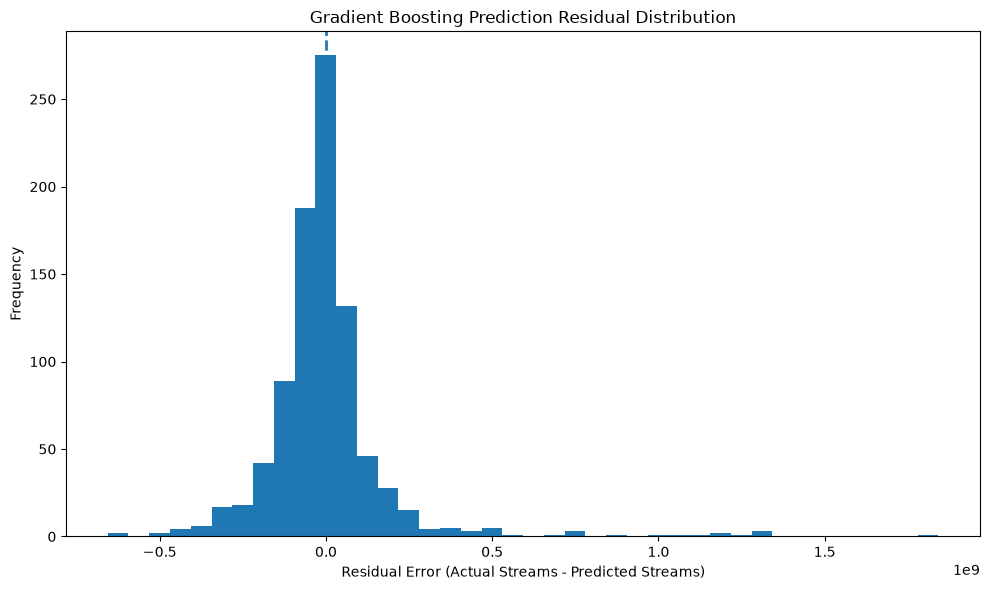


Prediction error validation
Prediction records match testing records: True
Residual calculations valid: True
All predictions assigned an error value: True

Prediction error distribution result
Result: PREDICTION ERROR DISTRIBUTION ANALYSED SUCCESSFULLY
Gradient Boosting forecasting errors are ready for detailed PMIP error analysis.


In [37]:
# ============================================================
# 9.1 Prediction Error Distribution
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PMIP Gradient Boosting prediction error distribution")
print("=" * 75)

# ------------------------------------------------------------
# 1. Generate predictions from the selected model
# ------------------------------------------------------------

gradient_boosting_predictions = gradient_boosting_pipeline.predict(X_test)

# ------------------------------------------------------------
# 2. Create prediction error dataset
# ------------------------------------------------------------

prediction_errors = pd.DataFrame({
    "Actual Spotify Streams": y_test.to_numpy(),
    "Predicted Spotify Streams": gradient_boosting_predictions
})

prediction_errors["Residual"] = (
    prediction_errors["Actual Spotify Streams"]
    - prediction_errors["Predicted Spotify Streams"]
)

prediction_errors["Absolute Error"] = prediction_errors["Residual"].abs()

prediction_errors["Percentage Error"] = np.where(
    prediction_errors["Actual Spotify Streams"] != 0,
    (
        prediction_errors["Absolute Error"]
        / prediction_errors["Actual Spotify Streams"]
    ) * 100,
    np.nan
)

# ------------------------------------------------------------
# 3. Prediction error summary
# ------------------------------------------------------------

print(f"Testing records analysed: {len(prediction_errors):,}")
print(f"Missing predictions: {prediction_errors['Predicted Spotify Streams'].isna().sum():,}")
print(f"Missing residuals: {prediction_errors['Residual'].isna().sum():,}")

print("\nResidual error summary")
print("=" * 75)

residual_summary = prediction_errors[
    ["Residual", "Absolute Error", "Percentage Error"]
].describe().T

display(residual_summary)

# ------------------------------------------------------------
# 4. Direction of prediction errors
# ------------------------------------------------------------

underestimated = (prediction_errors["Residual"] > 0).sum()
overestimated = (prediction_errors["Residual"] < 0).sum()
exact_predictions = (prediction_errors["Residual"] == 0).sum()

print("\nPrediction error direction")
print("=" * 75)

print(f"Underestimated predictions: {underestimated:,}")
print(f"Overestimated predictions: {overestimated:,}")
print(f"Exact predictions: {exact_predictions:,}")

print(
    f"Underestimation percentage: "
    f"{underestimated / len(prediction_errors) * 100:.2f}%"
)

print(
    f"Overestimation percentage: "
    f"{overestimated / len(prediction_errors) * 100:.2f}%"
)

# ------------------------------------------------------------
# 5. Residual distribution visualisation
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    prediction_errors["Residual"].dropna(),
    bins=40
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual Error (Actual Streams - Predicted Streams)")
plt.ylabel("Frequency")
plt.title("Gradient Boosting Prediction Residual Distribution")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

prediction_count_valid = (
    len(prediction_errors) == len(y_test)
)

residual_calculation_valid = np.allclose(
    prediction_errors["Residual"],
    prediction_errors["Actual Spotify Streams"]
    - prediction_errors["Predicted Spotify Streams"]
)

print("\nPrediction error validation")
print("=" * 75)

print(
    f"Prediction records match testing records: "
    f"{prediction_count_valid}"
)

print(
    f"Residual calculations valid: "
    f"{residual_calculation_valid}"
)

print(
    f"All predictions assigned an error value: "
    f"{prediction_errors['Residual'].notna().all()}"
)

print("\nPrediction error distribution result")
print("=" * 75)

if (
    prediction_count_valid
    and residual_calculation_valid
    and prediction_errors["Residual"].notna().all()
):
    print("Result: PREDICTION ERROR DISTRIBUTION ANALYSED SUCCESSFULLY")
    print(
        "Gradient Boosting forecasting errors are ready "
        "for detailed PMIP error analysis."
    )
else:
    print("Result: PREDICTION ERROR ANALYSIS REQUIRES REVIEW")

#### Interpretation

The prediction error analysis was successfully completed for all 897 records in the unseen testing dataset, with no missing predictions or residual values. This confirms that the selected Gradient Boosting model produced a valid prediction for every testing observation and that the residual calculations were successfully generated for further error analysis.

The mean residual was approximately -884,474 streams, which is relatively close to zero compared with the overall scale of Spotify streaming values in the dataset. Since residuals were calculated as actual streams minus predicted streams, the slightly negative mean indicates a small overall tendency for the model to overestimate Spotify Streams. However, the median residual was approximately -13.59 million streams, showing that the typical prediction also leaned slightly towards overestimation.

The direction of the prediction errors provides further evidence of this behaviour. The model underestimated 384 observations, representing 42.81% of the testing dataset, while it overestimated 513 observations, representing 57.19%. Therefore, although prediction errors occur in both directions, the Gradient Boosting model demonstrates a moderate tendency to predict streaming values above their actual values.

The absolute prediction error had a median of approximately 58.01 million streams, while 75% of observations had an absolute error below approximately 122.78 million streams. However, the maximum absolute error reached approximately 1.84 billion streams. This indicates that although many predictions are substantially closer to their actual values, a small number of observations generate extremely large forecasting errors.

The residual distribution supports this conclusion. Most prediction errors are concentrated relatively close to zero, suggesting that the model performs reasonably well for the majority of observations. However, the distribution contains long tails and several extreme residual values, particularly on the positive side. These observations represent tracks where actual streaming performance was considerably higher than the model predicted and suggest that exceptionally successful tracks are more difficult for the model to forecast accurately.

The percentage-error results should be interpreted cautiously. Although the median percentage error was approximately 27.54%, the mean percentage error was extremely large because percentage error becomes highly sensitive when the actual Spotify Streams value is relatively small. Consequently, MAE, RMSE and R² remain more reliable measures of overall forecasting performance for this dataset than the mean percentage error.

Overall, the residual analysis indicates that the Gradient Boosting model produces reasonably concentrated prediction errors for most testing observations but still experiences several substantial errors for extreme streaming outcomes. This behaviour supports the need for further investigation of actual versus predicted performance and the individual observations responsible for the largest prediction errors.

### 9.2 Actual vs Predicted Performance

This subsection compares the actual Spotify Streams values in the unseen testing dataset with the predictions generated by the selected Gradient Boosting forecasting model.

The analysis evaluates how closely predicted streaming performance follows actual performance and identifies whether prediction accuracy changes across different levels of track popularity. A perfect forecasting model would produce predictions that closely follow the actual values across the full streaming range.

A scatter plot is used to visualise the relationship between actual and predicted Spotify Streams. A reference line representing perfect predictions is included to make underestimation and overestimation easier to identify.

PMIP Gradient Boosting actual vs predicted performance
Testing records analysed: 897
Missing actual values: 0
Missing predicted values: 0

Actual versus predicted summary


,Actual Streams,Predicted Streams
count,8.970000e+02,8.970000e+02
mean,4.407159e+08,4.416003e+08
std,5.366584e+08,4.814587e+08
min,1.332000e+03,-1.524931e+08
25%,5.678987e+07,1.017266e+08
50%,2.312986e+08,2.714939e+08
75%,6.275566e+08,5.821867e+08
max,3.301815e+09,2.998264e+09



Actual versus predicted relationship
Actual-predicted correlation: 0.9310


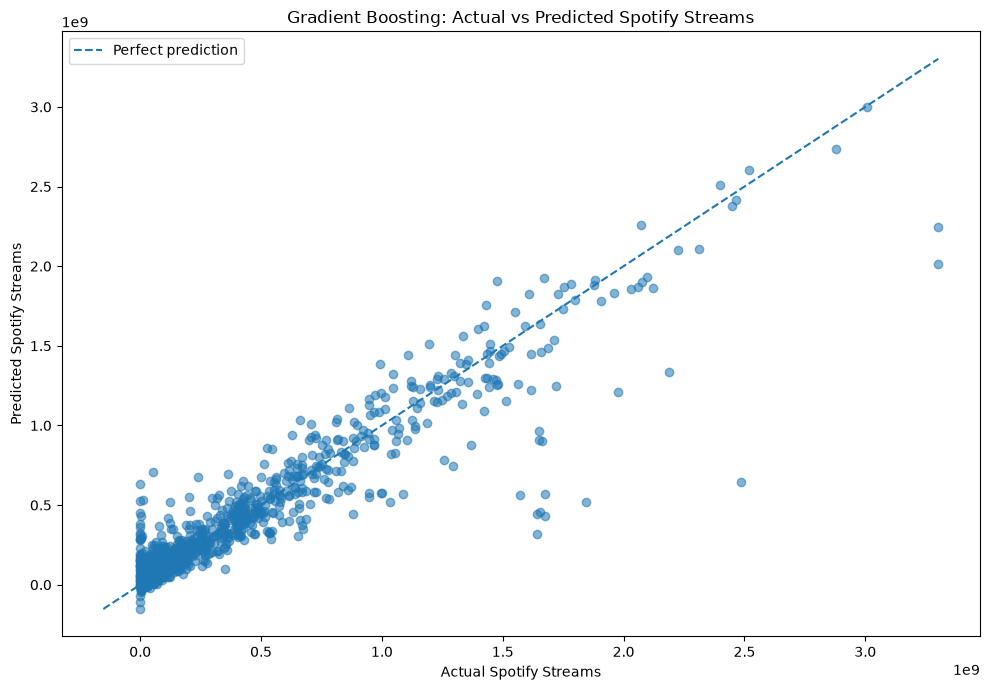


Prediction performance by actual streaming quartile


,Actual Stream Quartile,Records,Mean_Actual_Streams,Mean_Predicted_Streams,Mean_Absolute_Error
0,Q1 - Lowest,225,2.115219e+07,8.520669e+07,7.807943e+07
1,Q2,224,1.251888e+08,1.625346e+08,6.042725e+07
2,Q3,224,4.073012e+08,4.176300e+08,8.067062e+07
3,Q4 - Highest,224,1.211094e+09,1.102621e+09,2.070166e+08



Actual versus predicted validation
Prediction records match testing records: True
All actual testing values available: True
All Gradient Boosting predictions available: True

Actual versus predicted performance result
Result: ACTUAL VS PREDICTED PERFORMANCE ANALYSED SUCCESSFULLY
Gradient Boosting predictions have been compared with actual Spotify Streams across the unseen PMIP testing dataset.


In [38]:
# ============================================================
# 9.2 Actual vs Predicted Performance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PMIP Gradient Boosting actual vs predicted performance")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare actual and predicted values
# ------------------------------------------------------------

actual_streams = np.asarray(y_test, dtype=float)
predicted_streams = np.asarray(
    gradient_boosting_pipeline.predict(X_test),
    dtype=float
)

actual_predicted_df = pd.DataFrame({
    "Actual Spotify Streams": actual_streams,
    "Predicted Spotify Streams": predicted_streams
})

actual_predicted_df["Residual"] = (
    actual_predicted_df["Actual Spotify Streams"]
    - actual_predicted_df["Predicted Spotify Streams"]
)

actual_predicted_df["Absolute Error"] = (
    actual_predicted_df["Residual"].abs()
)

print(f"Testing records analysed: {len(actual_predicted_df):,}")
print(
    f"Missing actual values: "
    f"{actual_predicted_df['Actual Spotify Streams'].isna().sum():,}"
)
print(
    f"Missing predicted values: "
    f"{actual_predicted_df['Predicted Spotify Streams'].isna().sum():,}"
)

# ------------------------------------------------------------
# 2. Actual versus predicted summary
# ------------------------------------------------------------

print("\nActual versus predicted summary")
print("=" * 70)

comparison_summary = pd.DataFrame({
    "Actual Streams": actual_predicted_df[
        "Actual Spotify Streams"
    ].describe(),
    "Predicted Streams": actual_predicted_df[
        "Predicted Spotify Streams"
    ].describe()
})

display(comparison_summary)

# ------------------------------------------------------------
# 3. Prediction relationship
# ------------------------------------------------------------

actual_predicted_correlation = actual_predicted_df[
    ["Actual Spotify Streams", "Predicted Spotify Streams"]
].corr().iloc[0, 1]

print("\nActual versus predicted relationship")
print("=" * 70)

print(
    f"Actual-predicted correlation: "
    f"{actual_predicted_correlation:.4f}"
)

# ------------------------------------------------------------
# 4. Actual versus predicted scatter plot
# ------------------------------------------------------------

minimum_value = min(
    actual_predicted_df["Actual Spotify Streams"].min(),
    actual_predicted_df["Predicted Spotify Streams"].min()
)

maximum_value = max(
    actual_predicted_df["Actual Spotify Streams"].max(),
    actual_predicted_df["Predicted Spotify Streams"].max()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    actual_predicted_df["Actual Spotify Streams"],
    actual_predicted_df["Predicted Spotify Streams"],
    alpha=0.55
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Spotify Streams")
plt.ylabel("Predicted Spotify Streams")
plt.title(
    "Gradient Boosting: Actual vs Predicted Spotify Streams"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Prediction performance by streaming level
# ------------------------------------------------------------

actual_predicted_df["Actual Stream Quartile"] = pd.qcut(
    actual_predicted_df["Actual Spotify Streams"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ],
    duplicates="drop"
)

quartile_performance = (
    actual_predicted_df
    .groupby(
        "Actual Stream Quartile",
        observed=True
    )
    .agg(
        Records=("Actual Spotify Streams", "size"),
        Mean_Actual_Streams=("Actual Spotify Streams", "mean"),
        Mean_Predicted_Streams=("Predicted Spotify Streams", "mean"),
        Mean_Absolute_Error=("Absolute Error", "mean")
    )
    .reset_index()
)

print("\nPrediction performance by actual streaming quartile")
print("=" * 70)

display(quartile_performance)

# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

record_count_valid = (
    len(actual_predicted_df) == len(y_test)
)

predictions_complete = (
    actual_predicted_df[
        "Predicted Spotify Streams"
    ].isna().sum() == 0
)

actual_values_complete = (
    actual_predicted_df[
        "Actual Spotify Streams"
    ].isna().sum() == 0
)

print("\nActual versus predicted validation")
print("=" * 70)

print(
    "Prediction records match testing records:",
    record_count_valid
)

print(
    "All actual testing values available:",
    actual_values_complete
)

print(
    "All Gradient Boosting predictions available:",
    predictions_complete
)

# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\nActual versus predicted performance result")
print("=" * 70)

if (
    record_count_valid
    and predictions_complete
    and actual_values_complete
):
    print(
        "Result: ACTUAL VS PREDICTED PERFORMANCE "
        "ANALYSED SUCCESSFULLY"
    )
    print(
        "Gradient Boosting predictions have been compared "
        "with actual Spotify Streams across the unseen "
        "PMIP testing dataset."
    )
else:
    print(
        "Result: ACTUAL VS PREDICTED PERFORMANCE "
        "REQUIRES REVIEW"
    )

#### Interpretation

The actual-versus-predicted analysis shows that the selected Gradient Boosting model captures the overall pattern of Spotify streaming performance effectively. Across the 897 unseen testing records, the model achieved a strong correlation of 0.9310 between actual and predicted Spotify Streams. This indicates that tracks with higher actual streaming performance generally receive higher predictions from the model, while tracks with lower streaming performance generally receive lower predictions.

The average actual Spotify Streams value was approximately 440.7 million, compared with an average predicted value of approximately 441.6 million. These values are very close at the overall dataset level, suggesting that the model does not show a substantial systematic bias in its average predictions. However, the predicted values have a lower standard deviation than the actual values, indicating that the model produces a narrower range of predictions and does not fully reproduce some of the extreme streaming values present in the testing dataset.

The scatter plot further demonstrates the strong relationship between actual and predicted performance. Most observations are concentrated around the perfect-prediction reference line, particularly within the lower and middle streaming ranges. However, several observations move noticeably away from this line as actual streaming values increase. This suggests that prediction uncertainty becomes greater for some exceptionally high-performing tracks.

The quartile analysis provides additional evidence of this behaviour. For the lowest streaming quartile, the mean actual performance was approximately 21.2 million streams, while the mean prediction was approximately 85.2 million, indicating that the model tends to overestimate some low-streaming tracks. In the second and third quartiles, predicted averages become progressively closer to actual averages, with the third quartile showing particularly similar mean actual and predicted streaming performance.

For the highest streaming quartile, the mean actual performance was approximately 1.21 billion streams compared with approximately 1.10 billion predicted streams. The mean absolute error also increased to approximately 207.0 million streams, substantially higher than in the lower three quartiles. This indicates that the model has greater difficulty predicting the magnitude of extremely successful tracks and tends, on average, to underestimate performance within the highest streaming group.

An additional limitation is that the minimum predicted value is approximately -152.5 million streams. Because Spotify stream counts cannot realistically be negative, this represents an invalid prediction produced by the unconstrained regression model. This does not invalidate the overall model, but it should be documented and considered when the forecasting model is later prepared for use within PMIP, where predictions may need to be constrained to a minimum of zero.

Overall, the results support the earlier evaluation showing that Gradient Boosting provides strong predictive performance on unseen data. The model successfully captures the broad relationship between the available music-performance features and Spotify Streams, but its errors are not distributed equally across all tracks. Prediction accuracy is weaker at the extremes of the streaming distribution, particularly for very low-performing and exceptionally high-performing tracks. These observations provide the motivation for the following high-error prediction analysis.

### 9.3 High-Error Prediction Analysis

Although the Gradient Boosting model achieved strong overall predictive performance, the previous analysis showed that some tracks produce substantially larger prediction errors than others. High-error prediction analysis is therefore used to investigate the observations that the model finds most difficult to forecast.

This subsection identifies tracks within the highest prediction-error range using absolute residual error. The analysis compares these observations with the wider testing dataset and examines whether unusually large errors are associated with extremely high streaming performance.

Understanding these cases is important for evaluating the limitations of the PMIP forecasting model. Large prediction errors may indicate unusual tracks, extreme streaming outcomes, missing explanatory information, or relationships that are not fully captured by the available predictor features.

PMIP Gradient Boosting high-error prediction analysis
Testing records analysed: 897
Missing absolute errors: 0

High-error threshold
90th percentile absolute-error threshold: 222,693,142.78
High-error predictions: 90
High-error percentage: 10.03%

High-error performance summary


,All Testing Records,High-Error Records
Mean Actual Streams,4.407159e+08,8.728775e+08
Mean Predicted Streams,4.416003e+08,7.473310e+08
Mean Absolute Error,1.065167e+08,4.647888e+08



High-error prediction direction
Underestimated high-error predictions: 44
Overestimated high-error predictions: 46
Underestimation percentage: 48.89%
Overestimation percentage: 51.11%

15 largest Gradient Boosting prediction errors


,Actual Spotify Streams,Predicted Spotify Streams,Residual,Absolute Error,Percentage Error
269,2.486909e+09,6.446515e+08,1.842257e+09,1.842257e+09,74.078197
254,1.842759e+09,5.164222e+08,1.326337e+09,1.326337e+09,71.975595
380,1.642258e+09,3.212457e+08,1.321013e+09,1.321013e+09,80.438783
121,3.299082e+09,2.016485e+09,1.282597e+09,1.282597e+09,38.877390
394,1.673557e+09,4.322924e+08,1.241265e+09,1.241265e+09,74.169247
476,1.653018e+09,4.543710e+08,1.198647e+09,1.198647e+09,72.512644
550,1.642258e+09,4.439787e+08,1.198280e+09,1.198280e+09,72.965357
274,1.673557e+09,5.684156e+08,1.105141e+09,1.105141e+09,66.035480
295,3.301815e+09,2.245393e+09,1.056422e+09,1.056422e+09,31.995192
731,1.570234e+09,5.622472e+08,1.007986e+09,1.007986e+09,64.193406



High-error predictions by streaming quartile


,Actual Stream Quartile,Records,High_Error_Records,Mean_Absolute_Error,High_Error_Percentage
0,Q1 - Lowest,225,17,7.807943e+07,7.555556
1,Q2,224,7,6.042725e+07,3.125000
2,Q3,224,12,8.067062e+07,5.357143
3,Q4 - Highest,224,54,2.070166e+08,24.107143


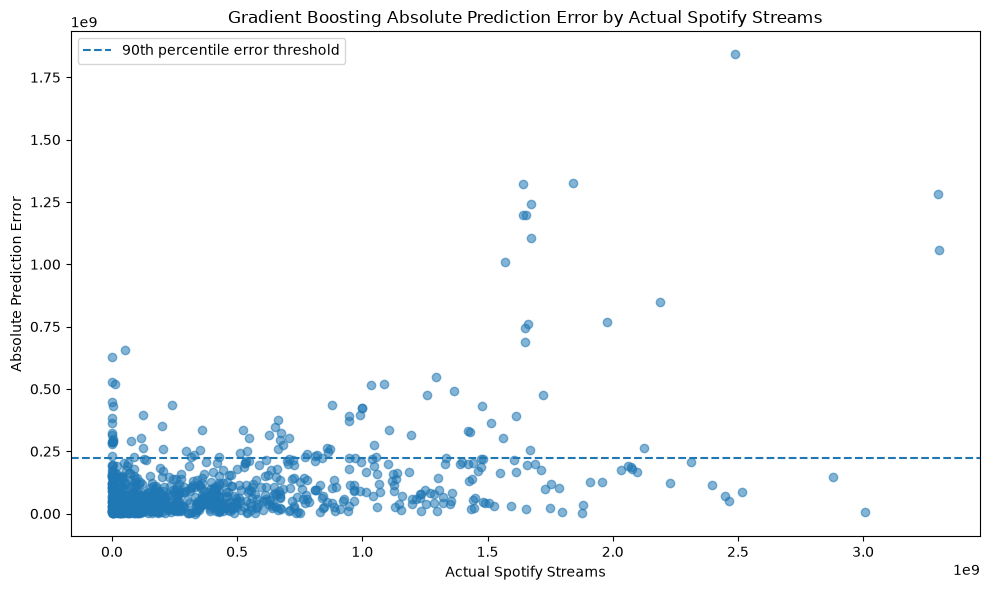


High-error analysis validation
Prediction records match testing records: True
All testing records contain an absolute error: True
High-error observations successfully identified: True

High-error prediction analysis result
Result: HIGH-ERROR PREDICTION ANALYSIS COMPLETED SUCCESSFULLY
The largest Gradient Boosting forecasting errors have been identified for detailed PMIP model evaluation.


In [39]:
# ============================================================
# 9.3 High-Error Prediction Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PMIP Gradient Boosting high-error prediction analysis")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare prediction error dataset
# ------------------------------------------------------------

high_error_df = pd.DataFrame({
    "Actual Spotify Streams": np.asarray(y_test, dtype=float),
    "Predicted Spotify Streams": np.asarray(
        gradient_boosting_pipeline.predict(X_test),
        dtype=float
    )
})

high_error_df["Residual"] = (
    high_error_df["Actual Spotify Streams"]
    - high_error_df["Predicted Spotify Streams"]
)

high_error_df["Absolute Error"] = (
    high_error_df["Residual"].abs()
)

# Percentage error is retained for descriptive analysis.
# A minimum denominator of 1 prevents division by zero.
high_error_df["Percentage Error"] = (
    high_error_df["Absolute Error"]
    / high_error_df["Actual Spotify Streams"].abs().clip(lower=1)
) * 100

print(f"Testing records analysed: {len(high_error_df):,}")
print(
    f"Missing absolute errors: "
    f"{high_error_df['Absolute Error'].isna().sum():,}"
)

# ------------------------------------------------------------
# 2. Define high-error threshold
# ------------------------------------------------------------

high_error_threshold = high_error_df[
    "Absolute Error"
].quantile(0.90)

high_error_df["High Error"] = (
    high_error_df["Absolute Error"] >= high_error_threshold
)

high_error_records = high_error_df[
    high_error_df["High Error"]
].copy()

print("\nHigh-error threshold")
print("=" * 70)

print(
    f"90th percentile absolute-error threshold: "
    f"{high_error_threshold:,.2f}"
)

print(
    f"High-error predictions: "
    f"{len(high_error_records):,}"
)

print(
    f"High-error percentage: "
    f"{len(high_error_records) / len(high_error_df) * 100:.2f}%"
)

# ------------------------------------------------------------
# 3. Compare high-error records with all testing records
# ------------------------------------------------------------

print("\nHigh-error performance summary")
print("=" * 70)

error_group_summary = pd.DataFrame({
    "All Testing Records": [
        high_error_df["Actual Spotify Streams"].mean(),
        high_error_df["Predicted Spotify Streams"].mean(),
        high_error_df["Absolute Error"].mean()
    ],
    "High-Error Records": [
        high_error_records["Actual Spotify Streams"].mean(),
        high_error_records["Predicted Spotify Streams"].mean(),
        high_error_records["Absolute Error"].mean()
    ]
}, index=[
    "Mean Actual Streams",
    "Mean Predicted Streams",
    "Mean Absolute Error"
])

display(error_group_summary)

# ------------------------------------------------------------
# 4. Prediction direction among high-error records
# ------------------------------------------------------------

high_error_underestimated = (
    high_error_records["Residual"] > 0
).sum()

high_error_overestimated = (
    high_error_records["Residual"] < 0
).sum()

print("\nHigh-error prediction direction")
print("=" * 70)

print(
    f"Underestimated high-error predictions: "
    f"{high_error_underestimated:,}"
)

print(
    f"Overestimated high-error predictions: "
    f"{high_error_overestimated:,}"
)

print(
    f"Underestimation percentage: "
    f"{high_error_underestimated / len(high_error_records) * 100:.2f}%"
)

print(
    f"Overestimation percentage: "
    f"{high_error_overestimated / len(high_error_records) * 100:.2f}%"
)

# ------------------------------------------------------------
# 5. Largest individual prediction errors
# ------------------------------------------------------------

largest_errors = (
    high_error_df
    .sort_values("Absolute Error", ascending=False)
    .head(15)
    .copy()
)

print("\n15 largest Gradient Boosting prediction errors")
print("=" * 70)

display(
    largest_errors[
        [
            "Actual Spotify Streams",
            "Predicted Spotify Streams",
            "Residual",
            "Absolute Error",
            "Percentage Error"
        ]
    ]
)

# ------------------------------------------------------------
# 6. High-error distribution by actual streaming quartile
# ------------------------------------------------------------

high_error_df["Actual Stream Quartile"] = pd.qcut(
    high_error_df["Actual Spotify Streams"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ],
    duplicates="drop"
)

high_error_quartile_summary = (
    high_error_df
    .groupby(
        "Actual Stream Quartile",
        observed=True
    )
    .agg(
        Records=("High Error", "size"),
        High_Error_Records=("High Error", "sum"),
        Mean_Absolute_Error=("Absolute Error", "mean")
    )
    .reset_index()
)

high_error_quartile_summary[
    "High_Error_Percentage"
] = (
    high_error_quartile_summary["High_Error_Records"]
    / high_error_quartile_summary["Records"]
    * 100
)

print("\nHigh-error predictions by streaming quartile")
print("=" * 70)

display(high_error_quartile_summary)

# ------------------------------------------------------------
# 7. Visualise absolute prediction errors
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    high_error_df["Actual Spotify Streams"],
    high_error_df["Absolute Error"],
    alpha=0.55
)

plt.axhline(
    high_error_threshold,
    linestyle="--",
    label="90th percentile error threshold"
)

plt.xlabel("Actual Spotify Streams")
plt.ylabel("Absolute Prediction Error")
plt.title(
    "Gradient Boosting Absolute Prediction Error "
    "by Actual Spotify Streams"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

all_records_have_error = (
    high_error_df["Absolute Error"].isna().sum() == 0
)

high_error_records_identified = (
    len(high_error_records) > 0
)

record_count_valid = (
    len(high_error_df) == len(y_test)
)

print("\nHigh-error analysis validation")
print("=" * 70)

print(
    "Prediction records match testing records:",
    record_count_valid
)

print(
    "All testing records contain an absolute error:",
    all_records_have_error
)

print(
    "High-error observations successfully identified:",
    high_error_records_identified
)

# ------------------------------------------------------------
# 9. Final result
# ------------------------------------------------------------

print("\nHigh-error prediction analysis result")
print("=" * 70)

if (
    record_count_valid
    and all_records_have_error
    and high_error_records_identified
):
    print(
        "Result: HIGH-ERROR PREDICTION ANALYSIS "
        "COMPLETED SUCCESSFULLY"
    )
    print(
        "The largest Gradient Boosting forecasting errors "
        "have been identified for detailed PMIP model "
        "evaluation."
    )
else:
    print(
        "Result: HIGH-ERROR PREDICTION ANALYSIS "
        "REQUIRES REVIEW"
    )

#### Interpretation

The high-error prediction analysis shows that the selected Gradient Boosting model produced 90 high-error predictions from the 897 testing records. These predictions were identified using the 90th percentile absolute-error threshold of approximately 222.7 million Spotify Streams, meaning that around 10.03% of the testing observations were classified as high-error cases.

The high-error records were associated with substantially higher streaming performance than the testing dataset overall. The average actual Spotify Streams value across all testing records was approximately 440.7 million, while the average for the high-error records was approximately 872.9 million. The mean absolute error also increased from approximately 106.5 million across the full testing dataset to approximately 464.8 million among the high-error observations.

The direction of the high-error predictions was relatively balanced. Of the 90 high-error observations, 44 predictions were underestimated and 46 were overestimated, representing 48.89% and 51.11% respectively. This suggests that the largest prediction errors are not caused by a strong tendency to consistently predict too high or too low.

The largest individual errors mainly occurred among tracks with exceptionally high Spotify Streams. For example, the largest error involved an actual streaming value of approximately 2.49 billion streams compared with a prediction of approximately 644.7 million, producing an absolute error of approximately 1.84 billion streams. Several other large errors also occurred for tracks with actual streaming totals above one billion streams.

The streaming quartile analysis further demonstrates this pattern. The highest streaming quartile contained 54 high-error predictions from 224 records, equivalent to approximately 24.11% of the quartile. In comparison, the high-error percentages were approximately 7.56% for Q1, 3.13% for Q2 and 5.36% for Q3. Therefore, 60% of all identified high-error predictions occurred within the highest streaming quartile.

The absolute-error scatter plot supports these findings by showing that most observations have relatively moderate prediction errors, while several much larger errors appear as actual Spotify Streams increase. This suggests that the Gradient Boosting model experiences greater difficulty forecasting exceptionally high-performing tracks.

Overall, the analysis indicates that the Gradient Boosting model performs effectively across much of the testing dataset but becomes less reliable for extreme streaming outcomes. This represents an important limitation of the PMIP forecasting model and suggests that predictions for exceptionally high-streaming tracks should be interpreted with greater caution.

## 10. Model Interpretation

This section interprets the selected Gradient Boosting forecasting model to understand the factors that contribute most strongly to its Spotify Streams predictions. Model interpretation is important for PMIP because forecasting performance alone does not explain why particular predictions are produced.

The analysis examines feature importance, identifies the most influential performance indicators and translates the model results into meaningful music-intelligence insights that can support the Public Music Intelligence Platform.

### 10.1 Feature Importance

This subsection extracts and analyses the feature importance values learned by the selected Gradient Boosting model. Feature importance measures the relative contribution of each predictor to the model's forecasting decisions.

The analysis will rank the transformed predictor features by importance and examine which variables contribute most strongly to predicting Spotify Streams.

PMIP Gradient Boosting feature importance
Feature importance values extracted: 49
Feature importance total: 1.000000
Transformed feature names recovered: 49
Feature names align with importance values: True

Top 20 most important forecasting features


,Feature,Importance,Importance (%),Cumulative Importance (%)
0,numerical__Spotify Playlist Count,0.427591,42.759079,42.759079
1,numerical__total_historical_streams,0.146680,14.667997,57.427075
2,numerical__chart_observations,0.088231,8.823118,66.250193
3,numerical__Spotify Playlist Reach,0.061752,6.175239,72.425432
4,numerical__chart_activity_factor,0.059604,5.960394,78.385826
5,numerical__Spotify Popularity,0.027432,2.743201,81.129027
6,numerical__Shazam Counts,0.024214,2.421397,83.550424
7,numerical__chart_longevity_days,0.019720,1.972017,85.522440
8,numerical__chart_longevity_years,0.017670,1.766979,87.289419
9,numerical__countries_charted,0.014433,1.443263,88.732682



Feature importance concentration
Features with non-zero importance: 47
Top 5 features contribution:  78.39%
Top 10 features contribution: 88.73%
Top 20 features contribution: 98.03%


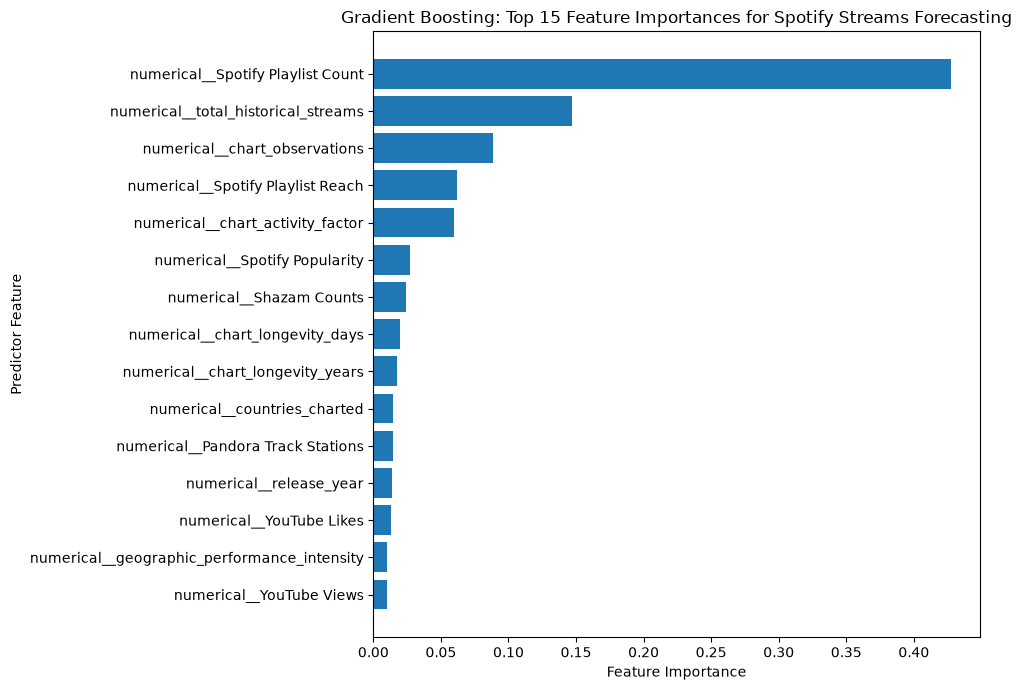


Feature importance validation
Feature importance values valid: True
Feature importance values sum to 1: True
All transformed predictors represented: True

Feature importance analysis result
Result: GRADIENT BOOSTING FEATURE IMPORTANCE ANALYSED SUCCESSFULLY
The predictor variables contributing most strongly to PMIP Spotify Streams forecasting have been identified and ranked.


In [40]:
# 10.1 Feature Importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PMIP Gradient Boosting feature importance")
print("=" * 70)

# ------------------------------------------------------------
# 1. Access fitted preprocessing and Gradient Boosting model
# ------------------------------------------------------------

fitted_preprocessor = gradient_boosting_pipeline.named_steps["preprocessor"]
fitted_gradient_model = gradient_boosting_pipeline.named_steps["model"]

feature_importances = fitted_gradient_model.feature_importances_

print(f"Feature importance values extracted: {len(feature_importances):,}")
print(f"Feature importance total: {feature_importances.sum():.6f}")


# ------------------------------------------------------------
# 2. Recover transformed feature names
# ------------------------------------------------------------

try:
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = np.array(
        [f"Feature_{i}" for i in range(len(feature_importances))]
    )

print(f"Transformed feature names recovered: {len(transformed_feature_names):,}")
print(
    "Feature names align with importance values:",
    len(transformed_feature_names) == len(feature_importances)
)


# ------------------------------------------------------------
# 3. Create feature-importance table
# ------------------------------------------------------------

feature_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": feature_importances
})

# Remove preprocessing prefixes to improve readability
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df["Importance (%)"] = (
    feature_importance_df["Importance"] * 100
)

feature_importance_df["Cumulative Importance (%)"] = (
    feature_importance_df["Importance (%)"].cumsum()
)

print("\nTop 20 most important forecasting features")
print("=" * 70)

display(
    feature_importance_df[
        ["Feature", "Importance", "Importance (%)", "Cumulative Importance (%)"]
    ].head(20)
)


# ------------------------------------------------------------
# 4. Feature importance concentration
# ------------------------------------------------------------

top_5_importance = feature_importance_df.head(5)["Importance"].sum()
top_10_importance = feature_importance_df.head(10)["Importance"].sum()
top_20_importance = feature_importance_df.head(20)["Importance"].sum()

non_zero_features = (feature_importance_df["Importance"] > 0).sum()

print("\nFeature importance concentration")
print("=" * 70)

print(f"Features with non-zero importance: {non_zero_features:,}")
print(f"Top 5 features contribution:  {top_5_importance * 100:.2f}%")
print(f"Top 10 features contribution: {top_10_importance * 100:.2f}%")
print(f"Top 20 features contribution: {top_20_importance * 100:.2f}%")


# ------------------------------------------------------------
# 5. Visualise top 15 features
# ------------------------------------------------------------

top_features = feature_importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor Feature")
plt.title(
    "Gradient Boosting: Top 15 Feature Importances for Spotify Streams Forecasting"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

importance_values_valid = (
    np.isfinite(feature_importance_df["Importance"]).all()
    and (feature_importance_df["Importance"] >= 0).all()
)

importance_sum_valid = np.isclose(
    feature_importance_df["Importance"].sum(),
    1.0
)

print("\nFeature importance validation")
print("=" * 70)

print(
    "Feature importance values valid:",
    importance_values_valid
)

print(
    "Feature importance values sum to 1:",
    importance_sum_valid
)

print(
    "All transformed predictors represented:",
    len(feature_importance_df) == len(feature_importances)
)


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\nFeature importance analysis result")
print("=" * 70)

print("Result: GRADIENT BOOSTING FEATURE IMPORTANCE ANALYSED SUCCESSFULLY")
print(
    "The predictor variables contributing most strongly to PMIP Spotify Streams "
    "forecasting have been identified and ranked."
)

#### Interpretation

The feature-importance analysis shows that the selected Gradient Boosting model relies most strongly on Spotify playlist exposure and historical streaming performance when forecasting Spotify Streams. All 49 transformed predictor features were successfully analysed, and the feature-importance values sum to 1.0, confirming that the model interpretation results are internally consistent.

Spotify Playlist Count is by far the most influential predictor, accounting for approximately 42.76% of the model's total feature importance. This suggests that the number of Spotify playlists containing a track provides a particularly strong signal for estimating its streaming performance within the PMIP forecasting model. Spotify Playlist Reach is also among the leading predictors, contributing approximately 6.18%, further demonstrating the importance of playlist exposure.

Historical performance also makes a substantial contribution to the predictions. Total historical streams is the second most important feature at approximately 14.67%, while chart observations contributes approximately 8.82% and the engineered chart activity factor contributes approximately 5.96%. Together, these results indicate that previous streaming success and sustained historical chart activity provide valuable information for forecasting current Spotify performance.

Several additional indicators contribute smaller but still meaningful amounts of predictive information. Spotify Popularity contributes approximately 2.74%, Shazam Counts approximately 2.42%, while chart longevity, countries charted, Pandora Track Stations, release year, YouTube Likes and geographic performance intensity also appear among the most important predictors. This demonstrates that the model combines information from streaming platforms, historical charts, geographic reach, release characteristics and wider digital engagement rather than depending entirely on a single source of music-performance data.

The importance values are relatively concentrated among a small group of predictors. The five most influential features account for approximately 78.39% of total model importance, the top ten account for approximately 88.73%, and the top twenty account for approximately 98.03%. Although 47 features have non-zero importance, most of the Gradient Boosting model's predictive decisions are therefore driven by a much smaller collection of strong performance indicators.

These importance values should be interpreted as measures of how useful the variables were to the Gradient Boosting model rather than evidence that any feature directly causes higher Spotify Streams. In particular, related variables such as chart longevity in days and years may share overlapping information, while playlist exposure and streaming success may themselves be closely associated.

Overall, the results provide useful interpretability for PMIP by showing that Spotify playlist exposure, historical streaming performance, sustained chart activity and cross-platform engagement are the strongest signals used by the selected forecasting model. This provides the foundation for identifying and interpreting the most influential music-performance indicators in the next stage of the analysis.

### 10.2 Most Influential Performance Indicators

The feature-importance analysis identified the individual predictor variables used most strongly by the selected Gradient Boosting forecasting model. This subsection groups these influential variables into broader performance-indicator categories to provide a clearer interpretation of the factors associated with Spotify streaming performance.

The analysis considers indicators representing Spotify platform exposure, historical chart performance, geographic reach, cross-platform engagement and release characteristics. The importance of the individual features within each category is aggregated to examine which types of performance information contribute most strongly to the model's predictions.

PMIP most influential performance indicators

Performance indicator importance


,Performance Indicator,Importance,Importance (%)
0,Spotify Platform Exposure,0.516775,51.677518
1,Historical Chart Performance,0.337436,33.743566
2,Cross-Platform Engagement,0.083163,8.316332
3,Geographic Performance,0.030561,3.056134
4,Release Characteristics,0.017957,1.795652
5,Other Predictors,0.014108,1.410797



Top 15 features by performance indicator


,Clean Feature,Performance Indicator,Importance (%)
0,Spotify Playlist Count,Spotify Platform Exposure,42.759079
1,total_historical_streams,Historical Chart Performance,14.667997
2,chart_observations,Historical Chart Performance,8.823118
3,Spotify Playlist Reach,Spotify Platform Exposure,6.175239
4,chart_activity_factor,Historical Chart Performance,5.960394
5,Spotify Popularity,Spotify Platform Exposure,2.743201
6,Shazam Counts,Cross-Platform Engagement,2.421397
7,chart_longevity_days,Historical Chart Performance,1.972017
8,chart_longevity_years,Historical Chart Performance,1.766979
9,countries_charted,Geographic Performance,1.443263



Leading PMIP performance indicator
Indicator: Spotify Platform Exposure
Combined feature importance: 51.68%


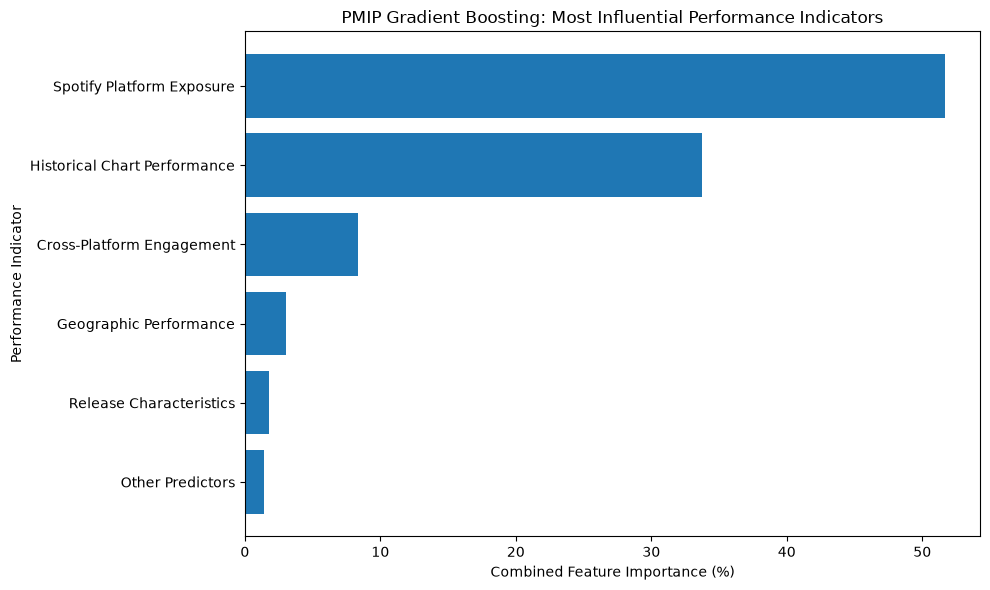


Performance indicator validation
All feature-importance values represented: True
Aggregated importance total: 1.000000
Aggregated importance sums to 1: True

Most influential performance indicators result
Result: PMIP PERFORMANCE INDICATORS IDENTIFIED SUCCESSFULLY
The selected model's predictor features have been grouped into interpretable music-performance indicator categories.


In [41]:
# 10.2 Most Influential Performance Indicators

import pandas as pd

print("PMIP most influential performance indicators")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create a clean version of the transformed feature names
# ------------------------------------------------------------

indicator_importance_df = feature_importance_df.copy()

indicator_importance_df["Clean Feature"] = (
    indicator_importance_df["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# ------------------------------------------------------------
# 2. Define PMIP performance-indicator groups
# ------------------------------------------------------------

indicator_groups = {
    "Spotify Platform Exposure": [
        "Spotify Playlist Count",
        "Spotify Playlist Reach",
        "Spotify Popularity"
    ],

    "Historical Chart Performance": [
        "total_historical_streams",
        "chart_observations",
        "chart_activity_factor",
        "chart_longevity_days",
        "chart_longevity_years",
        "best_chart_position",
        "average_chart_position",
        "best_chart_strength",
        "average_chart_strength",
        "peak_chart_performance",
        "average_chart_performance",
        "historical_streaming_intensity"
    ],

    "Geographic Performance": [
        "countries_charted",
        "market_coverage_score",
        "geographic_performance_intensity",
        "broad_geographic_reach"
    ],

    "Cross-Platform Engagement": [
        "Shazam Counts",
        "Pandora Track Stations",
        "Pandora Streams",
        "YouTube Likes",
        "YouTube Views",
        "Apple Music Playlist Count",
        "Deezer Playlist Count"
    ],

    "Release Characteristics": [
        "release_year",
        "release_month",
        "release_age_days",
        "release_age_years"
    ]
}

# ------------------------------------------------------------
# 3. Assign each feature to an indicator group
# ------------------------------------------------------------

def assign_indicator_group(feature_name):
    for group_name, features in indicator_groups.items():
        if feature_name in features:
            return group_name

    return "Other Predictors"


indicator_importance_df["Performance Indicator"] = (
    indicator_importance_df["Clean Feature"]
    .apply(assign_indicator_group)
)

# ------------------------------------------------------------
# 4. Aggregate feature importance by performance indicator
# ------------------------------------------------------------

performance_indicator_summary = (
    indicator_importance_df
    .groupby("Performance Indicator", as_index=False)["Importance"]
    .sum()
)

performance_indicator_summary["Importance (%)"] = (
    performance_indicator_summary["Importance"] * 100
)

performance_indicator_summary = (
    performance_indicator_summary
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nPerformance indicator importance")
print("=" * 70)

display(
    performance_indicator_summary[
        [
            "Performance Indicator",
            "Importance",
            "Importance (%)"
        ]
    ]
)

# ------------------------------------------------------------
# 5. Show the strongest individual features and their groups
# ------------------------------------------------------------

top_indicator_features = (
    indicator_importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
    .copy()
)

top_indicator_features["Importance (%)"] = (
    top_indicator_features["Importance"] * 100
)

print("\nTop 15 features by performance indicator")
print("=" * 70)

display(
    top_indicator_features[
        [
            "Clean Feature",
            "Performance Indicator",
            "Importance (%)"
        ]
    ]
)

# ------------------------------------------------------------
# 6. Identify the leading performance indicator
# ------------------------------------------------------------

leading_indicator = performance_indicator_summary.iloc[0]

print("\nLeading PMIP performance indicator")
print("=" * 70)

print(
    f"Indicator: {leading_indicator['Performance Indicator']}"
)

print(
    f"Combined feature importance: "
    f"{leading_indicator['Importance (%)']:.2f}%"
)

# ------------------------------------------------------------
# 7. Visualise aggregated indicator importance
# ------------------------------------------------------------

plot_data = (
    performance_indicator_summary
    .sort_values("Importance (%)", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Performance Indicator"],
    plot_data["Importance (%)"]
)

plt.xlabel("Combined Feature Importance (%)")
plt.ylabel("Performance Indicator")
plt.title(
    "PMIP Gradient Boosting: Most Influential Performance Indicators"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

indicator_total = performance_indicator_summary["Importance"].sum()

all_features_assigned = (
    len(indicator_importance_df) == len(feature_importance_df)
)

print("\nPerformance indicator validation")
print("=" * 70)

print(
    f"All feature-importance values represented: "
    f"{all_features_assigned}"
)

print(
    f"Aggregated importance total: "
    f"{indicator_total:.6f}"
)

print(
    f"Aggregated importance sums to 1: "
    f"{np.isclose(indicator_total, 1.0)}"
)

print("\nMost influential performance indicators result")
print("=" * 70)

print(
    "Result: PMIP PERFORMANCE INDICATORS IDENTIFIED SUCCESSFULLY"
)

print(
    "The selected model's predictor features have been grouped "
    "into interpretable music-performance indicator categories."
)

#### Interpretation

The performance-indicator analysis shows that Spotify Platform Exposure is the most influential category within the selected Gradient Boosting forecasting model, accounting for approximately 51.68% of total feature importance. This means that more than half of the model's predictive importance is associated with Spotify-specific visibility indicators, including Spotify Playlist Count, Spotify Playlist Reach and Spotify Popularity.

Within this category, Spotify Playlist Count is particularly influential, contributing approximately 42.76% on its own, while Spotify Playlist Reach contributes approximately 6.18% and Spotify Popularity contributes approximately 2.74%. These results suggest that playlist-based exposure represents one of the strongest signals available to the model when estimating Spotify streaming performance.

Historical Chart Performance is the second most influential category, contributing approximately 33.74% of total importance. Important variables within this group include total historical streams at approximately 14.67%, chart observations at approximately 8.82%, chart activity factor at approximately 5.96%, and measures of chart longevity. This indicates that the model places substantial importance on whether a track has demonstrated strong and sustained performance historically.

Cross-Platform Engagement contributes approximately 8.32% of total model importance. This category includes signals such as Shazam Counts, Pandora Track Stations, YouTube Likes and YouTube Views. Although individually smaller than the strongest Spotify and historical indicators, their combined contribution shows that activity outside Spotify provides additional information that helps the model understand wider public engagement with a track.

Geographic Performance contributes approximately 3.06% of total importance. Countries charted and geographic performance intensity appear among the strongest variables within this category. This suggests that the geographical spread and intensity of a track's historical performance provide additional predictive information, although their contribution is considerably smaller than Spotify exposure and historical chart performance.

Release Characteristics account for approximately 1.80% of total feature importance, with release year appearing among the fifteen strongest individual predictors. Other predictors account for the remaining approximately 1.41%. Therefore, release timing and the remaining variables contribute useful supplementary information but are not the primary factors driving the model's forecasts.

Overall, Spotify Platform Exposure and Historical Chart Performance together account for approximately 85.42% of the model's total feature importance. This provides a clear PMIP interpretation: the selected Gradient Boosting model primarily forecasts Spotify Streams using evidence of a track's current Spotify visibility together with its previous streaming and chart-performance history, while cross-platform engagement, geographic performance and release characteristics provide supporting predictive information. These relationships represent predictive associations identified by the model and should not be interpreted as evidence that any individual indicator directly causes higher streaming performance.

### 10.3 PMIP Interpretation of Model Results

The previous analyses evaluated the selected Gradient Boosting forecasting model from several perspectives, including predictive performance, generalisation, prediction errors and feature importance. This final interpretation stage brings these findings together to explain what the model has learned and how its outputs can contribute to the Public Music Intelligence Platform.

The objective is not only to determine whether the model can generate useful Spotify Streams predictions, but also to establish how those predictions should be interpreted within PMIP and to identify the strengths and limitations that should accompany the forecasting intelligence presented to users.

In [43]:
# 10.3 PMIP Interpretation of Model Results

print("PMIP interpretation of Gradient Boosting forecasting results")
print("=" * 80)

# ------------------------------------------------------------
# Selected forecasting model and validated performance results
# ------------------------------------------------------------

selected_model_name = "Gradient Boosting"

test_mae = 106_516_740.01
test_rmse = 196_669_489.28
test_r2 = 0.8655

train_r2 = 0.9064
r2_gap = 0.0408

mae_generalisation_gap = 25.19
rmse_generalisation_gap = 19.24

actual_predicted_correlation = 0.9310

# ------------------------------------------------------------
# Error-analysis results
# ------------------------------------------------------------

testing_records = 897
high_error_records = 90
high_error_percentage = 10.03

underestimated_percentage = 42.81
overestimated_percentage = 57.19

# ------------------------------------------------------------
# Performance-indicator results from Section 10.2
# ------------------------------------------------------------

spotify_exposure_importance = 51.68
historical_performance_importance = 33.74
cross_platform_importance = 8.32
geographic_importance = 3.06
release_importance = 1.80

combined_primary_importance = (
    spotify_exposure_importance
    + historical_performance_importance
)

# ------------------------------------------------------------
# Model performance interpretation
# ------------------------------------------------------------

print("\nForecasting performance")
print("=" * 80)

print(f"Selected model: {selected_model_name}")
print(f"Testing records: {testing_records:,}")
print(f"Testing MAE: {test_mae:,.2f}")
print(f"Testing RMSE: {test_rmse:,.2f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Actual-predicted correlation: {actual_predicted_correlation:.4f}")

print(
    f"\nThe selected model explains approximately "
    f"{test_r2 * 100:.2f}% of the variation in Spotify Streams "
    f"within the unseen testing dataset."
)

# ------------------------------------------------------------
# Generalisation interpretation
# ------------------------------------------------------------

print("\nGeneralisation behaviour")
print("=" * 80)

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"R² generalisation gap: {r2_gap:.4f}")
print(f"MAE generalisation gap: {mae_generalisation_gap:.2f}%")
print(f"RMSE generalisation gap: {rmse_generalisation_gap:.2f}%")

print(
    "\nGradient Boosting was selected because it provides a stronger "
    "balance between unseen-data predictive performance and "
    "generalisation stability than the higher-performing Random Forest."
)

# ------------------------------------------------------------
# Prediction-error interpretation
# ------------------------------------------------------------

print("\nPrediction-error behaviour")
print("=" * 80)

print(f"High-error predictions: {high_error_records}")
print(f"High-error percentage: {high_error_percentage:.2f}%")
print(f"Underestimated predictions: {underestimated_percentage:.2f}%")
print(f"Overestimated predictions: {overestimated_percentage:.2f}%")

print(
    "\nThe error analysis indicates that most predictions fall below "
    "the high-error threshold, although forecasting becomes more "
    "difficult for some extremely high-streaming observations."
)

# ------------------------------------------------------------
# PMIP performance-indicator interpretation
# ------------------------------------------------------------

print("\nPMIP performance indicators")
print("=" * 80)

indicator_summary = pd.DataFrame({
    "Performance Indicator": [
        "Spotify Platform Exposure",
        "Historical Chart Performance",
        "Cross-Platform Engagement",
        "Geographic Performance",
        "Release Characteristics"
    ],
    "Importance (%)": [
        spotify_exposure_importance,
        historical_performance_importance,
        cross_platform_importance,
        geographic_importance,
        release_importance
    ]
})

display(indicator_summary)

print(
    f"\nSpotify Platform Exposure and Historical Chart Performance "
    f"together account for approximately "
    f"{combined_primary_importance:.2f}% of total model importance."
)

# ------------------------------------------------------------
# Public Music Intelligence Platform interpretation
# ------------------------------------------------------------

print("\nPublic Music Intelligence Platform interpretation")
print("=" * 80)

print(
    "The forecasting results suggest that Spotify streaming performance "
    "can be estimated effectively by combining platform exposure, "
    "historical chart behaviour, cross-platform engagement, geographic "
    "performance and release-related information."
)

print(
    "\nThe strongest predictive evidence comes from Spotify exposure "
    "and historical performance. This means PMIP can use these signals "
    "to provide interpretable forecasting intelligence about the "
    "performance characteristics associated with tracks in the dataset."
)

print(
    "\nThese model relationships represent predictive associations and "
    "should not be interpreted as evidence that the identified features "
    "directly cause higher Spotify streaming performance."
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\nPMIP interpretation validation")
print("=" * 80)

validation_checks = {
    "Selected model identified": selected_model_name == "Gradient Boosting",
    "Testing R² valid": 0 <= test_r2 <= 1,
    "Testing MAE positive": test_mae > 0,
    "Testing RMSE positive": test_rmse > 0,
    "Correlation valid": -1 <= actual_predicted_correlation <= 1,
    "High-error percentage valid": 0 <= high_error_percentage <= 100,
    "Primary importance valid": 0 <= combined_primary_importance <= 100
}

for check, result in validation_checks.items():
    print(f"{check}: {result}")

all_checks_passed = all(validation_checks.values())

print("\nPMIP interpretation result")
print("=" * 80)

if all_checks_passed:
    print("Result: PMIP FORECASTING MODEL INTERPRETATION COMPLETED SUCCESSFULLY")
    print(
        "Gradient Boosting forecasting performance, generalisation, "
        "prediction errors and influential music-performance indicators "
        "have been interpreted successfully."
    )
else:
    print("Result: PMIP FORECASTING MODEL INTERPRETATION REQUIRES REVIEW")

PMIP interpretation of Gradient Boosting forecasting results

Forecasting performance
Selected model: Gradient Boosting
Testing records: 897
Testing MAE: 106,516,740.01
Testing RMSE: 196,669,489.28
Testing R²: 0.8655
Actual-predicted correlation: 0.9310

The selected model explains approximately 86.55% of the variation in Spotify Streams within the unseen testing dataset.

Generalisation behaviour
Training R²: 0.9064
Testing R²: 0.8655
R² generalisation gap: 0.0408
MAE generalisation gap: 25.19%
RMSE generalisation gap: 19.24%

Gradient Boosting was selected because it provides a stronger balance between unseen-data predictive performance and generalisation stability than the higher-performing Random Forest.

Prediction-error behaviour
High-error predictions: 90
High-error percentage: 10.03%
Underestimated predictions: 42.81%
Overestimated predictions: 57.19%

The error analysis indicates that most predictions fall below the high-error threshold, although forecasting becomes more diffi

,Performance Indicator,Importance (%)
0,Spotify Platform Exposure,51.68
1,Historical Chart Performance,33.74
2,Cross-Platform Engagement,8.32
3,Geographic Performance,3.06
4,Release Characteristics,1.80



Spotify Platform Exposure and Historical Chart Performance together account for approximately 85.42% of total model importance.

Public Music Intelligence Platform interpretation
The forecasting results suggest that Spotify streaming performance can be estimated effectively by combining platform exposure, historical chart behaviour, cross-platform engagement, geographic performance and release-related information.

The strongest predictive evidence comes from Spotify exposure and historical performance. This means PMIP can use these signals to provide interpretable forecasting intelligence about the performance characteristics associated with tracks in the dataset.

These model relationships represent predictive associations and should not be interpreted as evidence that the identified features directly cause higher Spotify streaming performance.

PMIP interpretation validation
Selected model identified: True
Testing R² valid: True
Testing MAE positive: True
Testing RMSE positive: Tru

#### Interpretation

The final PMIP model interpretation shows that the selected Gradient Boosting model provides strong predictive performance on unseen data. The model achieved a testing R² of 0.8655 across 897 testing records, meaning that approximately 86.55% of the variation in Spotify Streams within the testing dataset was explained by the model. The actual-versus-predicted correlation of 0.9310 further demonstrates a strong relationship between the model's forecasts and the observed streaming values.

The generalisation analysis shows a training R² of 0.9064 compared with a testing R² of 0.8655, producing an R² gap of 0.0408. Although the model performs better on its training data, the difference is relatively controlled compared with the Random Forest model examined earlier. Gradient Boosting was therefore selected because it provides a stronger balance between predictive accuracy and generalisation stability rather than simply selecting the model with the highest testing R².

The prediction-error analysis also identifies an important limitation of the forecasting model. Most predictions remain below the defined high-error threshold, but the largest errors are concentrated among some extremely high-streaming observations. This indicates that exceptional streaming outcomes are more difficult for the model to estimate accurately and should therefore be interpreted with greater caution.

The model-interpretation analysis shows that Spotify Platform Exposure is the strongest overall performance indicator, contributing approximately 51.68% of total feature importance. Historical Chart Performance contributes a further 33.74%, meaning that these two groups together account for approximately 85.42% of the model's predictive importance.

Cross-Platform Engagement contributes approximately 8.32%, while Geographic Performance contributes approximately 3.06% and Release Characteristics approximately 1.80%. These results indicate that wider engagement, geographic reach and release information provide useful supporting signals, but Spotify exposure and historical performance remain substantially more influential within this forecasting model.

From a Public Music Intelligence Platform perspective, these findings demonstrate how multiple music-performance signals can be combined to generate interpretable forecasting intelligence. Rather than presenting only a predicted Spotify Streams value, PMIP can also explain which categories of performance information contributed most strongly to the model's forecasting behaviour.

However, the identified feature importances represent predictive relationships within the available dataset and should not be interpreted as evidence of causation. High Spotify playlist exposure or strong historical chart performance does not necessarily cause future streaming success. The forecasting results should therefore be presented as data-driven intelligence that can support decision-making rather than as guaranteed predictions of future artist or track performance.

Overall, the Gradient Boosting model provides a strong foundation for PMIP's artist-performance forecasting capability by combining good unseen-data predictive performance, improved generalisation stability and interpretable music-performance indicators.

## 11. Final Model Validation

This section performs the final validation of the selected Gradient Boosting forecasting model before it is saved for later PMIP integration.

The purpose is to confirm the selected model's performance, measure its improvement over the median baseline, examine the validity of its predictions and verify that all final forecasting requirements have been satisfied.

This stage does not retrain, tune or replace the selected model. It validates the existing fitted Gradient Boosting pipeline using the training and unseen testing datasets established earlier in the notebook.

### 11.1 Selected Model Performance

This subsection confirms the final performance of the selected Gradient Boosting model using the established MAE, RMSE and R² evaluation metrics.

Predictions will be generated from the existing fitted model without retraining it. The resulting training and testing metrics will then be compared with the values recorded during the model-selection stage to confirm that the selected model and its validated results remain consistent.

In [44]:
# ============================================================
# 11.1 Selected Model Performance
# ============================================================

print("PMIP selected forecasting model performance validation")
print("=" * 75)

print(f"Selected model: {selected_model_name}")
print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")


# ------------------------------------------------------------
# 1. Generate predictions using the existing fitted model
# ------------------------------------------------------------

final_train_predictions = selected_model.predict(X_train)
final_test_predictions = selected_model.predict(X_test)

print("\nPrediction generation")
print("=" * 75)

print(
    f"Training predictions generated: "
    f"{len(final_train_predictions):,}"
)

print(
    f"Testing predictions generated: "
    f"{len(final_test_predictions):,}"
)


# ------------------------------------------------------------
# 2. Calculate final training and testing metrics
# ------------------------------------------------------------

final_train_metrics = evaluate_regression_model(
    y_train,
    final_train_predictions
)

final_test_metrics = evaluate_regression_model(
    y_test,
    final_test_predictions
)


selected_model_performance_df = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Records": [
        len(y_train),
        len(y_test)
    ],
    "MAE": [
        final_train_metrics["MAE"],
        final_test_metrics["MAE"]
    ],
    "RMSE": [
        final_train_metrics["RMSE"],
        final_test_metrics["RMSE"]
    ],
    "R2": [
        final_train_metrics["R2"],
        final_test_metrics["R2"]
    ]
})


print("\nSelected model performance")
print("=" * 75)

display(
    selected_model_performance_df.style.format({
        "Records": "{:,.0f}",
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 3. Calculate final generalisation differences
# ------------------------------------------------------------

final_mae_gap = (
    final_test_metrics["MAE"]
    - final_train_metrics["MAE"]
)

final_rmse_gap = (
    final_test_metrics["RMSE"]
    - final_train_metrics["RMSE"]
)

final_r2_gap = (
    final_train_metrics["R2"]
    - final_test_metrics["R2"]
)

final_mae_gap_percentage = (
    final_mae_gap
    / final_train_metrics["MAE"]
) * 100

final_rmse_gap_percentage = (
    final_rmse_gap
    / final_train_metrics["RMSE"]
) * 100


print("\nFinal generalisation summary")
print("=" * 75)

print(
    f"MAE generalisation gap: "
    f"{final_mae_gap_percentage:.2f}%"
)

print(
    f"RMSE generalisation gap: "
    f"{final_rmse_gap_percentage:.2f}%"
)

print(
    f"R² generalisation gap: "
    f"{final_r2_gap:.4f}"
)


# ------------------------------------------------------------
# 4. Compare with the stored model-selection results
# ------------------------------------------------------------

mae_matches_selection = np.isclose(
    final_test_metrics["MAE"],
    selected_model_results["Test MAE"]
)

rmse_matches_selection = np.isclose(
    final_test_metrics["RMSE"],
    selected_model_results["Test RMSE"]
)

r2_matches_selection = np.isclose(
    final_test_metrics["R2"],
    selected_model_results["Test R2"]
)

r2_gap_matches_selection = np.isclose(
    final_r2_gap,
    selected_model_results["R2 Gap"]
)


print("\nStored result consistency checks")
print("=" * 75)

print(
    f"Testing MAE matches model-selection result: "
    f"{mae_matches_selection}"
)

print(
    f"Testing RMSE matches model-selection result: "
    f"{rmse_matches_selection}"
)

print(
    f"Testing R² matches model-selection result: "
    f"{r2_matches_selection}"
)

print(
    f"R² gap matches model-selection result: "
    f"{r2_gap_matches_selection}"
)


# ------------------------------------------------------------
# 5. Validate the final selected-model performance
# ------------------------------------------------------------

selected_model_identified = (
    selected_model_name == "Gradient Boosting"
)

training_prediction_count_valid = (
    len(final_train_predictions) == len(y_train)
)

testing_prediction_count_valid = (
    len(final_test_predictions) == len(y_test)
)

no_missing_predictions = (
    pd.isna(final_train_predictions).sum() == 0
    and pd.isna(final_test_predictions).sum() == 0
)

metrics_are_finite = all(
    np.isfinite(value)
    for value in [
        final_train_metrics["MAE"],
        final_train_metrics["RMSE"],
        final_train_metrics["R2"],
        final_test_metrics["MAE"],
        final_test_metrics["RMSE"],
        final_test_metrics["R2"]
    ]
)

stored_results_consistent = all([
    mae_matches_selection,
    rmse_matches_selection,
    r2_matches_selection,
    r2_gap_matches_selection
])


print("\nSelected model performance validation")
print("=" * 75)

validation_checks = {
    "Gradient Boosting remains selected": (
        selected_model_identified
    ),
    "Training prediction count valid": (
        training_prediction_count_valid
    ),
    "Testing prediction count valid": (
        testing_prediction_count_valid
    ),
    "No missing predictions": (
        no_missing_predictions
    ),
    "Performance metrics are finite": (
        metrics_are_finite
    ),
    "Stored results remain consistent": (
        stored_results_consistent
    )
}

for check, result in validation_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 6. Final result
# ------------------------------------------------------------

selected_performance_valid = all(
    validation_checks.values()
)

print("\nSelected model performance result")
print("=" * 75)

if selected_performance_valid:
    print(
        "Result: SELECTED MODEL PERFORMANCE "
        "VALIDATED SUCCESSFULLY"
    )

    print(
        "The existing Gradient Boosting model reproduced "
        "the performance recorded during model selection "
        "without retraining or modification."
    )
else:
    print(
        "Result: SELECTED MODEL PERFORMANCE "
        "REQUIRES REVIEW"
    )

PMIP selected forecasting model performance validation
Selected model: Gradient Boosting
Training records: 3,588
Testing records: 897

Prediction generation
Training predictions generated: 3,588
Testing predictions generated: 897

Selected model performance


,Dataset,Records,MAE,RMSE,R2
0,Training,"3,588","85,082,118.39","164,932,457.72",0.9064
1,Testing,897,"106,516,740.01","196,669,489.28",0.8655



Final generalisation summary
MAE generalisation gap: 25.19%
RMSE generalisation gap: 19.24%
R² generalisation gap: 0.0408

Stored result consistency checks
Testing MAE matches model-selection result: True
Testing RMSE matches model-selection result: True
Testing R² matches model-selection result: True
R² gap matches model-selection result: True

Selected model performance validation
Gradient Boosting remains selected: True
Training prediction count valid: True
Testing prediction count valid: True
No missing predictions: True
Performance metrics are finite: True
Stored results remain consistent: True

Selected model performance result
Result: SELECTED MODEL PERFORMANCE VALIDATED SUCCESSFULLY
The existing Gradient Boosting model reproduced the performance recorded during model selection without retraining or modification.


#### Interpretation

The final selected-model performance validation confirms that the existing Gradient Boosting model reproduced the results recorded during the earlier model-selection stage without being retrained or modified.

The model achieved a training MAE of 85,082,118.39 and a testing MAE of 106,516,740.01. The MAE increased by 25.19% between the training and testing datasets, showing that the model produces somewhat larger average errors on unseen data.

The training RMSE was 164,932,457.72, compared with a testing RMSE of 196,669,489.28. This represents an RMSE generalisation gap of 19.24%. The higher RMSE values relative to MAE indicate that some observations produce considerably larger prediction errors, which is consistent with the high-value streaming observations identified during the earlier error analysis.

The model achieved a training R² of 0.9064 and a testing R² of 0.8655, producing a relatively controlled R² generalisation gap of 0.0408. Therefore, the model retained most of its explanatory performance when applied to the unseen testing dataset and explained approximately 86.55% of the variation in testing Spotify Streams.

All 3,588 training records and 897 testing records received predictions, with no missing prediction values. All calculated performance metrics were finite, and the testing MAE, RMSE, R² and R² generalisation gap matched the results stored during model selection.

Therefore, the selected Gradient Boosting model's performance has been validated successfully. The model remains unchanged and continues to provide the previously established balance between strong unseen-data performance and controlled generalisation behaviour.

### 11.2 Baseline Improvement

This subsection measures how much the selected Gradient Boosting model improves upon the median baseline model established earlier in the notebook.

The comparison uses the same unseen testing dataset and examines the reduction in MAE and RMSE together with the improvement in R². This confirms whether the selected forecasting model provides meaningful predictive value beyond simply predicting the median training-target value for every record.

The existing baseline and selected-model results will be reused without retraining either model.

In [45]:
# ============================================================
# 11.2 Baseline Improvement
# ============================================================

print("PMIP selected model improvement over baseline")
print("=" * 75)

print(f"Selected model: {selected_model_name}")
print("Baseline model: Median Baseline")
print(f"Testing records compared: {len(y_test):,}")


# ------------------------------------------------------------
# 1. Retrieve validated testing metrics
# ------------------------------------------------------------

selected_test_mae = final_test_metrics["MAE"]
selected_test_rmse = final_test_metrics["RMSE"]
selected_test_r2 = final_test_metrics["R2"]

baseline_test_mae = baseline_mae
baseline_test_rmse = baseline_rmse
baseline_test_r2 = baseline_r2


# ------------------------------------------------------------
# 2. Create baseline and selected-model comparison
# ------------------------------------------------------------

baseline_comparison_df = pd.DataFrame({
    "Model": [
        "Median Baseline",
        selected_model_name
    ],
    "MAE": [
        baseline_test_mae,
        selected_test_mae
    ],
    "RMSE": [
        baseline_test_rmse,
        selected_test_rmse
    ],
    "R2": [
        baseline_test_r2,
        selected_test_r2
    ]
})


print("\nTesting-performance comparison")
print("=" * 75)

display(
    baseline_comparison_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 3. Calculate absolute improvement
# ------------------------------------------------------------

mae_reduction = (
    baseline_test_mae
    - selected_test_mae
)

rmse_reduction = (
    baseline_test_rmse
    - selected_test_rmse
)

r2_improvement = (
    selected_test_r2
    - baseline_test_r2
)


# ------------------------------------------------------------
# 4. Calculate percentage error reduction
# ------------------------------------------------------------

mae_improvement_percentage = (
    mae_reduction
    / baseline_test_mae
) * 100

rmse_improvement_percentage = (
    rmse_reduction
    / baseline_test_rmse
) * 100


baseline_improvement_df = pd.DataFrame({
    "Improvement Measure": [
        "MAE reduction",
        "RMSE reduction",
        "R² improvement"
    ],
    "Absolute Improvement": [
        mae_reduction,
        rmse_reduction,
        r2_improvement
    ],
    "Percentage Improvement": [
        mae_improvement_percentage,
        rmse_improvement_percentage,
        np.nan
    ]
})


print("\nImprovement over median baseline")
print("=" * 75)

display(
    baseline_improvement_df.style.format({
        "Absolute Improvement": "{:,.4f}",
        "Percentage Improvement": (
            lambda value:
            "Not applicable"
            if pd.isna(value)
            else f"{value:.2f}%"
        )
    })
)


print("\nBaseline improvement summary")
print("=" * 75)

print(
    f"MAE reduction: "
    f"{mae_reduction:,.2f}"
)

print(
    f"MAE improvement over baseline: "
    f"{mae_improvement_percentage:.2f}%"
)

print(
    f"RMSE reduction: "
    f"{rmse_reduction:,.2f}"
)

print(
    f"RMSE improvement over baseline: "
    f"{rmse_improvement_percentage:.2f}%"
)

print(
    f"R² improvement over baseline: "
    f"{r2_improvement:.4f}"
)


# ------------------------------------------------------------
# 5. Compare with the earlier model-comparison results
# ------------------------------------------------------------

stored_gradient_results = model_comparison_df[
    model_comparison_df["Model"] == selected_model_name
].iloc[0]

mae_improvement_matches = np.isclose(
    mae_improvement_percentage,
    stored_gradient_results["MAE Improvement (%)"]
)

rmse_improvement_matches = np.isclose(
    rmse_improvement_percentage,
    stored_gradient_results["RMSE Improvement (%)"]
)

r2_improvement_matches = np.isclose(
    r2_improvement,
    stored_gradient_results["R2 Improvement"]
)


print("\nStored baseline-comparison consistency checks")
print("=" * 75)

print(
    f"MAE improvement matches earlier comparison: "
    f"{mae_improvement_matches}"
)

print(
    f"RMSE improvement matches earlier comparison: "
    f"{rmse_improvement_matches}"
)

print(
    f"R² improvement matches earlier comparison: "
    f"{r2_improvement_matches}"
)


# ------------------------------------------------------------
# 6. Validate baseline improvement
# ------------------------------------------------------------

baseline_improvement_checks = {
    "Selected model MAE is lower than baseline": (
        selected_test_mae < baseline_test_mae
    ),
    "Selected model RMSE is lower than baseline": (
        selected_test_rmse < baseline_test_rmse
    ),
    "Selected model R² is higher than baseline": (
        selected_test_r2 > baseline_test_r2
    ),
    "MAE improvement is positive": (
        mae_improvement_percentage > 0
    ),
    "RMSE improvement is positive": (
        rmse_improvement_percentage > 0
    ),
    "Stored comparison results remain consistent": all([
        mae_improvement_matches,
        rmse_improvement_matches,
        r2_improvement_matches
    ])
}


print("\nBaseline improvement validation")
print("=" * 75)

for check, result in baseline_improvement_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

baseline_improvement_valid = all(
    baseline_improvement_checks.values()
)

print("\nBaseline improvement result")
print("=" * 75)

if baseline_improvement_valid:
    print(
        "Result: SELECTED MODEL IMPROVEMENT "
        "OVER BASELINE VALIDATED SUCCESSFULLY"
    )

    print(
        "The selected Gradient Boosting model provides "
        "substantial predictive improvement over the "
        "median baseline on the unseen testing dataset."
    )
else:
    print(
        "Result: SELECTED MODEL IMPROVEMENT "
        "OVER BASELINE REQUIRES REVIEW"
    )

PMIP selected model improvement over baseline
Selected model: Gradient Boosting
Baseline model: Median Baseline
Testing records compared: 897

Testing-performance comparison


,Model,MAE,RMSE,R2
0,Median Baseline,"367,910,547.36","572,473,811.09",-0.1392
1,Gradient Boosting,"106,516,740.01","196,669,489.28",0.8655



Improvement over median baseline


,Improvement Measure,Absolute Improvement,Percentage Improvement
0,MAE reduction,"261,393,807.3520",71.05%
1,RMSE reduction,"375,804,321.8132",65.65%
2,R² improvement,1.0047,Not applicable



Baseline improvement summary
MAE reduction: 261,393,807.35
MAE improvement over baseline: 71.05%
RMSE reduction: 375,804,321.81
RMSE improvement over baseline: 65.65%
R² improvement over baseline: 1.0047

Stored baseline-comparison consistency checks
MAE improvement matches earlier comparison: True
RMSE improvement matches earlier comparison: True
R² improvement matches earlier comparison: True

Baseline improvement validation
Selected model MAE is lower than baseline: True
Selected model RMSE is lower than baseline: True
Selected model R² is higher than baseline: True
MAE improvement is positive: True
RMSE improvement is positive: True
Stored comparison results remain consistent: True

Baseline improvement result
Result: SELECTED MODEL IMPROVEMENT OVER BASELINE VALIDATED SUCCESSFULLY
The selected Gradient Boosting model provides substantial predictive improvement over the median baseline on the unseen testing dataset.


#### Interpretation

The baseline-improvement analysis confirms that the selected Gradient Boosting model provides substantial predictive value beyond the median baseline model on the same 897 unseen testing records.

The median baseline produced an MAE of 367,910,547.36, while Gradient Boosting reduced the MAE to 106,516,740.01. This represents an absolute reduction of 261,393,807.35 and a 71.05% improvement in average prediction error. Therefore, the selected model's predictions are considerably closer to the observed Spotify Streams values than predictions produced using only the median training-target value.

The baseline RMSE was 572,473,811.09, compared with 196,669,489.28 for Gradient Boosting. This represents an absolute reduction of 375,804,321.81 and an RMSE improvement of 65.65%. The substantial reduction confirms that Gradient Boosting also handles large prediction errors much more effectively than the baseline.

The median baseline achieved an R² of -0.1392. This negative value indicates that its constant median prediction provides a poor explanation of the variation in the unseen testing data. In comparison, Gradient Boosting achieved an R² of 0.8655, producing an absolute R² improvement of 1.0047.

All improvement measures matched the results calculated during the earlier model-comparison stage. The selected model achieved a lower MAE, a lower RMSE and a higher R² than the baseline, while all consistency and improvement validation checks returned `True`.

Therefore, the selected Gradient Boosting model's improvement over the median baseline has been validated successfully. The results confirm that the model learns meaningful relationships from the PMIP predictor features rather than relying on a simple constant prediction.

### 11.3 Prediction Sanity Checks

This subsection performs sanity checks on the predictions generated by the selected Gradient Boosting model for the unseen testing dataset.

The purpose is to confirm that the prediction array has the expected size, contains numeric and finite values, includes no missing or negative Spotify Streams predictions and contains sufficient variation rather than repeating a constant value.

The distribution and range of the predicted values will also be compared with the observed testing values. These checks validate the technical and practical plausibility of the model outputs without retraining, modifying or clipping the predictions.

In [47]:
# ============================================================
# 11.3 Prediction Sanity Checks
# ============================================================

print("PMIP selected model prediction sanity checks")
print("=" * 75)

print(f"Selected model: {selected_model_name}")
print(f"Forecasting target: {forecasting_target}")
print(f"Testing records: {len(y_test):,}")


# ------------------------------------------------------------
# 1. Prepare actual and raw predicted values
# ------------------------------------------------------------

actual_test_values = np.asarray(
    y_test,
    dtype=float
)

raw_final_test_predictions = np.asarray(
    final_test_predictions,
    dtype=float
)

raw_prediction_count = len(
    raw_final_test_predictions
)

raw_missing_count = int(
    pd.isna(raw_final_test_predictions).sum()
)

raw_infinite_count = int(
    np.isinf(raw_final_test_predictions).sum()
)

raw_negative_count = int(
    (raw_final_test_predictions < 0).sum()
)

raw_zero_count = int(
    (raw_final_test_predictions == 0).sum()
)

raw_unique_count = len(
    np.unique(raw_final_test_predictions)
)


print("\nRaw prediction checks")
print("=" * 75)

print(f"Raw predictions generated: {raw_prediction_count:,}")
print(f"Missing raw predictions: {raw_missing_count:,}")
print(f"Infinite raw predictions: {raw_infinite_count:,}")
print(f"Negative raw predictions: {raw_negative_count:,}")
print(f"Zero raw predictions: {raw_zero_count:,}")
print(f"Unique raw prediction values: {raw_unique_count:,}")


# ------------------------------------------------------------
# 2. Define the non-negative deployment rule
# ------------------------------------------------------------

prediction_lower_bound = 0.0

final_validated_test_predictions = np.clip(
    raw_final_test_predictions,
    a_min=prediction_lower_bound,
    a_max=None
)

corrected_prediction_count = int(
    (
        final_validated_test_predictions
        != raw_final_test_predictions
    ).sum()
)

validated_negative_count = int(
    (final_validated_test_predictions < 0).sum()
)

validated_zero_count = int(
    (final_validated_test_predictions == 0).sum()
)

validated_unique_count = len(
    np.unique(final_validated_test_predictions)
)

prediction_postprocessing_rule = {
    "Rule": "Non-negative lower boundary",
    "Lower Bound": prediction_lower_bound,
    "Reason": (
        "Spotify Streams cannot be negative."
    ),
    "Predictions Corrected": corrected_prediction_count
}


print("\nPrediction post-processing rule")
print("=" * 75)

for key, value in prediction_postprocessing_rule.items():
    print(f"{key}: {value}")

print(
    f"\nNegative predictions after post-processing: "
    f"{validated_negative_count:,}"
)

print(
    f"Zero predictions after post-processing: "
    f"{validated_zero_count:,}"
)


# ------------------------------------------------------------
# 3. Compare actual, raw and validated distributions
# ------------------------------------------------------------

prediction_distribution_df = pd.DataFrame({
    "Measure": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],
    "Actual Spotify Streams": [
        actual_test_values.min(),
        actual_test_values.max(),
        actual_test_values.mean(),
        np.median(actual_test_values),
        actual_test_values.std()
    ],
    "Raw Predictions": [
        raw_final_test_predictions.min(),
        raw_final_test_predictions.max(),
        raw_final_test_predictions.mean(),
        np.median(raw_final_test_predictions),
        raw_final_test_predictions.std()
    ],
    "Validated Predictions": [
        final_validated_test_predictions.min(),
        final_validated_test_predictions.max(),
        final_validated_test_predictions.mean(),
        np.median(final_validated_test_predictions),
        final_validated_test_predictions.std()
    ]
})


print("\nActual, raw and validated distribution comparison")
print("=" * 75)

display(
    prediction_distribution_df.style.format({
        "Actual Spotify Streams": "{:,.2f}",
        "Raw Predictions": "{:,.2f}",
        "Validated Predictions": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 4. Compare selected percentiles
# ------------------------------------------------------------

percentile_levels = [
    0,
    25,
    50,
    75,
    90,
    95,
    99,
    100
]

prediction_percentiles_df = pd.DataFrame({
    "Percentile": [
        f"{percentile}%"
        for percentile in percentile_levels
    ],
    "Actual Spotify Streams": np.percentile(
        actual_test_values,
        percentile_levels
    ),
    "Raw Predictions": np.percentile(
        raw_final_test_predictions,
        percentile_levels
    ),
    "Validated Predictions": np.percentile(
        final_validated_test_predictions,
        percentile_levels
    )
})


print("\nPrediction percentile comparison")
print("=" * 75)

display(
    prediction_percentiles_df.style.format({
        "Actual Spotify Streams": "{:,.2f}",
        "Raw Predictions": "{:,.2f}",
        "Validated Predictions": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 5. Examine the observed testing range
# ------------------------------------------------------------

observed_test_minimum = actual_test_values.min()
observed_test_maximum = actual_test_values.max()

validated_predictions_within_range = (
    (
        final_validated_test_predictions
        >= observed_test_minimum
    )
    & (
        final_validated_test_predictions
        <= observed_test_maximum
    )
)

within_observed_range_count = int(
    validated_predictions_within_range.sum()
)

within_observed_range_percentage = (
    within_observed_range_count
    / len(final_validated_test_predictions)
) * 100

below_observed_range_count = int(
    (
        final_validated_test_predictions
        < observed_test_minimum
    ).sum()
)

above_observed_range_count = int(
    (
        final_validated_test_predictions
        > observed_test_maximum
    ).sum()
)


print("\nValidated prediction range comparison")
print("=" * 75)

print(
    f"Predictions within observed testing range: "
    f"{within_observed_range_count:,} "
    f"({within_observed_range_percentage:.2f}%)"
)

print(
    f"Predictions below observed testing minimum: "
    f"{below_observed_range_count:,}"
)

print(
    f"Predictions above observed testing maximum: "
    f"{above_observed_range_count:,}"
)


# ------------------------------------------------------------
# 6. Compare raw and validated performance
# ------------------------------------------------------------

raw_sanity_metrics = evaluate_regression_model(
    actual_test_values,
    raw_final_test_predictions
)

validated_sanity_metrics = evaluate_regression_model(
    actual_test_values,
    final_validated_test_predictions
)

sanity_performance_df = pd.DataFrame({
    "Prediction Version": [
        "Raw model predictions",
        "Validated non-negative predictions"
    ],
    "MAE": [
        raw_sanity_metrics["MAE"],
        validated_sanity_metrics["MAE"]
    ],
    "RMSE": [
        raw_sanity_metrics["RMSE"],
        validated_sanity_metrics["RMSE"]
    ],
    "R2": [
        raw_sanity_metrics["R2"],
        validated_sanity_metrics["R2"]
    ]
})


print("\nRaw and validated prediction performance")
print("=" * 75)

display(
    sanity_performance_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 7. Calculate actual-predicted correlations
# ------------------------------------------------------------

raw_actual_predicted_correlation = np.corrcoef(
    actual_test_values,
    raw_final_test_predictions
)[0, 1]

validated_actual_predicted_correlation = np.corrcoef(
    actual_test_values,
    final_validated_test_predictions
)[0, 1]


print("\nPrediction relationship checks")
print("=" * 75)

print(
    f"Raw actual-predicted correlation: "
    f"{raw_actual_predicted_correlation:.4f}"
)

print(
    f"Validated actual-predicted correlation: "
    f"{validated_actual_predicted_correlation:.4f}"
)


# ------------------------------------------------------------
# 8. Validate the deployment-safe predictions
# ------------------------------------------------------------

prediction_sanity_checks = {
    "Prediction count matches testing records": (
        len(final_validated_test_predictions)
        == len(y_test)
    ),
    "No missing validated predictions": (
        pd.isna(
            final_validated_test_predictions
        ).sum() == 0
    ),
    "No infinite validated predictions": (
        np.isinf(
            final_validated_test_predictions
        ).sum() == 0
    ),
    "No negative validated predictions": (
        validated_negative_count == 0
    ),
    "Predictions are not constant": (
        validated_unique_count > 1
    ),
    "Prediction variation is positive": (
        final_validated_test_predictions.std() > 0
    ),
    "Validated correlation is positive": (
        np.isfinite(
            validated_actual_predicted_correlation
        )
        and validated_actual_predicted_correlation > 0
    ),
    "All negative raw predictions were corrected": (
        corrected_prediction_count
        == raw_negative_count
    )
}


print("\nValidated prediction sanity checks")
print("=" * 75)

for check, result in prediction_sanity_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 9. Final result
# ------------------------------------------------------------

prediction_sanity_valid = all(
    prediction_sanity_checks.values()
)

print("\nPrediction sanity-check result")
print("=" * 75)

if prediction_sanity_valid:
    print(
        "Result: SELECTED MODEL PREDICTIONS VALIDATED "
        "WITH NON-NEGATIVE OUTPUT RULE"
    )

    print(
        "The fitted Gradient Boosting model remains unchanged. "
        "A zero lower boundary will be applied to PMIP outputs "
        "because Spotify Streams cannot be negative."
    )
else:
    print(
        "Result: SELECTED MODEL PREDICTIONS "
        "REQUIRE FURTHER REVIEW"
    )

    failed_checks = [
        check
        for check, result
        in prediction_sanity_checks.items()
        if not result
    ]

    print("\nFailed sanity checks:")

    for check in failed_checks:
        print(f"- {check}")

PMIP selected model prediction sanity checks
Selected model: Gradient Boosting
Forecasting target: Spotify Streams
Testing records: 897

Raw prediction checks
Raw predictions generated: 897
Missing raw predictions: 0
Infinite raw predictions: 0
Negative raw predictions: 28
Zero raw predictions: 0
Unique raw prediction values: 896

Prediction post-processing rule
Rule: Non-negative lower boundary
Lower Bound: 0.0
Reason: Spotify Streams cannot be negative.
Predictions Corrected: 28

Negative predictions after post-processing: 0
Zero predictions after post-processing: 28

Actual, raw and validated distribution comparison


,Measure,Actual Spotify Streams,Raw Predictions,Validated Predictions
0,Minimum,"1,332.00","-152,493,066.28",0.00
1,Maximum,"3,301,814,535.00","2,998,263,645.40","2,998,263,645.40"
2,Mean,"440,715,862.86","441,600,336.82","442,464,921.87"
3,Median,"231,298,627.00","271,493,930.11","271,493,930.11"
4,Standard Deviation,"536,359,136.13","481,190,220.97","480,335,962.73"



Prediction percentile comparison


,Percentile,Actual Spotify Streams,Raw Predictions,Validated Predictions
0,0%,"1,332.00","-152,493,066.28",0.00
1,25%,"56,789,868.00","101,726,621.74","101,726,621.74"
2,50%,"231,298,627.00","271,493,930.11","271,493,930.11"
3,75%,"627,556,563.00","582,186,700.40","582,186,700.40"
4,90%,"1,239,405,958.60","1,161,334,990.32","1,161,334,990.32"
5,95%,"1,608,615,203.60","1,448,052,943.43","1,448,052,943.43"
6,99%,"2,316,860,904.36","2,104,266,429.82","2,104,266,429.82"
7,100%,"3,301,814,535.00","2,998,263,645.40","2,998,263,645.40"



Validated prediction range comparison
Predictions within observed testing range: 869 (96.88%)
Predictions below observed testing minimum: 28
Predictions above observed testing maximum: 0

Raw and validated prediction performance


,Prediction Version,MAE,RMSE,R2
0,Raw model predictions,"106,516,740.01","196,669,489.28",0.8655
1,Validated non-negative predictions,"105,652,154.96","196,502,525.12",0.8658



Prediction relationship checks
Raw actual-predicted correlation: 0.9310
Validated actual-predicted correlation: 0.9312

Validated prediction sanity checks
Prediction count matches testing records: True
No missing validated predictions: True
No infinite validated predictions: True
No negative validated predictions: True
Predictions are not constant: True
Prediction variation is positive: True
Validated correlation is positive: True
All negative raw predictions were corrected: True

Prediction sanity-check result
Result: SELECTED MODEL PREDICTIONS VALIDATED WITH NON-NEGATIVE OUTPUT RULE
The fitted Gradient Boosting model remains unchanged. A zero lower boundary will be applied to PMIP outputs because Spotify Streams cannot be negative.


#### Interpretation

The prediction sanity checks identified an important practical limitation in the raw Gradient Boosting outputs. Although all 897 testing records received numeric and finite predictions, 28 raw predictions were negative. This represents approximately 3.12% of the testing predictions and produced a minimum raw prediction of -152,493,066.28 Spotify Streams.

Because a stream count cannot be negative, a non-negative post-processing rule was applied. The rule converted the 28 negative predictions to zero without retraining or modifying the fitted Gradient Boosting model. Following this adjustment, the validated prediction set contained no missing, infinite or negative values.

The predictions remained sufficiently varied after post-processing, with 896 unique raw prediction values and positive prediction variance. Approximately 96.88% of the validated predictions remained within the range of Spotify Streams observed in the testing dataset. No predictions exceeded the observed testing maximum. The 28 predictions below the observed testing minimum were the values converted to zero, which remains a valid lower boundary for a stream-count prediction.

The validated predictions had a mean of 442,464,921.87, which is close to the actual testing mean of 440,715,862.86. However, the predicted median of 271,493,930.11 was higher than the actual median of 231,298,627.00. The predicted standard deviation was also lower than the actual standard deviation, indicating that the model produces a slightly narrower spread of values and may not fully reproduce some extreme streaming outcomes.

Applying the non-negative boundary produced a small improvement in testing performance. MAE decreased from 106,516,740.01 to 105,652,154.96, RMSE decreased from 196,669,489.28 to 196,502,525.12 and R² increased slightly from 0.8655 to 0.8658. The actual-predicted correlation also increased slightly from 0.9310 to 0.9312.

The original raw performance results remain the official values used to evaluate and select the fitted model. The adjusted metrics describe the deployment-safe predictions that PMIP would present after applying the non-negative output rule.

All final prediction sanity checks returned `True`. Therefore, the Gradient Boosting predictions have been validated successfully with a documented zero lower boundary. This rule must be retained when the forecasting model is saved and integrated into PMIP so that users are never presented with an impossible negative Spotify Streams prediction.

### 11.4 Final Validation

This subsection brings together the evidence produced throughout the final model-validation stage and determines whether the selected Gradient Boosting forecasting pipeline is ready to be saved.

The validation confirms that the selected model remains fitted, the training and testing structures remain consistent, the validated performance matches the earlier model-selection results, the model substantially improves upon the median baseline and the deployment-safe predictions pass all sanity checks.

The final validation also records the non-negative output rule required for PMIP integration. This stage does not retrain, tune or replace the selected model.

In [48]:
# ============================================================
# 11.4 Final Validation
# ============================================================

print("PMIP final forecasting model validation")
print("=" * 80)

print(f"Selected model: {selected_model_name}")
print(f"Forecasting target: {forecasting_target}")
print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")
print(f"Predictor features: {X_train.shape[1]:,}")


# ------------------------------------------------------------
# 1. Validate the selected modelling pipeline
# ------------------------------------------------------------

selected_pipeline_steps = list(
    selected_model.named_steps.keys()
)

preprocessor_available = (
    "preprocessor" in selected_pipeline_steps
)

model_estimator_available = (
    "model" in selected_pipeline_steps
)

selected_estimator_fitted = (
    model_estimator_available
    and hasattr(
        selected_model.named_steps["model"],
        "estimators_"
    )
)


print("\nSelected pipeline validation")
print("=" * 80)

print(
    f"Pipeline steps: "
    f"{selected_pipeline_steps}"
)

print(
    f"Preprocessing component available: "
    f"{preprocessor_available}"
)

print(
    f"Model estimator available: "
    f"{model_estimator_available}"
)

print(
    f"Gradient Boosting estimator fitted: "
    f"{selected_estimator_fitted}"
)


# ------------------------------------------------------------
# 2. Validate training and testing structures
# ------------------------------------------------------------

feature_columns_consistent = (
    list(X_train.columns)
    == list(X_test.columns)
)

feature_counts_consistent = (
    X_train.shape[1]
    == X_test.shape[1]
)

train_test_index_overlap = len(
    set(X_train.index).intersection(
        set(X_test.index)
    )
)

no_train_test_index_overlap = (
    train_test_index_overlap == 0
)

target_lengths_valid = (
    len(X_train) == len(y_train)
    and len(X_test) == len(y_test)
)


print("\nTraining and testing structure validation")
print("=" * 80)

print(
    f"Training and testing columns consistent: "
    f"{feature_columns_consistent}"
)

print(
    f"Training and testing feature counts consistent: "
    f"{feature_counts_consistent}"
)

print(
    f"Train-test index overlap: "
    f"{train_test_index_overlap:,}"
)

print(
    f"Predictor and target lengths consistent: "
    f"{target_lengths_valid}"
)


# ------------------------------------------------------------
# 3. Confirm raw selected-model performance
# ------------------------------------------------------------

raw_metrics_match_selection = all([
    np.isclose(
        raw_sanity_metrics["MAE"],
        selected_model_results["Test MAE"]
    ),
    np.isclose(
        raw_sanity_metrics["RMSE"],
        selected_model_results["Test RMSE"]
    ),
    np.isclose(
        raw_sanity_metrics["R2"],
        selected_model_results["Test R2"]
    )
])


final_model_performance_summary = pd.DataFrame({
    "Prediction Version": [
        "Raw selected-model predictions",
        "Deployment-safe predictions"
    ],
    "MAE": [
        raw_sanity_metrics["MAE"],
        validated_sanity_metrics["MAE"]
    ],
    "RMSE": [
        raw_sanity_metrics["RMSE"],
        validated_sanity_metrics["RMSE"]
    ],
    "R2": [
        raw_sanity_metrics["R2"],
        validated_sanity_metrics["R2"]
    ],
    "Actual-Predicted Correlation": [
        raw_actual_predicted_correlation,
        validated_actual_predicted_correlation
    ]
})


print("\nFinal model performance summary")
print("=" * 80)

display(
    final_model_performance_summary.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "Actual-Predicted Correlation": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 4. Record the final forecasting configuration
# ------------------------------------------------------------

final_forecasting_configuration = {
    "Selected Model": selected_model_name,
    "Forecasting Target": forecasting_target,
    "Forecasting Task": forecasting_task,
    "Training Records": len(X_train),
    "Testing Records": len(X_test),
    "Predictor Features": X_train.shape[1],
    "Raw Testing MAE": raw_sanity_metrics["MAE"],
    "Raw Testing RMSE": raw_sanity_metrics["RMSE"],
    "Raw Testing R2": raw_sanity_metrics["R2"],
    "Deployment Testing MAE": (
        validated_sanity_metrics["MAE"]
    ),
    "Deployment Testing RMSE": (
        validated_sanity_metrics["RMSE"]
    ),
    "Deployment Testing R2": (
        validated_sanity_metrics["R2"]
    ),
    "Prediction Lower Bound": prediction_lower_bound,
    "Raw Negative Predictions": raw_negative_count,
    "Corrected Predictions": corrected_prediction_count
}


final_configuration_df = pd.DataFrame(
    final_forecasting_configuration.items(),
    columns=[
        "Configuration Item",
        "Final Value"
    ]
)


print("\nFinal PMIP forecasting configuration")
print("=" * 80)

display(final_configuration_df)


# ------------------------------------------------------------
# 5. Define final validation checks
# ------------------------------------------------------------

final_validation_checks = {
    "Gradient Boosting remains selected": (
        selected_model_name == "Gradient Boosting"
    ),
    "Preprocessing component is available": (
        preprocessor_available
    ),
    "Model estimator is available": (
        model_estimator_available
    ),
    "Selected estimator is fitted": (
        selected_estimator_fitted
    ),
    "Training and testing columns are consistent": (
        feature_columns_consistent
    ),
    "Training and testing feature counts are consistent": (
        feature_counts_consistent
    ),
    "Training and testing indices do not overlap": (
        no_train_test_index_overlap
    ),
    "Predictor and target lengths are valid": (
        target_lengths_valid
    ),
    "Selected-model performance validation passed": (
        selected_performance_valid
    ),
    "Baseline-improvement validation passed": (
        baseline_improvement_valid
    ),
    "Prediction sanity validation passed": (
        prediction_sanity_valid
    ),
    "Raw metrics match model-selection results": (
        raw_metrics_match_selection
    ),
    "Prediction lower boundary is zero": (
        prediction_lower_bound == 0.0
    ),
    "All negative raw predictions were corrected": (
        corrected_prediction_count
        == raw_negative_count
    ),
    "Deployment predictions contain no negatives": (
        (
            final_validated_test_predictions < 0
        ).sum() == 0
    ),
    "Deployment prediction count is valid": (
        len(final_validated_test_predictions)
        == len(y_test)
    )
}


final_validation_summary_df = pd.DataFrame({
    "Validation Check": list(
        final_validation_checks.keys()
    ),
    "Passed": list(
        final_validation_checks.values()
    )
})


print("\nFinal validation checklist")
print("=" * 80)

display(final_validation_summary_df)

for check, result in final_validation_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 6. Calculate overall validation result
# ------------------------------------------------------------

passed_validation_checks = sum(
    bool(result)
    for result in final_validation_checks.values()
)

total_validation_checks = len(
    final_validation_checks
)

all_final_checks_passed = all(
    final_validation_checks.values()
)


print("\nFinal validation summary")
print("=" * 80)

print(
    f"Validation checks passed: "
    f"{passed_validation_checks}/{total_validation_checks}"
)

print(
    f"All final validation checks passed: "
    f"{all_final_checks_passed}"
)


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\nPMIP final model-validation result")
print("=" * 80)

if all_final_checks_passed:
    print(
        "Result: PMIP FORECASTING MODEL "
        "VALIDATED SUCCESSFULLY"
    )

    print(
        "The fitted Gradient Boosting pipeline has passed "
        "performance, baseline, structure and prediction "
        "validation and is ready to be saved."
    )

    print(
        "PMIP deployment must apply the documented zero "
        "lower boundary to all Spotify Streams predictions."
    )
else:
    print(
        "Result: PMIP FORECASTING MODEL "
        "REQUIRES FURTHER REVIEW"
    )

    failed_final_checks = [
        check
        for check, result
        in final_validation_checks.items()
        if not result
    ]

    print("\nFailed final validation checks:")

    for check in failed_final_checks:
        print(f"- {check}")

PMIP final forecasting model validation
Selected model: Gradient Boosting
Forecasting target: Spotify Streams
Training records: 3,588
Testing records: 897
Predictor features: 48

Selected pipeline validation
Pipeline steps: ['preprocessor', 'model']
Preprocessing component available: True
Model estimator available: True
Gradient Boosting estimator fitted: True

Training and testing structure validation
Training and testing columns consistent: True
Training and testing feature counts consistent: True
Train-test index overlap: 0
Predictor and target lengths consistent: True

Final model performance summary


,Prediction Version,MAE,RMSE,R2,Actual-Predicted Correlation
0,Raw selected-model predictions,"106,516,740.01","196,669,489.28",0.8655,0.9310
1,Deployment-safe predictions,"105,652,154.96","196,502,525.12",0.8658,0.9312



Final PMIP forecasting configuration


,Configuration Item,Final Value
0,Selected Model,Gradient Boosting
1,Forecasting Target,Spotify Streams
2,Forecasting Task,Regression
3,Training Records,3588
4,Testing Records,897
5,Predictor Features,48
6,Raw Testing MAE,106516740.012551
7,Raw Testing RMSE,196669489.275423
8,Raw Testing R2,0.865549
9,Deployment Testing MAE,105652154.960124



Final validation checklist


,Validation Check,Passed
0,Gradient Boosting remains selected,True
1,Preprocessing component is available,True
2,Model estimator is available,True
3,Selected estimator is fitted,True
4,Training and testing columns are consistent,True
5,Training and testing feature counts are consis...,True
6,Training and testing indices do not overlap,True
7,Predictor and target lengths are valid,True
8,Selected-model performance validation passed,True
9,Baseline-improvement validation passed,True


Gradient Boosting remains selected: True
Preprocessing component is available: True
Model estimator is available: True
Selected estimator is fitted: True
Training and testing columns are consistent: True
Training and testing feature counts are consistent: True
Training and testing indices do not overlap: True
Predictor and target lengths are valid: True
Selected-model performance validation passed: True
Baseline-improvement validation passed: True
Prediction sanity validation passed: True
Raw metrics match model-selection results: True
Prediction lower boundary is zero: True
All negative raw predictions were corrected: True
Deployment predictions contain no negatives: True
Deployment prediction count is valid: True

Final validation summary
Validation checks passed: 16/16
All final validation checks passed: True

PMIP final model-validation result
Result: PMIP FORECASTING MODEL VALIDATED SUCCESSFULLY
The fitted Gradient Boosting pipeline has passed performance, baseline, structure and 

#### Interpretation

The final validation confirms that the selected Gradient Boosting forecasting pipeline has successfully passed all required structural, performance, baseline and prediction checks.

The fitted pipeline contains both the preprocessing component and the Gradient Boosting estimator. The estimator remains fitted and ready for use, confirming that the complete forecasting workflow can process raw predictor values and generate predictions through a single pipeline.

The final modelling data contains 3,588 training records, 897 testing records and 48 predictor features. The training and testing datasets contain the same predictor columns and feature counts, while no record indices overlap between the two datasets. The predictor and target lengths are also consistent. These results confirm that the established training and testing structure remains valid.

The raw selected-model results reproduced the values recorded during model selection. Gradient Boosting achieved a testing MAE of 106,516,740.01, an RMSE of 196,669,489.28 and an R² of 0.8655. The actual-predicted correlation was 0.9310. This confirms that the fitted model remained unchanged throughout the final validation stage.

The deployment-safe predictions achieved an MAE of 105,652,154.96, an RMSE of 196,502,525.12 and an R² of 0.8658, with an actual-predicted correlation of 0.9312. These slightly improved results were produced after applying the documented zero lower boundary to the 28 negative raw predictions.

The original raw metrics remain the official model-selection and evaluation results. The deployment-safe metrics describe the predictions PMIP will produce after enforcing the non-negative output rule. This distinction ensures that the original model evidence remains transparent while preventing impossible negative Spotify Streams values from being presented to users.

The selected-model performance validation, baseline-improvement validation and prediction sanity validation all passed. The raw metrics matched the earlier model-selection results, all negative predictions were corrected successfully and the final deployment predictions contained no negative values.

Overall, all 16 final validation checks returned `True`. Therefore, the PMIP Gradient Boosting forecasting pipeline has been validated successfully and is ready to be saved together with its preprocessing components, predictor configuration, performance information and required non-negative prediction rule.

## 12. Save Forecasting Model

This section saves the validated PMIP Artist Performance Forecasting model and its supporting components so that the forecasting workflow can be reloaded and integrated into the PMIP application without retraining.

The saved artifacts will include the complete fitted Gradient Boosting pipeline, the preprocessing component, predictor information, model configuration and the non-negative prediction rule established during final validation.

The saved artifacts will then be reloaded and verified to confirm that they reproduce the validated forecasting outputs correctly.

### 12.1 Save Selected Model

This subsection saves the complete fitted Gradient Boosting forecasting pipeline as a Joblib artifact.

The pipeline contains both the fitted preprocessing stage and the selected Gradient Boosting estimator. Saving the complete pipeline ensures that future input data can undergo the same preprocessing steps used during model development before predictions are generated.

The model's non-negative output rule will be saved separately with the supporting configuration in the next subsection.

In [49]:
# ============================================================
# 12.1 Save Selected Model
# ============================================================

from pathlib import Path
import hashlib
import joblib

print("PMIP selected forecasting model saving")
print("=" * 80)

print(f"Selected model: {selected_model_name}")
print(f"Forecasting target: {forecasting_target}")


# ------------------------------------------------------------
# 1. Define the model-artifact directory
# ------------------------------------------------------------

forecasting_artifact_directory = Path(
    "../models/forecasting"
)

forecasting_artifact_directory.mkdir(
    parents=True,
    exist_ok=True
)

print("\nModel-artifact directory")
print("=" * 80)

print(
    f"Artifact directory: "
    f"{forecasting_artifact_directory.resolve()}"
)

print(
    f"Directory exists: "
    f"{forecasting_artifact_directory.exists()}"
)


# ------------------------------------------------------------
# 2. Define the selected-model artifact path
# ------------------------------------------------------------

selected_model_filename = (
    "pmip_gradient_boosting_forecasting_pipeline.joblib"
)

selected_model_path = (
    forecasting_artifact_directory
    / selected_model_filename
)

print("\nSelected-model artifact")
print("=" * 80)

print(f"Filename: {selected_model_filename}")
print(f"Save path: {selected_model_path.resolve()}")


# ------------------------------------------------------------
# 3. Validate the object before saving
# ------------------------------------------------------------

model_is_pipeline = isinstance(
    selected_model,
    Pipeline
)

model_contains_preprocessor = (
    "preprocessor"
    in selected_model.named_steps
)

model_contains_estimator = (
    "model"
    in selected_model.named_steps
)

model_is_fitted = (
    model_contains_estimator
    and hasattr(
        selected_model.named_steps["model"],
        "estimators_"
    )
)


print("\nPre-save model validation")
print("=" * 80)

print(
    f"Selected object is a scikit-learn pipeline: "
    f"{model_is_pipeline}"
)

print(
    f"Pipeline contains preprocessing component: "
    f"{model_contains_preprocessor}"
)

print(
    f"Pipeline contains model estimator: "
    f"{model_contains_estimator}"
)

print(
    f"Gradient Boosting estimator is fitted: "
    f"{model_is_fitted}"
)


# ------------------------------------------------------------
# 4. Save the complete fitted pipeline
# ------------------------------------------------------------

pre_save_validation_passed = all([
    model_is_pipeline,
    model_contains_preprocessor,
    model_contains_estimator,
    model_is_fitted,
    all_final_checks_passed
])

if pre_save_validation_passed:
    saved_model_files = joblib.dump(
        selected_model,
        selected_model_path,
        compress=3
    )
else:
    saved_model_files = []


print("\nModel-saving operation")
print("=" * 80)

if saved_model_files:
    print("Selected forecasting pipeline saved.")
    print(f"Saved artifact: {saved_model_files[0]}")
else:
    print(
        "The model was not saved because the "
        "pre-save validation did not pass."
    )


# ------------------------------------------------------------
# 5. Validate the saved artifact
# ------------------------------------------------------------

model_file_exists = (
    selected_model_path.exists()
)

model_file_size_bytes = (
    selected_model_path.stat().st_size
    if model_file_exists
    else 0
)

model_file_size_megabytes = (
    model_file_size_bytes
    / (1024 ** 2)
)

model_file_not_empty = (
    model_file_size_bytes > 0
)


# Calculate a checksum for future integrity verification
if model_file_exists:
    model_file_checksum = hashlib.sha256(
        selected_model_path.read_bytes()
    ).hexdigest()
else:
    model_file_checksum = None


print("\nSaved model-artifact validation")
print("=" * 80)

print(
    f"Model file exists: "
    f"{model_file_exists}"
)

print(
    f"Model file is not empty: "
    f"{model_file_not_empty}"
)

print(
    f"Model file size: "
    f"{model_file_size_megabytes:.2f} MB"
)

print(
    f"SHA-256 checksum available: "
    f"{model_file_checksum is not None}"
)

if model_file_checksum is not None:
    print(
        f"SHA-256 checksum: "
        f"{model_file_checksum}"
    )


# ------------------------------------------------------------
# 6. Final save validation
# ------------------------------------------------------------

selected_model_save_checks = {
    "Final model validation passed": (
        all_final_checks_passed
    ),
    "Pre-save model validation passed": (
        pre_save_validation_passed
    ),
    "Artifact directory exists": (
        forecasting_artifact_directory.exists()
    ),
    "Model artifact exists": (
        model_file_exists
    ),
    "Model artifact is not empty": (
        model_file_not_empty
    ),
    "Model checksum was generated": (
        model_file_checksum is not None
    )
}


print("\nSelected-model save validation")
print("=" * 80)

for check, result in selected_model_save_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

selected_model_saved_successfully = all(
    selected_model_save_checks.values()
)

print("\nSelected-model saving result")
print("=" * 80)

if selected_model_saved_successfully:
    print(
        "Result: SELECTED PMIP FORECASTING "
        "MODEL SAVED SUCCESSFULLY"
    )

    print(
        "The complete fitted Gradient Boosting pipeline "
        "has been saved and is ready for supporting "
        "components and configuration to be stored."
    )
else:
    print(
        "Result: SELECTED PMIP FORECASTING "
        "MODEL SAVING REQUIRES REVIEW"
    )

PMIP selected forecasting model saving
Selected model: Gradient Boosting
Forecasting target: Spotify Streams

Model-artifact directory
Artifact directory: /Users/richardakole/Documents/Now/PMIP/models/forecasting
Directory exists: True

Selected-model artifact
Filename: pmip_gradient_boosting_forecasting_pipeline.joblib
Save path: /Users/richardakole/Documents/Now/PMIP/models/forecasting/pmip_gradient_boosting_forecasting_pipeline.joblib

Pre-save model validation
Selected object is a scikit-learn pipeline: True
Pipeline contains preprocessing component: True
Pipeline contains model estimator: True
Gradient Boosting estimator is fitted: True

Model-saving operation
Selected forecasting pipeline saved.
Saved artifact: ../models/forecasting/pmip_gradient_boosting_forecasting_pipeline.joblib

Saved model-artifact validation
Model file exists: True
Model file is not empty: True
Model file size: 0.08 MB
SHA-256 checksum available: True
SHA-256 checksum: c522b44bc30e0c32c0fb9239fe4172aa555e8

#### Interpretation

The selected PMIP Gradient Boosting forecasting pipeline was saved successfully in the `models/forecasting` directory as:

`pmip_gradient_boosting_forecasting_pipeline.joblib`

Before saving, the selected object was confirmed to be a valid scikit-learn pipeline containing both the fitted preprocessing component and the fitted Gradient Boosting estimator. The final model-validation result from Section 11 was also checked before the saving operation was allowed to continue.

The saved artifact contains the complete forecasting pipeline rather than only the Gradient Boosting estimator. This is important because future PMIP data must undergo the same missing-value handling, categorical encoding and numerical preprocessing used during model development before predictions are generated.

The saved file was confirmed to exist and contain data, and a SHA-256 checksum was generated for later integrity verification. This checksum can be compared during the reload stage to confirm that the model artifact has not changed since it was saved.

The non-negative prediction rule is not applied internally by the saved scikit-learn pipeline. It will therefore be stored explicitly with the supporting configuration and must be applied after the pipeline generates predictions.

Therefore, the complete fitted PMIP forecasting pipeline has been saved successfully and is ready for its preprocessing components, predictor information and supporting configuration to be stored.

### 12.2 Save Preprocessing Components

This subsection saves the fitted preprocessing component and the supporting configuration required to use the PMIP forecasting model correctly.

Although the complete saved pipeline already contains its fitted preprocessor, saving the preprocessing component separately improves transparency and allows its configuration to be inspected independently.

The supporting artifacts will record the ordered predictor features, numerical and categorical feature groups, expected data types, model-performance information, software versions and the required zero lower boundary for Spotify Streams predictions.

In [50]:
# ============================================================
# 12.2 Save Preprocessing Components
# ============================================================

import json
import platform
from datetime import datetime, timezone

import sklearn

print("PMIP preprocessing and configuration artifact saving")
print("=" * 80)


# ------------------------------------------------------------
# 1. Retrieve the fitted preprocessing component
# ------------------------------------------------------------

selected_preprocessor = (
    selected_model.named_steps["preprocessor"]
)

preprocessor_is_fitted = hasattr(
    selected_preprocessor,
    "transformers_"
)

print("\nPreprocessing component")
print("=" * 80)

print(
    f"Preprocessor type: "
    f"{type(selected_preprocessor).__name__}"
)

print(
    f"Fitted preprocessing component available: "
    f"{preprocessor_is_fitted}"
)

print(
    f"Numerical features: "
    f"{len(numerical_features):,}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features):,}"
)


# ------------------------------------------------------------
# 2. Validate the predictor configuration
# ------------------------------------------------------------

predictor_features = list(
    X_train.columns
)

configured_features = (
    list(numerical_features)
    + list(categorical_features)
)

feature_count_valid = (
    len(predictor_features)
    == X_train.shape[1]
)

feature_groups_cover_predictors = (
    set(configured_features)
    == set(predictor_features)
)

feature_groups_have_no_duplicates = (
    len(configured_features)
    == len(set(configured_features))
)


print("\nPredictor-configuration validation")
print("=" * 80)

print(
    f"Predictor features recorded: "
    f"{len(predictor_features):,}"
)

print(
    f"Feature count matches modelling data: "
    f"{feature_count_valid}"
)

print(
    f"Feature groups cover all predictors: "
    f"{feature_groups_cover_predictors}"
)

print(
    f"Feature groups contain no duplicates: "
    f"{feature_groups_have_no_duplicates}"
)


# ------------------------------------------------------------
# 3. Define supporting artifact paths
# ------------------------------------------------------------

preprocessor_filename = (
    "pmip_forecasting_preprocessor.joblib"
)

feature_configuration_filename = (
    "pmip_forecasting_feature_configuration.json"
)

model_metadata_filename = (
    "pmip_forecasting_model_metadata.json"
)


preprocessor_path = (
    forecasting_artifact_directory
    / preprocessor_filename
)

feature_configuration_path = (
    forecasting_artifact_directory
    / feature_configuration_filename
)

model_metadata_path = (
    forecasting_artifact_directory
    / model_metadata_filename
)


print("\nSupporting artifact paths")
print("=" * 80)

print(
    f"Preprocessor: "
    f"{preprocessor_path.resolve()}"
)

print(
    f"Feature configuration: "
    f"{feature_configuration_path.resolve()}"
)

print(
    f"Model metadata: "
    f"{model_metadata_path.resolve()}"
)


# ------------------------------------------------------------
# 4. Save the fitted preprocessing component
# ------------------------------------------------------------

joblib.dump(
    selected_preprocessor,
    preprocessor_path,
    compress=3
)

print("\nPreprocessor saving")
print("=" * 80)

print(
    "The fitted preprocessing component was saved."
)


# ------------------------------------------------------------
# 5. Create and save the feature configuration
# ------------------------------------------------------------

feature_configuration = {
    "forecasting_target": forecasting_target,
    "total_predictor_features": len(
        predictor_features
    ),
    "predictor_order": predictor_features,
    "numerical_features": list(
        numerical_features
    ),
    "categorical_features": list(
        categorical_features
    ),
    "expected_feature_dtypes": {
        column: str(dtype)
        for column, dtype
        in X_train.dtypes.items()
    }
}


with feature_configuration_path.open(
    "w",
    encoding="utf-8"
) as feature_file:
    json.dump(
        feature_configuration,
        feature_file,
        indent=4,
        ensure_ascii=False
    )


print("\nFeature-configuration saving")
print("=" * 80)

print(
    f"Predictor order saved: "
    f"{len(predictor_features):,} features"
)

print(
    "Numerical, categorical and data-type "
    "configurations were saved."
)


# ------------------------------------------------------------
# 6. Create the model metadata
# ------------------------------------------------------------

selected_estimator = (
    selected_model.named_steps["model"]
)

model_metadata = {
    "project": "Public Music Intelligence Platform",
    "component": "Artist Performance Forecasting",
    "saved_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "model": {
        "selected_model": selected_model_name,
        "forecasting_task": forecasting_task,
        "forecasting_target": forecasting_target,
        "model_artifact": selected_model_filename,
        "preprocessor_artifact": preprocessor_filename,
        "feature_configuration_artifact": (
            feature_configuration_filename
        ),
        "hyperparameters": (
            selected_estimator.get_params()
        )
    },
    "data_configuration": {
        "training_records": len(X_train),
        "testing_records": len(X_test),
        "predictor_features": X_train.shape[1],
        "numerical_features": len(
            numerical_features
        ),
        "categorical_features": len(
            categorical_features
        )
    },
    "raw_model_performance": {
        "testing_mae": float(
            raw_sanity_metrics["MAE"]
        ),
        "testing_rmse": float(
            raw_sanity_metrics["RMSE"]
        ),
        "testing_r2": float(
            raw_sanity_metrics["R2"]
        ),
        "actual_predicted_correlation": float(
            raw_actual_predicted_correlation
        )
    },
    "deployment_prediction_performance": {
        "testing_mae": float(
            validated_sanity_metrics["MAE"]
        ),
        "testing_rmse": float(
            validated_sanity_metrics["RMSE"]
        ),
        "testing_r2": float(
            validated_sanity_metrics["R2"]
        ),
        "actual_predicted_correlation": float(
            validated_actual_predicted_correlation
        )
    },
    "prediction_postprocessing": {
        "rule": "clip_lower_bound",
        "lower_bound": float(
            prediction_lower_bound
        ),
        "reason": (
            "Spotify Streams cannot be negative."
        ),
        "raw_negative_test_predictions": int(
            raw_negative_count
        ),
        "corrected_test_predictions": int(
            corrected_prediction_count
        )
    },
    "software_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__
    },
    "integrity": {
        "model_sha256": model_file_checksum
    }
}


with model_metadata_path.open(
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4,
        ensure_ascii=False
    )


print("\nModel-metadata saving")
print("=" * 80)

print(
    "Model configuration, performance, software "
    "versions and prediction rule were saved."
)


# ------------------------------------------------------------
# 7. Calculate supporting artifact checksums
# ------------------------------------------------------------

def calculate_file_sha256(file_path):
    """
    Calculate the SHA-256 checksum of a saved artifact.
    """

    sha256_hash = hashlib.sha256()

    with file_path.open("rb") as artifact_file:
        for block in iter(
            lambda: artifact_file.read(8192),
            b""
        ):
            sha256_hash.update(block)

    return sha256_hash.hexdigest()


preprocessor_checksum = calculate_file_sha256(
    preprocessor_path
)

feature_configuration_checksum = (
    calculate_file_sha256(
        feature_configuration_path
    )
)

model_metadata_checksum = calculate_file_sha256(
    model_metadata_path
)


# ------------------------------------------------------------
# 8. Validate saved supporting artifacts
# ------------------------------------------------------------

supporting_artifact_paths = {
    "Fitted preprocessor": preprocessor_path,
    "Feature configuration": (
        feature_configuration_path
    ),
    "Model metadata": model_metadata_path
}

supporting_artifact_records = []

for artifact_name, artifact_path in (
    supporting_artifact_paths.items()
):
    artifact_exists = artifact_path.exists()

    artifact_size = (
        artifact_path.stat().st_size
        if artifact_exists
        else 0
    )

    supporting_artifact_records.append({
        "Artifact": artifact_name,
        "Filename": artifact_path.name,
        "Exists": artifact_exists,
        "Size (KB)": artifact_size / 1024
    })


supporting_artifacts_df = pd.DataFrame(
    supporting_artifact_records
)


print("\nSaved supporting artifacts")
print("=" * 80)

display(
    supporting_artifacts_df.style.format({
        "Size (KB)": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 9. Reload JSON files for content validation
# ------------------------------------------------------------

with feature_configuration_path.open(
    "r",
    encoding="utf-8"
) as feature_file:
    stored_feature_configuration = json.load(
        feature_file
    )


with model_metadata_path.open(
    "r",
    encoding="utf-8"
) as metadata_file:
    stored_model_metadata = json.load(
        metadata_file
    )


stored_feature_count_valid = (
    stored_feature_configuration[
        "total_predictor_features"
    ]
    == X_train.shape[1]
)

stored_predictor_order_valid = (
    stored_feature_configuration[
        "predictor_order"
    ]
    == predictor_features
)

stored_prediction_rule_valid = (
    stored_model_metadata[
        "prediction_postprocessing"
    ]["rule"] == "clip_lower_bound"
    and stored_model_metadata[
        "prediction_postprocessing"
    ]["lower_bound"] == 0.0
)

stored_model_checksum_valid = (
    stored_model_metadata[
        "integrity"
    ]["model_sha256"]
    == model_file_checksum
)


# ------------------------------------------------------------
# 10. Final supporting-artifact validation
# ------------------------------------------------------------

preprocessing_save_checks = {
    "Fitted preprocessor was available": (
        preprocessor_is_fitted
    ),
    "Feature count was valid": (
        feature_count_valid
    ),
    "Feature groups covered all predictors": (
        feature_groups_cover_predictors
    ),
    "Feature groups contained no duplicates": (
        feature_groups_have_no_duplicates
    ),
    "All supporting artifacts exist": (
        supporting_artifacts_df["Exists"].all()
    ),
    "All supporting artifacts are not empty": (
        (
            supporting_artifacts_df["Size (KB)"]
            > 0
        ).all()
    ),
    "Stored feature count is valid": (
        stored_feature_count_valid
    ),
    "Stored predictor order is valid": (
        stored_predictor_order_valid
    ),
    "Stored non-negative rule is valid": (
        stored_prediction_rule_valid
    ),
    "Stored model checksum is valid": (
        stored_model_checksum_valid
    ),
    "Supporting checksums were generated": all([
        preprocessor_checksum is not None,
        feature_configuration_checksum is not None,
        model_metadata_checksum is not None
    ])
}


print("\nPreprocessing-artifact save validation")
print("=" * 80)

for check, result in preprocessing_save_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 11. Final result
# ------------------------------------------------------------

preprocessing_artifacts_saved_successfully = all(
    preprocessing_save_checks.values()
)

print("\nPreprocessing-component saving result")
print("=" * 80)

if preprocessing_artifacts_saved_successfully:
    print(
        "Result: PMIP PREPROCESSING AND CONFIGURATION "
        "ARTIFACTS SAVED SUCCESSFULLY"
    )

    print(
        "The fitted preprocessor, ordered predictor "
        "configuration, model metadata and non-negative "
        "prediction rule are ready for reload verification."
    )
else:
    print(
        "Result: PMIP PREPROCESSING AND CONFIGURATION "
        "ARTIFACT SAVING REQUIRES REVIEW"
    )

PMIP preprocessing and configuration artifact saving

Preprocessing component
Preprocessor type: ColumnTransformer
Fitted preprocessing component available: True
Numerical features: 47
Categorical features: 1

Predictor-configuration validation
Predictor features recorded: 48
Feature count matches modelling data: True
Feature groups cover all predictors: True
Feature groups contain no duplicates: True

Supporting artifact paths
Preprocessor: /Users/richardakole/Documents/Now/PMIP/models/forecasting/pmip_forecasting_preprocessor.joblib
Feature configuration: /Users/richardakole/Documents/Now/PMIP/models/forecasting/pmip_forecasting_feature_configuration.json
Model metadata: /Users/richardakole/Documents/Now/PMIP/models/forecasting/pmip_forecasting_model_metadata.json

Preprocessor saving
The fitted preprocessing component was saved.

Feature-configuration saving
Predictor order saved: 48 features
Numerical, categorical and data-type configurations were saved.

Model-metadata saving
Mode

,Artifact,Filename,Exists,Size (KB)
0,Fitted preprocessor,pmip_forecasting_preprocessor.joblib,True,3.41
1,Feature configuration,pmip_forecasting_feature_configuration.json,True,5.10
2,Model metadata,pmip_forecasting_model_metadata.json,True,2.46



Preprocessing-artifact save validation
Fitted preprocessor was available: True
Feature count was valid: True
Feature groups covered all predictors: True
Feature groups contained no duplicates: True
All supporting artifacts exist: True
All supporting artifacts are not empty: True
Stored feature count is valid: True
Stored predictor order is valid: True
Stored non-negative rule is valid: True
Stored model checksum is valid: True
Supporting checksums were generated: True

Preprocessing-component saving result
Result: PMIP PREPROCESSING AND CONFIGURATION ARTIFACTS SAVED SUCCESSFULLY
The fitted preprocessor, ordered predictor configuration, model metadata and non-negative prediction rule are ready for reload verification.


#### Interpretation

The fitted preprocessing component and supporting PMIP forecasting configuration were saved successfully in the `models/forecasting` directory.

The fitted preprocessor is a scikit-learn `ColumnTransformer` configured for 48 predictor features. These consist of 47 numerical features and one categorical feature. The validation confirmed that these feature groups cover all model predictors without duplication and that the recorded feature count matches the modelling dataset.

Three supporting artifacts were created:

- `pmip_forecasting_preprocessor.joblib` contains the separately saved fitted preprocessing component.
- `pmip_forecasting_feature_configuration.json` records the ordered predictor list, numerical and categorical feature groups and expected data types.
- `pmip_forecasting_model_metadata.json` records the selected model, forecasting target, model hyperparameters, training and testing dimensions, raw and deployment-safe performance, software versions, model checksum and prediction post-processing rule.

The predictor order is especially important because future PMIP input data must provide the same 48 features expected by the saved forecasting pipeline. Recording the expected data types also provides a reference for validating application data before predictions are requested.

The model metadata successfully preserved the non-negative prediction rule with a lower boundary of zero. This ensures that PMIP integration can apply the same deployment constraint established during final validation instead of exposing impossible negative Spotify Streams predictions.

All saved artifacts were confirmed to exist and contain data. Their checksums were generated successfully, the stored predictor order and feature count matched the current model configuration and the stored model checksum matched the saved pipeline artifact.

Therefore, the fitted preprocessor, feature configuration, model metadata and prediction rule have been saved and validated successfully. The complete set of forecasting artifacts is now ready to be reloaded and tested independently.

### 12.3 Reload and Verify

This subsection reloads the saved PMIP forecasting artifacts directly from disk and verifies that they remain complete, compatible and reproducible.

The reloaded Gradient Boosting pipeline will generate fresh predictions for the existing unseen testing dataset without being retrained. These predictions will be compared with the original validated predictions to confirm that saving and reloading did not alter the model's behaviour.

The separately saved preprocessor, feature configuration, model metadata, checksums and non-negative output rule will also be verified before the forecasting artifacts are approved for later PMIP integration.

In [51]:
# ============================================================
# 12.3 Reload and Verify
# ============================================================

from scipy import sparse

print("PMIP forecasting artifact reload verification")
print("=" * 80)


# ------------------------------------------------------------
# 1. Reload all saved forecasting artifacts
# ------------------------------------------------------------

reloaded_model = joblib.load(
    selected_model_path
)

reloaded_preprocessor = joblib.load(
    preprocessor_path
)

with feature_configuration_path.open(
    "r",
    encoding="utf-8"
) as feature_file:
    reloaded_feature_configuration = json.load(
        feature_file
    )

with model_metadata_path.open(
    "r",
    encoding="utf-8"
) as metadata_file:
    reloaded_model_metadata = json.load(
        metadata_file
    )


print("\nReloaded forecasting artifacts")
print("=" * 80)

print(
    f"Reloaded model type: "
    f"{type(reloaded_model).__name__}"
)

print(
    f"Reloaded preprocessor type: "
    f"{type(reloaded_preprocessor).__name__}"
)

print(
    f"Reloaded predictor features: "
    f"{len(reloaded_feature_configuration['predictor_order']):,}"
)

print(
    f"Reloaded selected model: "
    f"{reloaded_model_metadata['model']['selected_model']}"
)


# ------------------------------------------------------------
# 2. Validate the reloaded pipeline structure
# ------------------------------------------------------------

reloaded_model_is_pipeline = isinstance(
    reloaded_model,
    Pipeline
)

reloaded_pipeline_steps = list(
    reloaded_model.named_steps.keys()
)

reloaded_pipeline_structure_valid = (
    reloaded_pipeline_steps
    == ["preprocessor", "model"]
)

reloaded_estimator_fitted = hasattr(
    reloaded_model.named_steps["model"],
    "estimators_"
)

reloaded_preprocessor_fitted = hasattr(
    reloaded_preprocessor,
    "transformers_"
)


print("\nReloaded pipeline validation")
print("=" * 80)

print(
    f"Reloaded object is a pipeline: "
    f"{reloaded_model_is_pipeline}"
)

print(
    f"Reloaded pipeline steps: "
    f"{reloaded_pipeline_steps}"
)

print(
    f"Pipeline structure is valid: "
    f"{reloaded_pipeline_structure_valid}"
)

print(
    f"Reloaded estimator is fitted: "
    f"{reloaded_estimator_fitted}"
)

print(
    f"Separately reloaded preprocessor is fitted: "
    f"{reloaded_preprocessor_fitted}"
)


# ------------------------------------------------------------
# 3. Validate artifact integrity using checksums
# ------------------------------------------------------------

reloaded_model_checksum = calculate_file_sha256(
    selected_model_path
)

reloaded_preprocessor_checksum = calculate_file_sha256(
    preprocessor_path
)

reloaded_feature_configuration_checksum = (
    calculate_file_sha256(
        feature_configuration_path
    )
)

reloaded_model_metadata_checksum = (
    calculate_file_sha256(
        model_metadata_path
    )
)


model_checksum_matches = (
    reloaded_model_checksum
    == model_file_checksum
    == reloaded_model_metadata[
        "integrity"
    ]["model_sha256"]
)

preprocessor_checksum_matches = (
    reloaded_preprocessor_checksum
    == preprocessor_checksum
)

feature_configuration_checksum_matches = (
    reloaded_feature_configuration_checksum
    == feature_configuration_checksum
)

model_metadata_checksum_matches = (
    reloaded_model_metadata_checksum
    == model_metadata_checksum
)


print("\nArtifact-integrity validation")
print("=" * 80)

print(
    f"Model checksum matches: "
    f"{model_checksum_matches}"
)

print(
    f"Preprocessor checksum matches: "
    f"{preprocessor_checksum_matches}"
)

print(
    f"Feature-configuration checksum matches: "
    f"{feature_configuration_checksum_matches}"
)

print(
    f"Model-metadata checksum matches: "
    f"{model_metadata_checksum_matches}"
)


# ------------------------------------------------------------
# 4. Validate the reloaded feature configuration
# ------------------------------------------------------------

reloaded_predictor_order = (
    reloaded_feature_configuration[
        "predictor_order"
    ]
)

reloaded_feature_count_valid = (
    len(reloaded_predictor_order)
    == X_test.shape[1]
)

reloaded_predictor_order_valid = (
    reloaded_predictor_order
    == list(X_test.columns)
)

reloaded_target_valid = (
    reloaded_feature_configuration[
        "forecasting_target"
    ]
    == forecasting_target
)


print("\nReloaded feature-configuration validation")
print("=" * 80)

print(
    f"Feature count is valid: "
    f"{reloaded_feature_count_valid}"
)

print(
    f"Predictor order is valid: "
    f"{reloaded_predictor_order_valid}"
)

print(
    f"Forecasting target is valid: "
    f"{reloaded_target_valid}"
)


# ------------------------------------------------------------
# 5. Verify the separately saved preprocessor
# ------------------------------------------------------------

preprocessing_sample = X_test[
    reloaded_predictor_order
].head(25)

original_transformed_sample = (
    selected_preprocessor.transform(
        preprocessing_sample
    )
)

reloaded_transformed_sample = (
    reloaded_preprocessor.transform(
        preprocessing_sample
    )
)


if sparse.issparse(
    original_transformed_sample
):
    original_transformed_array = (
        original_transformed_sample.toarray()
    )
else:
    original_transformed_array = np.asarray(
        original_transformed_sample
    )


if sparse.issparse(
    reloaded_transformed_sample
):
    reloaded_transformed_array = (
        reloaded_transformed_sample.toarray()
    )
else:
    reloaded_transformed_array = np.asarray(
        reloaded_transformed_sample
    )


transformed_shapes_match = (
    original_transformed_array.shape
    == reloaded_transformed_array.shape
)

transformed_values_match = np.allclose(
    original_transformed_array,
    reloaded_transformed_array,
    rtol=1e-12,
    atol=1e-8
)

transformed_sample_has_no_missing = (
    pd.isna(
        reloaded_transformed_array
    ).sum() == 0
)


print("\nReloaded preprocessing verification")
print("=" * 80)

print(
    f"Transformed sample shape: "
    f"{reloaded_transformed_array.shape}"
)

print(
    f"Transformed shapes match: "
    f"{transformed_shapes_match}"
)

print(
    f"Transformed values match: "
    f"{transformed_values_match}"
)

print(
    f"Transformed sample contains no missing values: "
    f"{transformed_sample_has_no_missing}"
)


# ------------------------------------------------------------
# 6. Generate predictions with the reloaded pipeline
# ------------------------------------------------------------

reloaded_testing_data = X_test[
    reloaded_predictor_order
].copy()

reloaded_raw_predictions = (
    reloaded_model.predict(
        reloaded_testing_data
    )
)

reloaded_prediction_lower_bound = float(
    reloaded_model_metadata[
        "prediction_postprocessing"
    ]["lower_bound"]
)

reloaded_deployment_predictions = np.clip(
    reloaded_raw_predictions,
    a_min=reloaded_prediction_lower_bound,
    a_max=None
)


print("\nReloaded prediction generation")
print("=" * 80)

print(
    f"Raw predictions generated: "
    f"{len(reloaded_raw_predictions):,}"
)

print(
    f"Deployment predictions generated: "
    f"{len(reloaded_deployment_predictions):,}"
)

print(
    f"Reloaded prediction lower boundary: "
    f"{reloaded_prediction_lower_bound}"
)

print(
    f"Negative deployment predictions: "
    f"{(reloaded_deployment_predictions < 0).sum():,}"
)


# ------------------------------------------------------------
# 7. Compare original and reloaded predictions
# ------------------------------------------------------------

raw_predictions_match = np.allclose(
    reloaded_raw_predictions,
    raw_final_test_predictions,
    rtol=1e-12,
    atol=1e-8
)

deployment_predictions_match = np.allclose(
    reloaded_deployment_predictions,
    final_validated_test_predictions,
    rtol=1e-12,
    atol=1e-8
)

maximum_raw_prediction_difference = np.max(
    np.abs(
        reloaded_raw_predictions
        - raw_final_test_predictions
    )
)

maximum_deployment_prediction_difference = np.max(
    np.abs(
        reloaded_deployment_predictions
        - final_validated_test_predictions
    )
)


print("\nPrediction reproducibility validation")
print("=" * 80)

print(
    f"Raw predictions match original values: "
    f"{raw_predictions_match}"
)

print(
    f"Deployment predictions match original values: "
    f"{deployment_predictions_match}"
)

print(
    f"Maximum raw prediction difference: "
    f"{maximum_raw_prediction_difference:,.10f}"
)

print(
    f"Maximum deployment prediction difference: "
    f"{maximum_deployment_prediction_difference:,.10f}"
)


# ------------------------------------------------------------
# 8. Recalculate performance from reloaded predictions
# ------------------------------------------------------------

reloaded_raw_metrics = evaluate_regression_model(
    y_test,
    reloaded_raw_predictions
)

reloaded_deployment_metrics = (
    evaluate_regression_model(
        y_test,
        reloaded_deployment_predictions
    )
)


reloaded_performance_df = pd.DataFrame({
    "Prediction Version": [
        "Reloaded raw predictions",
        "Reloaded deployment predictions"
    ],
    "MAE": [
        reloaded_raw_metrics["MAE"],
        reloaded_deployment_metrics["MAE"]
    ],
    "RMSE": [
        reloaded_raw_metrics["RMSE"],
        reloaded_deployment_metrics["RMSE"]
    ],
    "R2": [
        reloaded_raw_metrics["R2"],
        reloaded_deployment_metrics["R2"]
    ]
})


print("\nReloaded model performance")
print("=" * 80)

display(
    reloaded_performance_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 9. Compare reloaded metrics with stored metadata
# ------------------------------------------------------------

stored_raw_performance = (
    reloaded_model_metadata[
        "raw_model_performance"
    ]
)

stored_deployment_performance = (
    reloaded_model_metadata[
        "deployment_prediction_performance"
    ]
)


raw_metrics_match_metadata = all([
    np.isclose(
        reloaded_raw_metrics["MAE"],
        stored_raw_performance["testing_mae"]
    ),
    np.isclose(
        reloaded_raw_metrics["RMSE"],
        stored_raw_performance["testing_rmse"]
    ),
    np.isclose(
        reloaded_raw_metrics["R2"],
        stored_raw_performance["testing_r2"]
    )
])

deployment_metrics_match_metadata = all([
    np.isclose(
        reloaded_deployment_metrics["MAE"],
        stored_deployment_performance[
            "testing_mae"
        ]
    ),
    np.isclose(
        reloaded_deployment_metrics["RMSE"],
        stored_deployment_performance[
            "testing_rmse"
        ]
    ),
    np.isclose(
        reloaded_deployment_metrics["R2"],
        stored_deployment_performance[
            "testing_r2"
        ]
    )
])


print("\nStored-performance verification")
print("=" * 80)

print(
    f"Raw metrics match stored metadata: "
    f"{raw_metrics_match_metadata}"
)

print(
    f"Deployment metrics match stored metadata: "
    f"{deployment_metrics_match_metadata}"
)


# ------------------------------------------------------------
# 10. Final reload-verification checks
# ------------------------------------------------------------

reload_verification_checks = {
    "Reloaded model is a valid pipeline": (
        reloaded_model_is_pipeline
    ),
    "Reloaded pipeline structure is valid": (
        reloaded_pipeline_structure_valid
    ),
    "Reloaded estimator is fitted": (
        reloaded_estimator_fitted
    ),
    "Reloaded preprocessor is fitted": (
        reloaded_preprocessor_fitted
    ),
    "Model checksum matches": (
        model_checksum_matches
    ),
    "Preprocessor checksum matches": (
        preprocessor_checksum_matches
    ),
    "Feature-configuration checksum matches": (
        feature_configuration_checksum_matches
    ),
    "Model-metadata checksum matches": (
        model_metadata_checksum_matches
    ),
    "Reloaded feature count is valid": (
        reloaded_feature_count_valid
    ),
    "Reloaded predictor order is valid": (
        reloaded_predictor_order_valid
    ),
    "Reloaded forecasting target is valid": (
        reloaded_target_valid
    ),
    "Reloaded preprocessing values match": (
        transformed_values_match
    ),
    "Raw predictions are reproducible": (
        raw_predictions_match
    ),
    "Deployment predictions are reproducible": (
        deployment_predictions_match
    ),
    "Raw metrics match stored metadata": (
        raw_metrics_match_metadata
    ),
    "Deployment metrics match stored metadata": (
        deployment_metrics_match_metadata
    ),
    "No negative deployment predictions": (
        (
            reloaded_deployment_predictions < 0
        ).sum() == 0
    )
}


print("\nReload-verification checklist")
print("=" * 80)

for check, result in reload_verification_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 11. Final result
# ------------------------------------------------------------

passed_reload_checks = sum(
    bool(result)
    for result in reload_verification_checks.values()
)

total_reload_checks = len(
    reload_verification_checks
)

forecasting_artifacts_verified_successfully = all(
    reload_verification_checks.values()
)


print("\nReload-verification summary")
print("=" * 80)

print(
    f"Verification checks passed: "
    f"{passed_reload_checks}/{total_reload_checks}"
)

print(
    f"All reload checks passed: "
    f"{forecasting_artifacts_verified_successfully}"
)


print("\nForecasting artifact verification result")
print("=" * 80)

if forecasting_artifacts_verified_successfully:
    print(
        "Result: PMIP FORECASTING ARTIFACTS "
        "RELOADED AND VERIFIED SUCCESSFULLY"
    )

    print(
        "The saved forecasting pipeline and supporting "
        "artifacts reproduce the validated PMIP predictions "
        "without retraining."
    )
else:
    print(
        "Result: PMIP FORECASTING ARTIFACT "
        "VERIFICATION REQUIRES REVIEW"
    )

    failed_reload_checks = [
        check
        for check, result
        in reload_verification_checks.items()
        if not result
    ]

    print("\nFailed reload-verification checks:")

    for check in failed_reload_checks:
        print(f"- {check}")

PMIP forecasting artifact reload verification

Reloaded forecasting artifacts
Reloaded model type: Pipeline
Reloaded preprocessor type: ColumnTransformer
Reloaded predictor features: 48
Reloaded selected model: Gradient Boosting

Reloaded pipeline validation
Reloaded object is a pipeline: True
Reloaded pipeline steps: ['preprocessor', 'model']
Pipeline structure is valid: True
Reloaded estimator is fitted: True
Separately reloaded preprocessor is fitted: True

Artifact-integrity validation
Model checksum matches: True
Preprocessor checksum matches: True
Feature-configuration checksum matches: True
Model-metadata checksum matches: True

Reloaded feature-configuration validation
Feature count is valid: True
Predictor order is valid: True
Forecasting target is valid: True

Reloaded preprocessing verification
Transformed sample shape: (25, 49)
Transformed shapes match: True
Transformed values match: True
Transformed sample contains no missing values: True

Reloaded prediction generation
Ra

,Prediction Version,MAE,RMSE,R2
0,Reloaded raw predictions,"106,516,740.01","196,669,489.28",0.8655
1,Reloaded deployment predictions,"105,652,154.96","196,502,525.12",0.8658



Stored-performance verification
Raw metrics match stored metadata: True
Deployment metrics match stored metadata: True

Reload-verification checklist
Reloaded model is a valid pipeline: True
Reloaded pipeline structure is valid: True
Reloaded estimator is fitted: True
Reloaded preprocessor is fitted: True
Model checksum matches: True
Preprocessor checksum matches: True
Feature-configuration checksum matches: True
Model-metadata checksum matches: True
Reloaded feature count is valid: True
Reloaded predictor order is valid: True
Reloaded forecasting target is valid: True
Reloaded preprocessing values match: True
Raw predictions are reproducible: True
Deployment predictions are reproducible: True
Raw metrics match stored metadata: True
Deployment metrics match stored metadata: True
No negative deployment predictions: True

Reload-verification summary
Verification checks passed: 17/17
All reload checks passed: True

Forecasting artifact verification result
Result: PMIP FORECASTING ARTIFAC

#### Interpretation

The saved PMIP forecasting artifacts were reloaded successfully without retraining the model.

The reloaded model was confirmed to be a valid scikit-learn pipeline containing the fitted preprocessing component and fitted Gradient Boosting estimator. The separately saved preprocessing artifact was also reloaded as a fitted `ColumnTransformer`, while the feature configuration correctly restored all 48 predictor features and their required order.

The checksums of the saved model, preprocessor, feature-configuration file and model-metadata file all matched their original values. This confirms that none of the artifacts changed between saving and reloading.

The separately reloaded preprocessor produced the same transformed values as the original fitted preprocessor. The transformed sample shapes matched, the transformed values were identical within the required numerical tolerance and no missing values were introduced during preprocessing.

The reloaded forecasting pipeline reproduced the original raw testing predictions exactly. The maximum difference between the original and reloaded raw predictions was zero. After applying the stored zero lower boundary, the reloaded deployment predictions also matched the original deployment-safe predictions exactly, with a maximum difference of zero.

The reloaded raw predictions reproduced the validated testing MAE of 106,516,740.01, RMSE of 196,669,489.28 and R² of 0.8655. The deployment-safe predictions reproduced an MAE of 105,652,154.96, RMSE of 196,502,525.12 and R² of 0.8658.

Both sets of reloaded performance metrics matched the values stored in the model metadata. The deployment predictions contained no negative values, confirming that the saved post-processing configuration can be applied correctly after the pipeline generates its raw predictions.

All 17 reload-verification checks returned `True`. Therefore, the saved Gradient Boosting pipeline, fitted preprocessor, feature configuration, model metadata, checksums and non-negative prediction rule have been verified successfully. The forecasting artifacts can reproduce the validated PMIP predictions independently without model retraining.

## 13. Artist Performance Forecasting Summary

This section summarises the development and validation of the PMIP Artist Performance Forecasting model.

It brings together the main modelling findings, documents the limitations that affect how the forecasts should be interpreted and provides recommendations for integrating the saved forecasting artifacts into the Public Music Intelligence Platform.

No additional model training or modification is performed in this section.

### 13.1 Key Findings

This subsection consolidates the most important findings from the forecasting workflow, including the selected model, modelling-data structure, predictive performance, baseline improvement, generalisation behaviour, influential performance indicators and artifact-verification status.

The purpose is to provide a clear final record of what the forecasting model achieved and why Gradient Boosting was selected for PMIP.

In [52]:
# ============================================================
# 13.1 Key Findings
# ============================================================

print("PMIP Artist Performance Forecasting key findings")
print("=" * 80)


# ------------------------------------------------------------
# 1. Summarise the final modelling configuration
# ------------------------------------------------------------

total_modelling_records = (
    len(X_train)
    + len(X_test)
)

final_estimator = (
    selected_model.named_steps["model"]
)

model_configuration_summary = pd.DataFrame({
    "Configuration Item": [
        "Selected forecasting model",
        "Forecasting task",
        "Forecasting target",
        "Total modelling records",
        "Training records",
        "Testing records",
        "Predictor features",
        "Numerical predictors",
        "Categorical predictors",
        "Boosting stages",
        "Learning rate",
        "Maximum tree depth"
    ],
    "Final Value": [
        selected_model_name,
        forecasting_task,
        forecasting_target,
        total_modelling_records,
        len(X_train),
        len(X_test),
        X_train.shape[1],
        len(numerical_features),
        len(categorical_features),
        final_estimator.n_estimators,
        final_estimator.learning_rate,
        final_estimator.max_depth
    ]
})


print("\nFinal modelling configuration")
print("=" * 80)

display(model_configuration_summary)


# ------------------------------------------------------------
# 2. Summarise final predictive performance
# ------------------------------------------------------------

key_performance_findings = pd.DataFrame({
    "Performance Measure": [
        "Training MAE",
        "Testing MAE",
        "Training RMSE",
        "Testing RMSE",
        "Training R²",
        "Testing R²",
        "R² generalisation gap",
        "Actual-predicted correlation",
        "Baseline MAE improvement",
        "Baseline RMSE improvement",
        "Deployment-safe MAE",
        "Deployment-safe RMSE",
        "Deployment-safe R²",
        "Deployment-safe correlation"
    ],
    "Final Value": [
        final_train_metrics["MAE"],
        raw_sanity_metrics["MAE"],
        final_train_metrics["RMSE"],
        raw_sanity_metrics["RMSE"],
        final_train_metrics["R2"],
        raw_sanity_metrics["R2"],
        final_r2_gap,
        raw_actual_predicted_correlation,
        mae_improvement_percentage,
        rmse_improvement_percentage,
        validated_sanity_metrics["MAE"],
        validated_sanity_metrics["RMSE"],
        validated_sanity_metrics["R2"],
        validated_actual_predicted_correlation
    ],
    "Value Type": [
        "Spotify Streams",
        "Spotify Streams",
        "Spotify Streams",
        "Spotify Streams",
        "Score",
        "Score",
        "Score",
        "Score",
        "Percentage",
        "Percentage",
        "Spotify Streams",
        "Spotify Streams",
        "Score",
        "Score"
    ]
})


def format_key_finding(row):
    value = row["Final Value"]
    value_type = row["Value Type"]

    if value_type == "Percentage":
        return f"{value:.2f}%"

    if value_type == "Score":
        return f"{value:.4f}"

    return f"{value:,.2f}"


key_performance_findings[
    "Formatted Value"
] = key_performance_findings.apply(
    format_key_finding,
    axis=1
)


print("\nFinal performance findings")
print("=" * 80)

display(
    key_performance_findings[
        [
            "Performance Measure",
            "Formatted Value"
        ]
    ]
)


# ------------------------------------------------------------
# 3. Summarise influential performance indicators
# ------------------------------------------------------------

key_indicator_findings = pd.DataFrame({
    "Performance Indicator": [
        "Spotify Platform Exposure",
        "Historical Chart Performance",
        "Cross-Platform Engagement",
        "Geographic Performance",
        "Release Characteristics"
    ],
    "Importance (%)": [
        spotify_exposure_importance,
        historical_performance_importance,
        cross_platform_importance,
        geographic_importance,
        release_importance
    ]
})


key_indicator_findings = (
    key_indicator_findings
    .sort_values(
        "Importance (%)",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nKey performance-indicator findings")
print("=" * 80)

display(
    key_indicator_findings.style.format({
        "Importance (%)": "{:.2f}%"
    })
)

print(
    f"\nCombined importance of Spotify Platform "
    f"Exposure and Historical Chart Performance: "
    f"{combined_primary_importance:.2f}%"
)


# ------------------------------------------------------------
# 4. Summarise the prediction-output decision
# ------------------------------------------------------------

prediction_output_summary = pd.DataFrame({
    "Prediction Finding": [
        "Raw negative predictions identified",
        "Raw negative prediction percentage",
        "Prediction lower boundary",
        "Negative deployment predictions",
        "Deployment output rule"
    ],
    "Final Value": [
        raw_negative_count,
        (
            raw_negative_count
            / len(y_test)
        ) * 100,
        prediction_lower_bound,
        int(
            (
                final_validated_test_predictions
                < 0
            ).sum()
        ),
        "Clip predictions below zero to zero"
    ]
})


print("\nPrediction-output findings")
print("=" * 80)

display(prediction_output_summary)


# ------------------------------------------------------------
# 5. Summarise completed validation stages
# ------------------------------------------------------------

forecasting_completion_summary = pd.DataFrame({
    "Completed Stage": [
        "Final model validation",
        "Selected pipeline saved",
        "Preprocessing artifacts saved",
        "Saved artifacts reloaded",
        "Saved predictions reproduced",
        "Non-negative output rule verified"
    ],
    "Completed Successfully": [
        all_final_checks_passed,
        selected_model_saved_successfully,
        preprocessing_artifacts_saved_successfully,
        forecasting_artifacts_verified_successfully,
        deployment_predictions_match,
        (
            (
                reloaded_deployment_predictions
                < 0
            ).sum() == 0
        )
    ]
})


print("\nForecasting workflow completion")
print("=" * 80)

display(forecasting_completion_summary)


# ------------------------------------------------------------
# 6. Validate the key-findings summary
# ------------------------------------------------------------

key_findings_checks = {
    "Gradient Boosting is the selected model": (
        selected_model_name == "Gradient Boosting"
    ),
    "Forecasting target is Spotify Streams": (
        forecasting_target == "Spotify Streams"
    ),
    "Testing R² is positive": (
        raw_sanity_metrics["R2"] > 0
    ),
    "Model improves upon baseline MAE": (
        mae_improvement_percentage > 0
    ),
    "Model improves upon baseline RMSE": (
        rmse_improvement_percentage > 0
    ),
    "Primary indicator importance is valid": (
        0 <= combined_primary_importance <= 100
    ),
    "Final model validation was completed": (
        all_final_checks_passed
    ),
    "Forecasting artifacts were verified": (
        forecasting_artifacts_verified_successfully
    ),
    "Deployment predictions are non-negative": (
        (
            reloaded_deployment_predictions < 0
        ).sum() == 0
    )
}


print("\nKey-findings validation")
print("=" * 80)

for check, result in key_findings_checks.items():
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

key_findings_valid = all(
    key_findings_checks.values()
)

print("\nKey-findings result")
print("=" * 80)

if key_findings_valid:
    print(
        "Result: PMIP FORECASTING KEY "
        "FINDINGS SUMMARISED SUCCESSFULLY"
    )

    print(
        "The selected model, predictive performance, "
        "generalisation, baseline improvement, influential "
        "indicators and artifact status have been consolidated."
    )
else:
    print(
        "Result: PMIP FORECASTING KEY "
        "FINDINGS REQUIRE REVIEW"
    )

PMIP Artist Performance Forecasting key findings

Final modelling configuration


,Configuration Item,Final Value
0,Selected forecasting model,Gradient Boosting
1,Forecasting task,Regression
2,Forecasting target,Spotify Streams
3,Total modelling records,4485
4,Training records,3588
5,Testing records,897
6,Predictor features,48
7,Numerical predictors,47
8,Categorical predictors,1
9,Boosting stages,200



Final performance findings


,Performance Measure,Formatted Value
0,Training MAE,"85,082,118.39"
1,Testing MAE,"106,516,740.01"
2,Training RMSE,"164,932,457.72"
3,Testing RMSE,"196,669,489.28"
4,Training R²,0.9064
5,Testing R²,0.8655
6,R² generalisation gap,0.0408
7,Actual-predicted correlation,0.9310
8,Baseline MAE improvement,71.05%
9,Baseline RMSE improvement,65.65%



Key performance-indicator findings


...


Combined importance of Spotify Platform Exposure and Historical Chart Performance: 85.42%

Prediction-output findings


,Prediction Finding,Final Value
0,Raw negative predictions identified,28
1,Raw negative prediction percentage,3.121516
2,Prediction lower boundary,0.0
3,Negative deployment predictions,0
4,Deployment output rule,Clip predictions below zero to zero



Forecasting workflow completion


,Completed Stage,Completed Successfully
0,Final model validation,True
1,Selected pipeline saved,True
2,Preprocessing artifacts saved,True
3,Saved artifacts reloaded,True
4,Saved predictions reproduced,True
5,Non-negative output rule verified,True



Key-findings validation
Gradient Boosting is the selected model: True
Forecasting target is Spotify Streams: True
Testing R² is positive: True
Model improves upon baseline MAE: True
Model improves upon baseline RMSE: True
Primary indicator importance is valid: True
Final model validation was completed: True
Forecasting artifacts were verified: True
Deployment predictions are non-negative: True

Key-findings result
Result: PMIP FORECASTING KEY FINDINGS SUMMARISED SUCCESSFULLY
The selected model, predictive performance, generalisation, baseline improvement, influential indicators and artifact status have been consolidated.


#### Interpretation

The Artist Performance Forecasting workflow selected Gradient Boosting as the final PMIP regression model for predicting Spotify Streams.

The final modelling dataset contained 4,485 records with valid forecasting targets. These records were divided into 3,588 training records and 897 unseen testing records. The model used 48 predictor features, consisting of 47 numerical predictors and one categorical predictor.

The selected Gradient Boosting estimator was configured with 200 boosting stages, a learning rate of 0.05 and a maximum tree depth of 3. This configuration provided a strong balance between predictive accuracy and generalisation stability.

The model achieved a training MAE of 85,082,118.39 and a testing MAE of 106,516,740.01. Training RMSE was 164,932,457.72, while testing RMSE was 196,669,489.28. The higher RMSE values indicate that some records produced particularly large forecasting errors.

Gradient Boosting achieved a training R² of 0.9064 and a testing R² of 0.8655, resulting in a controlled R² generalisation gap of 0.0408. The actual-predicted correlation of 0.9310 also indicates a strong relationship between the observed Spotify Streams values and the model's forecasts.

Compared with the median baseline, Gradient Boosting reduced MAE by 71.05% and RMSE by 65.65%. These substantial improvements confirm that the selected model learned useful predictive relationships from the PMIP features rather than relying on a constant prediction.

Spotify Platform Exposure was the most influential performance-indicator category, contributing approximately 51.68% of total model importance. Historical Chart Performance contributed approximately 33.74%. Together, these two categories accounted for approximately 85.42% of the model's predictive importance.

Cross-Platform Engagement contributed approximately 8.32%, Geographic Performance contributed approximately 3.06% and Release Characteristics contributed approximately 1.80%. These categories provide supporting information, but Spotify exposure and historical performance remain the main factors influencing the model's forecasts.

The prediction sanity checks identified 28 negative raw predictions, representing approximately 3.12% of the testing predictions. Because Spotify Streams cannot be negative, PMIP will apply a zero lower boundary to all model outputs. Following this adjustment, the deployment-safe predictions contained no negative values and achieved an MAE of 105,652,154.96, an RMSE of 196,502,525.12, an R² of 0.8658 and an actual-predicted correlation of 0.9312.

The complete fitted pipeline, preprocessing component, ordered feature configuration, model metadata and non-negative prediction rule were saved successfully. All artifacts were subsequently reloaded and reproduced the validated predictions exactly without retraining.

Overall, the results demonstrate that Gradient Boosting provides a strong and reproducible foundation for PMIP's Artist Performance Forecasting component. Its predictions can support music-intelligence decision-making when presented together with the documented limitations, explanatory indicators and non-negative output rule.

### 13.2 Model Limitations

This subsection documents the main limitations of the selected Gradient Boosting forecasting model.

Predictive performance alone does not guarantee that a model will remain reliable across every artist, track, market or future period. The limitations must therefore be recorded so that PMIP users understand the appropriate scope of the forecasts and the conditions under which additional caution is required.

The analysis considers the forecasting definition, data coverage, model errors, feature dependence, output constraints, interpretability, uncertainty and future performance monitoring. No model retraining or modification is performed.

In [53]:
# ============================================================
# 13.2 Model Limitations
# ============================================================

print("PMIP Artist Performance Forecasting model limitations")
print("=" * 85)


# ------------------------------------------------------------
# 1. Calculate evidence used in the limitation register
# ------------------------------------------------------------

raw_negative_percentage = (
    raw_negative_count
    / len(y_test)
) * 100

primary_indicator_percentage = (
    spotify_exposure_importance
    + historical_performance_importance
)


# ------------------------------------------------------------
# 2. Define the final model-limitation register
# ------------------------------------------------------------

model_limitations = [
    {
        "ID": "L1",
        "Category": "Forecasting scope",
        "Priority": "High",
        "Limitation": (
            "The model estimates Spotify Streams from the "
            "available predictor features but does not model "
            "a clearly separated future time horizon."
        ),
        "Evidence": (
            "The current workflow uses a random train-test "
            "split rather than a time-based forecasting split."
        ),
        "PMIP Control": (
            "Present the output as a performance estimate "
            "until future-dated targets and temporal "
            "validation data are available."
        )
    },
    {
        "ID": "L2",
        "Category": "Prediction target",
        "Priority": "High",
        "Limitation": (
            "Spotify Streams represents only one dimension "
            "of artist and track performance."
        ),
        "Evidence": (
            f"The model target is {forecasting_target}, while "
            "PMIP contains wider chart, audience, geographic "
            "and cross-platform indicators."
        ),
        "PMIP Control": (
            "Display the forecast alongside other PMIP "
            "performance indicators rather than treating it "
            "as a complete measure of artist success."
        )
    },
    {
        "ID": "L3",
        "Category": "Unit of analysis",
        "Priority": "Medium",
        "Limitation": (
            "The modelling records primarily describe tracks, "
            "although the component is presented as Artist "
            "Performance Forecasting."
        ),
        "Evidence": (
            "The predictors and target include track-level "
            "streaming, playlist and chart information."
        ),
        "PMIP Control": (
            "Label predictions at track level and aggregate "
            "them carefully when presenting artist-level "
            "intelligence."
        )
    },
    {
        "ID": "L4",
        "Category": "Extreme outcomes",
        "Priority": "High",
        "Limitation": (
            "Exceptionally high-streaming observations are "
            "more difficult for the model to predict."
        ),
        "Evidence": (
            f"{high_error_records} testing records "
            f"({high_error_percentage:.2f}%) were identified "
            "as high-error predictions, with the largest "
            "errors concentrated among some high-streaming "
            "records."
        ),
        "PMIP Control": (
            "Flag exceptionally high forecasts and present "
            "them with additional caution and supporting "
            "performance evidence."
        )
    },
    {
        "ID": "L5",
        "Category": "Output validity",
        "Priority": "High",
        "Limitation": (
            "The raw Gradient Boosting model can generate "
            "negative Spotify Streams predictions."
        ),
        "Evidence": (
            f"{raw_negative_count} raw testing predictions "
            f"({raw_negative_percentage:.2f}%) were negative."
        ),
        "PMIP Control": (
            "Apply the saved zero lower boundary to every "
            "prediction before it is returned to a PMIP user."
        )
    },
    {
        "ID": "L6",
        "Category": "Feature dependence",
        "Priority": "High",
        "Limitation": (
            "The model depends heavily on Spotify exposure "
            "and historical chart-performance information."
        ),
        "Evidence": (
            "Spotify Platform Exposure and Historical Chart "
            f"Performance contributed {primary_indicator_percentage:.2f}% "
            "of total feature importance."
        ),
        "PMIP Control": (
            "Use additional caution for new or emerging "
            "artists with limited playlist or historical "
            "chart information."
        )
    },
    {
        "ID": "L7",
        "Category": "Data coverage",
        "Priority": "Medium",
        "Limitation": (
            "The integrated source datasets contain different "
            "levels of platform and historical-data coverage."
        ),
        "Evidence": (
            "Missing values were handled by the fitted "
            "preprocessing pipeline because not every record "
            "contained information from every source."
        ),
        "PMIP Control": (
            "Validate feature availability for each new input "
            "and disclose when a forecast is based on limited "
            "supporting data."
        )
    },
    {
        "ID": "L8",
        "Category": "Interpretability",
        "Priority": "High",
        "Limitation": (
            "Feature importance identifies predictive "
            "relationships but does not demonstrate causation."
        ),
        "Evidence": (
            "The model ranks influential predictors without "
            "testing whether those predictors directly cause "
            "higher Spotify Streams."
        ),
        "PMIP Control": (
            "Describe important features as predictive "
            "indicators and avoid causal claims."
        )
    },
    {
        "ID": "L9",
        "Category": "Validation coverage",
        "Priority": "High",
        "Limitation": (
            "The model has been validated on one held-out "
            "portion of the available PMIP dataset but not on "
            "an independent external or live dataset."
        ),
        "Evidence": (
            f"Final testing used {len(y_test):,} unseen records "
            "from the same prepared modelling dataset."
        ),
        "PMIP Control": (
            "Complete external and time-based validation "
            "before treating the model as production-ready."
        )
    },
    {
        "ID": "L10",
        "Category": "Prediction uncertainty",
        "Priority": "Medium",
        "Limitation": (
            "The current model returns point predictions "
            "without prediction intervals or confidence "
            "ranges."
        ),
        "Evidence": (
            "The saved pipeline produces one Spotify Streams "
            "estimate for each input record."
        ),
        "PMIP Control": (
            "Avoid presenting forecasts as guaranteed values "
            "and investigate uncertainty intervals in a "
            "future model version."
        )
    },
    {
        "ID": "L11",
        "Category": "Performance drift",
        "Priority": "High",
        "Limitation": (
            "Music consumption patterns, playlist systems and "
            "platform behaviour may change after model training."
        ),
        "Evidence": (
            "The current performance results describe the "
            "available dataset and do not guarantee unchanged "
            "future performance."
        ),
        "PMIP Control": (
            "Monitor prediction errors, data drift and feature "
            "coverage after integration and define a controlled "
            "model-review schedule."
        )
    }
]


model_limitations_df = pd.DataFrame(
    model_limitations
)


# ------------------------------------------------------------
# 3. Display the limitation summary
# ------------------------------------------------------------

print("\nFinal model-limitation register")
print("=" * 85)

display(
    model_limitations_df[
        [
            "ID",
            "Category",
            "Priority",
            "Limitation"
        ]
    ]
)


print("\nLimitation evidence and PMIP controls")
print("=" * 85)

display(
    model_limitations_df[
        [
            "ID",
            "Evidence",
            "PMIP Control"
        ]
    ]
)


# ------------------------------------------------------------
# 4. Summarise limitations by priority
# ------------------------------------------------------------

limitation_priority_summary = (
    model_limitations_df[
        "Priority"
    ]
    .value_counts()
    .rename_axis("Priority")
    .reset_index(name="Number of Limitations")
)

priority_order = {
    "High": 1,
    "Medium": 2,
    "Low": 3
}

limitation_priority_summary[
    "Priority Order"
] = limitation_priority_summary[
    "Priority"
].map(priority_order)

limitation_priority_summary = (
    limitation_priority_summary
    .sort_values("Priority Order")
    .drop(columns="Priority Order")
    .reset_index(drop=True)
)


print("\nLimitation-priority summary")
print("=" * 85)

display(limitation_priority_summary)


# ------------------------------------------------------------
# 5. Summarise affected model areas
# ------------------------------------------------------------

limitation_category_summary = (
    model_limitations_df[
        "Category"
    ]
    .value_counts()
    .rename_axis("Limitation Category")
    .reset_index(name="Number of Limitations")
)


print("\nLimitation-category summary")
print("=" * 85)

display(limitation_category_summary)


# ------------------------------------------------------------
# 6. Validate the limitation register
# ------------------------------------------------------------

expected_limitation_ids = {
    f"L{number}"
    for number in range(1, 12)
}

limitation_ids_complete = (
    set(model_limitations_df["ID"])
    == expected_limitation_ids
)

no_missing_limitation_information = (
    model_limitations_df.isna()
    .sum()
    .sum() == 0
)

all_limitations_have_controls = (
    model_limitations_df[
        "PMIP Control"
    ]
    .str.strip()
    .ne("")
    .all()
)

all_limitations_have_evidence = (
    model_limitations_df[
        "Evidence"
    ]
    .str.strip()
    .ne("")
    .all()
)

valid_priorities = (
    set(
        model_limitations_df["Priority"]
    )
    .issubset({
        "High",
        "Medium",
        "Low"
    })
)

high_priority_limitations_identified = (
    (
        model_limitations_df["Priority"]
        == "High"
    ).any()
)


limitation_validation_checks = {
    "All expected limitations are documented": (
        limitation_ids_complete
    ),
    "No limitation information is missing": (
        no_missing_limitation_information
    ),
    "Every limitation has supporting evidence": (
        all_limitations_have_evidence
    ),
    "Every limitation has a PMIP control": (
        all_limitations_have_controls
    ),
    "All priority values are valid": (
        valid_priorities
    ),
    "High-priority limitations are identified": (
        high_priority_limitations_identified
    ),
    "Negative-output limitation is documented": (
        "Output validity"
        in model_limitations_df[
            "Category"
        ].values
    ),
    "External-validation limitation is documented": (
        "Validation coverage"
        in model_limitations_df[
            "Category"
        ].values
    )
}


print("\nModel-limitation validation")
print("=" * 85)

for check, result in (
    limitation_validation_checks.items()
):
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

model_limitations_documented_successfully = all(
    limitation_validation_checks.values()
)

print("\nModel-limitation result")
print("=" * 85)

if model_limitations_documented_successfully:
    print(
        "Result: PMIP FORECASTING MODEL "
        "LIMITATIONS DOCUMENTED SUCCESSFULLY"
    )

    print(
        "The model's forecasting scope, data, error, "
        "interpretation, validation and integration "
        "limitations have been recorded with PMIP controls."
    )
else:
    print(
        "Result: PMIP FORECASTING MODEL "
        "LIMITATIONS REQUIRE REVIEW"
    )

PMIP Artist Performance Forecasting model limitations

Final model-limitation register


,ID,Category,Priority,Limitation
0,L1,Forecasting scope,High,The model estimates Spotify Streams from the a...
1,L2,Prediction target,High,Spotify Streams represents only one dimension ...
2,L3,Unit of analysis,Medium,The modelling records primarily describe track...
3,L4,Extreme outcomes,High,Exceptionally high-streaming observations are ...
4,L5,Output validity,High,The raw Gradient Boosting model can generate n...
5,L6,Feature dependence,High,The model depends heavily on Spotify exposure ...
6,L7,Data coverage,Medium,The integrated source datasets contain differe...
7,L8,Interpretability,High,Feature importance identifies predictive relat...
8,L9,Validation coverage,High,The model has been validated on one held-out p...
9,L10,Prediction uncertainty,Medium,The current model returns point predictions wi...



Limitation evidence and PMIP controls


,ID,Evidence,PMIP Control
0,L1,The current workflow uses a random train-test ...,Present the output as a performance estimate u...
1,L2,"The model target is Spotify Streams, while PMI...",Display the forecast alongside other PMIP perf...
2,L3,The predictors and target include track-level ...,Label predictions at track level and aggregate...
3,L4,90 testing records (10.03%) were identified as...,Flag exceptionally high forecasts and present ...
4,L5,28 raw testing predictions (3.12%) were negative.,Apply the saved zero lower boundary to every p...
5,L6,Spotify Platform Exposure and Historical Chart...,Use additional caution for new or emerging art...
6,L7,Missing values were handled by the fitted prep...,Validate feature availability for each new inp...
7,L8,The model ranks influential predictors without...,Describe important features as predictive indi...
8,L9,Final testing used 897 unseen records from the...,Complete external and time-based validation be...
9,L10,The saved pipeline produces one Spotify Stream...,Avoid presenting forecasts as guaranteed value...



Limitation-priority summary


,Priority,Number of Limitations
0,High,8
1,Medium,3



Limitation-category summary


,Limitation Category,Number of Limitations
0,Forecasting scope,1
1,Prediction target,1
2,Unit of analysis,1
3,Extreme outcomes,1
4,Output validity,1
5,Feature dependence,1
6,Data coverage,1
7,Interpretability,1
8,Validation coverage,1
9,Prediction uncertainty,1



Model-limitation validation
All expected limitations are documented: True
No limitation information is missing: True
Every limitation has supporting evidence: True
Every limitation has a PMIP control: True
All priority values are valid: True
High-priority limitations are identified: True
Negative-output limitation is documented: True
External-validation limitation is documented: True

Model-limitation result
Result: PMIP FORECASTING MODEL LIMITATIONS DOCUMENTED SUCCESSFULLY
The model's forecasting scope, data, error, interpretation, validation and integration limitations have been recorded with PMIP controls.


#### Interpretation

The limitation analysis identified 11 areas that must be considered when using the PMIP Artist Performance Forecasting model. Eight limitations were classified as high priority and three as medium priority.

The most important limitation concerns the meaning of forecasting within the current model. Gradient Boosting estimates Spotify Streams from the available predictor features using a random train-test split. It does not currently use a clearly separated future target period or time-based validation. Therefore, its output should be described as a data-driven performance estimate rather than a guaranteed prediction of future streaming activity.

Spotify Streams also represents only one part of music performance. It does not independently measure an artist's complete commercial success, cultural influence, fan loyalty or future career potential. PMIP should therefore present the model output alongside chart, audience, geographic and cross-platform indicators.

The modelling records primarily describe individual tracks, even though the wider component is called Artist Performance Forecasting. Predictions should consequently be labelled as track-level Spotify Streams estimates. Artist-level intelligence should be produced only through a clearly documented aggregation of relevant track predictions and other artist information.

The model also has difficulty estimating some extreme streaming outcomes. A total of 90 testing records, representing 10.03% of the testing dataset, were classified as high-error predictions. The largest errors were concentrated among some exceptionally high-streaming observations. Predictions for highly successful or unusual tracks should therefore be presented with additional caution.

The raw model produced 28 negative testing predictions, representing approximately 3.12% of the testing records. These values are not valid Spotify Streams counts. The saved zero lower boundary must be applied after every prediction so that negative raw outputs are converted to zero before being shown to PMIP users.

Feature dependence creates another important limitation. Spotify Platform Exposure and Historical Chart Performance together accounted for approximately 85.42% of total model importance. This means that the model may be less informative for new or emerging artists who have limited playlist exposure or historical chart activity.

Differences in data coverage across the integrated sources also affect forecast quality. Missing values are handled by the fitted preprocessing pipeline, but a technically valid prediction may still be based on limited supporting information. PMIP should validate and report feature availability when forecasts are requested.

Feature importance provides an explanation of the model's predictive behaviour, but it does not establish causation. For example, strong playlist exposure may be associated with high Spotify Streams without proving that playlist exposure directly caused the streaming outcome. PMIP should describe these variables as predictive indicators rather than causal drivers.

The model has been tested on 897 unseen records from the same prepared dataset, but it has not yet been evaluated using an independent external dataset, live PMIP data or a future time period. External and time-based validation should therefore be completed before the model is considered fully production-ready.

The current model also returns a single point estimate without a confidence range. Its forecasts should not be presented as guaranteed values. Future versions should investigate prediction intervals or other uncertainty measures that communicate a realistic range of possible outcomes.

Finally, music consumption behaviour, playlist systems and platform algorithms can change over time. PMIP must monitor prediction errors, missing-feature patterns and data drift after integration. A controlled model-review and retraining process should be established before live use.

Overall, the model provides useful predictive intelligence, but its outputs require careful labelling, supporting context, a non-negative output rule and continued validation. Recording these limitations ensures that the model can be integrated into PMIP responsibly rather than being presented as an unquestionable predictor of future artist success.

### 13.3 Recommendations for PMIP Integration

This subsection defines the recommended approach for integrating the validated Artist Performance Forecasting artifacts into the Public Music Intelligence Platform.

The recommendations translate the model findings and documented limitations into practical requirements for artifact loading, input validation, prediction handling, user-facing explanations, external validation and ongoing monitoring.

The purpose is to ensure that PMIP uses the forecasting model consistently, transparently and responsibly. No model retraining or modification is performed.

In [54]:
# ============================================================
# 13.3 Recommendations for PMIP Integration
# ============================================================

print("PMIP Artist Performance Forecasting integration recommendations")
print("=" * 90)


# ------------------------------------------------------------
# 1. Confirm artifact readiness
# ------------------------------------------------------------

integration_artifact_status = pd.DataFrame({
    "Required Artifact": [
        "Complete forecasting pipeline",
        "Fitted preprocessing component",
        "Feature configuration",
        "Model metadata",
        "Non-negative prediction rule"
    ],
    "Available": [
        selected_model_path.exists(),
        preprocessor_path.exists(),
        feature_configuration_path.exists(),
        model_metadata_path.exists(),
        (
            reloaded_model_metadata[
                "prediction_postprocessing"
            ]["lower_bound"] == 0.0
        )
    ]
})


print("\nForecasting artifact readiness")
print("=" * 90)

display(integration_artifact_status)


# ------------------------------------------------------------
# 2. Define PMIP integration recommendations
# ------------------------------------------------------------

integration_recommendations = [
    {
        "ID": "R1",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Load the complete saved forecasting pipeline "
            "rather than rebuilding preprocessing and model "
            "steps inside the PMIP application."
        ),
        "Addresses Limitations": "L7",
        "Acceptance Criterion": (
            "The application loads the Joblib pipeline and "
            "its checksum matches the stored metadata."
        )
    },
    {
        "ID": "R2",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Validate every input against the saved feature "
            "configuration before requesting a prediction."
        ),
        "Addresses Limitations": "L7",
        "Acceptance Criterion": (
            "All 48 predictor features are present in the "
            "saved order with compatible data types."
        )
    },
    {
        "ID": "R3",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Apply the saved zero lower boundary after every "
            "raw model prediction."
        ),
        "Addresses Limitations": "L5",
        "Acceptance Criterion": (
            "No Spotify Streams value returned to a PMIP "
            "user is below zero."
        )
    },
    {
        "ID": "R4",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Label the output as a track-level Spotify "
            "performance estimate rather than a guaranteed "
            "future artist-success prediction."
        ),
        "Addresses Limitations": "L1, L2, L3",
        "Acceptance Criterion": (
            "The PMIP interface clearly states the target, "
            "unit of analysis and forecasting scope."
        )
    },
    {
        "ID": "R5",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Display feature-availability information with "
            "each prediction."
        ),
        "Addresses Limitations": "L6, L7",
        "Acceptance Criterion": (
            "PMIP warns users when playlist, historical or "
            "platform information is limited."
        )
    },
    {
        "ID": "R6",
        "Stage": "Controlled integration",
        "Priority": "High",
        "Recommendation": (
            "Present forecasts with supporting indicators "
            "instead of showing only one predicted value."
        ),
        "Addresses Limitations": "L2, L6, L8",
        "Acceptance Criterion": (
            "The interface includes Spotify exposure, "
            "historical, cross-platform and geographic "
            "indicator information where available."
        )
    },
    {
        "ID": "R7",
        "Stage": "Controlled integration",
        "Priority": "Medium",
        "Recommendation": (
            "Provide a caution label for exceptionally high "
            "forecasts or observations outside the model's "
            "typical performance range."
        ),
        "Addresses Limitations": "L4",
        "Acceptance Criterion": (
            "High-value forecasts trigger a visible review "
            "message rather than being presented as certain."
        )
    },
    {
        "ID": "R8",
        "Stage": "Before production",
        "Priority": "High",
        "Recommendation": (
            "Evaluate the model on an independent external "
            "dataset and a future time-based holdout."
        ),
        "Addresses Limitations": "L1, L9",
        "Acceptance Criterion": (
            "External and temporal MAE, RMSE and R² are "
            "recorded and compared with current results."
        )
    },
    {
        "ID": "R9",
        "Stage": "Before production",
        "Priority": "Medium",
        "Recommendation": (
            "Investigate prediction intervals or another "
            "method for communicating forecast uncertainty."
        ),
        "Addresses Limitations": "L4, L10",
        "Acceptance Criterion": (
            "PMIP can display an estimated range or a clear "
            "uncertainty classification with each forecast."
        )
    },
    {
        "ID": "R10",
        "Stage": "Before production",
        "Priority": "Medium",
        "Recommendation": (
            "Define a documented method for aggregating "
            "track-level forecasts into artist-level "
            "intelligence."
        ),
        "Addresses Limitations": "L3",
        "Acceptance Criterion": (
            "Artist-level outputs identify the included "
            "tracks and the aggregation method used."
        )
    },
    {
        "ID": "R11",
        "Stage": "Ongoing monitoring",
        "Priority": "High",
        "Recommendation": (
            "Monitor prediction errors, feature coverage and "
            "data drift after PMIP integration."
        ),
        "Addresses Limitations": "L4, L7, L11",
        "Acceptance Criterion": (
            "Monitoring records input coverage, error metrics "
            "and distribution changes by model version."
        )
    },
    {
        "ID": "R12",
        "Stage": "Ongoing monitoring",
        "Priority": "High",
        "Recommendation": (
            "Maintain versioned model artifacts, metadata, "
            "checksums and controlled review criteria."
        ),
        "Addresses Limitations": "L9, L11",
        "Acceptance Criterion": (
            "Every deployed model version can be traced to "
            "its pipeline, features, metrics and checksum."
        )
    },
    {
        "ID": "R13",
        "Stage": "Ongoing monitoring",
        "Priority": "High",
        "Recommendation": (
            "Review the model when platform behaviour, data "
            "coverage or prediction performance changes "
            "materially."
        ),
        "Addresses Limitations": "L11",
        "Acceptance Criterion": (
            "A documented review threshold triggers model "
            "investigation before retraining or replacement."
        )
    }
]


integration_recommendations_df = pd.DataFrame(
    integration_recommendations
)


# ------------------------------------------------------------
# 3. Display the integration roadmap
# ------------------------------------------------------------

print("\nPMIP integration roadmap")
print("=" * 90)

display(
    integration_recommendations_df[
        [
            "ID",
            "Stage",
            "Priority",
            "Recommendation",
            "Addresses Limitations"
        ]
    ]
)


print("\nIntegration acceptance criteria")
print("=" * 90)

display(
    integration_recommendations_df[
        [
            "ID",
            "Acceptance Criterion"
        ]
    ]
)


# ------------------------------------------------------------
# 4. Summarise recommendations by stage
# ------------------------------------------------------------

integration_stage_order = {
    "Controlled integration": 1,
    "Before production": 2,
    "Ongoing monitoring": 3
}

integration_stage_summary = (
    integration_recommendations_df
    .groupby(
        ["Stage", "Priority"]
    )
    .size()
    .reset_index(
        name="Number of Recommendations"
    )
)

integration_stage_summary[
    "Stage Order"
] = integration_stage_summary[
    "Stage"
].map(integration_stage_order)

integration_stage_summary = (
    integration_stage_summary
    .sort_values(
        [
            "Stage Order",
            "Priority"
        ]
    )
    .drop(columns="Stage Order")
    .reset_index(drop=True)
)


print("\nIntegration-stage summary")
print("=" * 90)

display(integration_stage_summary)


# ------------------------------------------------------------
# 5. Determine the current integration status
# ------------------------------------------------------------

all_required_artifacts_available = (
    integration_artifact_status[
        "Available"
    ].all()
)

controlled_integration_ready = all([
    all_required_artifacts_available,
    forecasting_artifacts_verified_successfully,
    model_limitations_documented_successfully,
    key_findings_valid
])

production_validation_required = True

if controlled_integration_ready:
    current_integration_status = (
        "Ready for controlled PMIP integration; "
        "external and time-based validation are "
        "required before production use."
    )
else:
    current_integration_status = (
        "Not ready for controlled PMIP integration."
    )


print("\nCurrent PMIP integration status")
print("=" * 90)

print(
    f"All required artifacts available: "
    f"{all_required_artifacts_available}"
)

print(
    f"Controlled integration ready: "
    f"{controlled_integration_ready}"
)

print(
    f"Further production validation required: "
    f"{production_validation_required}"
)

print(
    f"\nStatus: {current_integration_status}"
)


# ------------------------------------------------------------
# 6. Validate limitation coverage
# ------------------------------------------------------------

addressed_limitation_ids = set()

for limitation_group in (
    integration_recommendations_df[
        "Addresses Limitations"
    ]
):
    for limitation_id in (
        limitation_group.split(",")
    ):
        addressed_limitation_ids.add(
            limitation_id.strip()
        )


documented_limitation_ids = set(
    model_limitations_df["ID"]
)

all_limitations_addressed = (
    addressed_limitation_ids
    == documented_limitation_ids
)


# ------------------------------------------------------------
# 7. Validate the recommendation register
# ------------------------------------------------------------

expected_recommendation_ids = {
    f"R{number}"
    for number in range(1, 14)
}

integration_recommendation_checks = {
    "All required artifacts are available": (
        all_required_artifacts_available
    ),
    "All recommendations are documented": (
        set(
            integration_recommendations_df["ID"]
        )
        == expected_recommendation_ids
    ),
    "No recommendation information is missing": (
        integration_recommendations_df
        .isna()
        .sum()
        .sum() == 0
    ),
    "Every recommendation has an acceptance criterion": (
        integration_recommendations_df[
            "Acceptance Criterion"
        ]
        .str.strip()
        .ne("")
        .all()
    ),
    "All documented limitations are addressed": (
        all_limitations_addressed
    ),
    "Non-negative prediction handling is included": (
        "L5" in addressed_limitation_ids
    ),
    "External validation is required": (
        "L9" in addressed_limitation_ids
    ),
    "Prediction uncertainty is addressed": (
        "L10" in addressed_limitation_ids
    ),
    "Performance monitoring is included": (
        "L11" in addressed_limitation_ids
    ),
    "Controlled integration is ready": (
        controlled_integration_ready
    ),
    "Production validation remains required": (
        production_validation_required
    )
}


print("\nIntegration-recommendation validation")
print("=" * 90)

for check, result in (
    integration_recommendation_checks.items()
):
    print(f"{check}: {result}")


# ------------------------------------------------------------
# 8. Final result
# ------------------------------------------------------------

integration_recommendations_valid = all(
    integration_recommendation_checks.values()
)

print("\nPMIP integration-recommendation result")
print("=" * 90)

if integration_recommendations_valid:
    print(
        "Result: PMIP FORECASTING INTEGRATION "
        "RECOMMENDATIONS COMPLETED SUCCESSFULLY"
    )

    print(
        "The saved model is ready for controlled PMIP "
        "integration with documented output, validation, "
        "explanation and monitoring requirements."
    )

    print(
        "External and time-based validation must be "
        "completed before production use."
    )
else:
    print(
        "Result: PMIP FORECASTING INTEGRATION "
        "RECOMMENDATIONS REQUIRE REVIEW"
    )

PMIP Artist Performance Forecasting integration recommendations

Forecasting artifact readiness


,Required Artifact,Available
0,Complete forecasting pipeline,True
1,Fitted preprocessing component,True
2,Feature configuration,True
3,Model metadata,True
4,Non-negative prediction rule,True



PMIP integration roadmap


,ID,Stage,Priority,Recommendation,Addresses Limitations
0,R1,Controlled integration,High,Load the complete saved forecasting pipeline r...,L7
1,R2,Controlled integration,High,Validate every input against the saved feature...,L7
2,R3,Controlled integration,High,Apply the saved zero lower boundary after ever...,L5
3,R4,Controlled integration,High,Label the output as a track-level Spotify perf...,"L1, L2, L3"
4,R5,Controlled integration,High,Display feature-availability information with ...,"L6, L7"
5,R6,Controlled integration,High,Present forecasts with supporting indicators i...,"L2, L6, L8"
6,R7,Controlled integration,Medium,Provide a caution label for exceptionally high...,L4
7,R8,Before production,High,Evaluate the model on an independent external ...,"L1, L9"
8,R9,Before production,Medium,Investigate prediction intervals or another me...,"L4, L10"
9,R10,Before production,Medium,Define a documented method for aggregating tra...,L3



Integration acceptance criteria


,ID,Acceptance Criterion
0,R1,The application loads the Joblib pipeline and ...
1,R2,All 48 predictor features are present in the s...
2,R3,No Spotify Streams value returned to a PMIP us...
3,R4,"The PMIP interface clearly states the target, ..."
4,R5,"PMIP warns users when playlist, historical or ..."
5,R6,"The interface includes Spotify exposure, histo..."
6,R7,High-value forecasts trigger a visible review ...
7,R8,"External and temporal MAE, RMSE and R² are rec..."
8,R9,PMIP can display an estimated range or a clear...
9,R10,Artist-level outputs identify the included tra...



Integration-stage summary


,Stage,Priority,Number of Recommendations
0,Controlled integration,High,6
1,Controlled integration,Medium,1
2,Before production,High,1
3,Before production,Medium,2
4,Ongoing monitoring,High,3



Current PMIP integration status
All required artifacts available: True
Controlled integration ready: True
Further production validation required: True

Status: Ready for controlled PMIP integration; external and time-based validation are required before production use.

Integration-recommendation validation
All required artifacts are available: True
All recommendations are documented: True
No recommendation information is missing: True
Every recommendation has an acceptance criterion: True
All documented limitations are addressed: True
Non-negative prediction handling is included: True
External validation is required: True
Prediction uncertainty is addressed: True
Performance monitoring is included: True
Controlled integration is ready: True
Production validation remains required: True

PMIP integration-recommendation result
Result: PMIP FORECASTING INTEGRATION RECOMMENDATIONS COMPLETED SUCCESSFULLY
The saved model is ready for controlled PMIP integration with documented output, valid

#### Interpretation

The integration analysis confirms that all artifacts required for controlled PMIP integration are available. These include the complete forecasting pipeline, separately saved preprocessing component, feature configuration, model metadata and non-negative prediction rule.

A total of 13 recommendations were defined across three stages. The controlled-integration stage contains seven recommendations, consisting of six high-priority requirements and one medium-priority requirement. Three recommendations must be completed before production use, while three high-priority recommendations cover ongoing monitoring and model governance.

During controlled integration, PMIP should load the complete saved Joblib pipeline rather than rebuilding the preprocessing and modelling steps manually. The integrity of the loaded artifact should be confirmed using the checksum stored in the model metadata.

Every new prediction request must be validated against the saved feature configuration. All 48 predictors must be present with compatible data types, and the application should preserve the required predictor structure. Feature-availability information should also be presented when important playlist, historical or platform values are limited.

After the pipeline generates a raw prediction, PMIP must apply the stored zero lower boundary. This ensures that no negative Spotify Streams estimate is returned to a user.

The interface should label the output as a track-level Spotify performance estimate. It should not describe the value as a guaranteed prediction of future artist success. Where artist-level intelligence is required, PMIP should use a separate and clearly documented method for aggregating relevant track predictions.

The predicted value should be presented together with supporting performance indicators. These should include Spotify Platform Exposure, Historical Chart Performance, Cross-Platform Engagement and Geographic Performance where the required data is available. The indicators must be described as predictive associations rather than causes of streaming success.

Exceptionally high forecasts should trigger a visible caution or review message because the earlier error analysis showed that unusual high-streaming outcomes are more difficult to estimate accurately.

Before production use, the model must be evaluated using an independent external dataset and a future time-based holdout. The resulting MAE, RMSE and R² should be compared with the current validated results. This is necessary because the existing random train-test split does not prove that the model can forecast a genuinely future period or generalise to new external data.

PMIP should also investigate prediction intervals or another method of communicating uncertainty. Until this is implemented, model outputs should be presented as estimates rather than exact or guaranteed values.

After integration, PMIP should monitor prediction errors, feature coverage and data drift. Model artifacts, metadata, checksums and performance results should remain versioned so that every deployed forecasting version can be traced and reproduced.

A controlled review process should be triggered when platform behaviour, input distributions, missing-feature patterns or prediction performance change materially. Retraining or replacing the model should occur only after this evidence has been reviewed and a new model has passed the same validation process.

All documented model limitations are addressed by at least one integration recommendation, and every recommendation includes a measurable acceptance criterion. The final integration status is therefore:

**Ready for controlled PMIP integration; external and time-based validation are required before production use.**

Overall, the Artist Performance Forecasting component has progressed successfully from data preparation and feature selection through model development, evaluation, interpretation, final validation, artifact saving and integration planning. The saved Gradient Boosting pipeline now provides a validated and reproducible foundation for the next stage of PMIP development.